# Πρώτο Σκέλος διπλωματικής

Η παρακάτω υλοποίηση αφορά τη στατιστική ανάλυση δεδομένων που συλλέχθηκαν μέσω ερωτηματολογίου στο Google Forms. Περιλαμβάνει δείγματα και χαρακτηριστικά που αφορούν τις σύγχρονες εργασιακές τάσεις στην Ελλάδα (συγκεκριμένα Job-hopping, Quiet quitting, ευεξία και burnout). Ο στόχος της εν λόγω υλοποίησης αφορά τη στατιστική ανάλυση και ομαδοποίηση του δείγματος, καταλήγοντας στη διεξαγωγή συμπερασμάτων για την ελληνική πραγματικότητα του 2026.

Οι πρακτικές που θα εφαρμοστούν περιλαμβάνουν EDA (Exploratory Data Analysis) & Data Wrangling/Cleaning, στατιστική ανάλυση και Machine Learning για Clustering.

In [24]:
# !pip install pandas
# !pip install numpy
# !pip install matplotlib
# !pip install seaborn
# !pip install scipy
# !pip install kmodes
# !pip install gower


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
#loading the dataset
dataset = pd.read_csv('C:/Users/chris/Desktop/Masters Degree/THESIS AND PROPOSAL/datasets/questionnaire.csv', delimiter = '~')
#showing info of the dataset
print(dataset.head())
print(dataset.info())

        Timestamp 1. Φύλο 2. Ηλικιακή Ομάδα 3. Επίπεδο Εκπαίδευσης  \
0   3/6/2026 7:35  Άνδρας             26-41         Πτυχίο ΑΕΙ-ΤΕΙ   
1  3/6/2026 10:06  Άνδρας             42-57         Πτυχίο ΑΕΙ-ΤΕΙ   
2  3/6/2026 10:48  Άνδρας             26-41   Μεταπτυχιακό Δίπλωμα   
3  3/6/2026 11:32  Άνδρας             42-57         Πτυχίο ΑΕΙ-ΤΕΙ   
4  3/6/2026 11:37  Άνδρας             42-57         Πτυχίο ΑΕΙ-ΤΕΙ   

  4. Εργάζεστε, ως "White-Collar Worker" (Εργαζόμενος γραφείου/πνευματική εργασία), σε εναν εργοδότη ή παραπάνω από έναν;  \
0                           Δουλεύω σε έναν εργοδότη                                                                        
1                           Δουλεύω σε έναν εργοδότη                                                                        
2                           Δουλεύω σε έναν εργοδότη                                                                        
3                           Δουλεύω σε έναν εργοδότη                           

In [3]:
#renaming dictionary to change the column names to smaller English versions for easier processing
renaming = {
    '1. Φύλο': 'q1_gender',
    '2. Ηλικιακή Ομάδα': 'q2_age_group',
    '3. Επίπεδο Εκπαίδευσης': 'q3_education_level',
    '4. Εργάζεστε, ως "White-Collar Worker" (Εργαζόμενος γραφείου/πνευματική εργασία), σε εναν εργοδότη ή παραπάνω από έναν;': 'q4_white_collar_status',
    '5. Κλάδος Απασχόλησης': 'q5_industry',
    '6. Ιεραρχικό Επίπεδο Θέσης': 'q6_job_level',
    '7. Μέγεθος Εταιρείας': 'q7_company_size',
    '8. Συνολική Εργασιακή Εμπειρία (σε έτη)': 'q8_total_experience',
    '9. Χρόνος Παραμονής στον Τρέχοντα Εργοδότη': 'q9_tenure_current_employer',
    '10. Πόσο ικανοποιημένος/η είστε από την τρέχουσα εργασία σας;': 'q10_job_satisfaction',
    '11. Πόσο ικανοποιημένος/η είστε από τις τρέχουσες οικονομικές απολαβές σας;': 'q11_financial_satisfaction',
    '12. Ποιο είναι το μέγιστο διάστημα που θεωρείτε ιδανικό για παραμονή σε έναν εργοδότη;': 'q12_ideal_stay_duration',
    '13. Πόσο συχνά ενημερώνετε το επαγγελματικό σας προφίλ (π.χ. LinkedIn) ή παρακολουθείτε αγγελίες εργασίας;': 'q13_profile_update_frequency',
    '14. Πόσο συχνά σκέφτεστε να αλλάξετε εργοδότη;': 'q14_thought_change_frequency',
    '15. Γνωρίζετε τον όρο "Job Hopping";': 'q15_job_hopping_awareness',
    '16. Πόσο πιστεύετε ότι ωφελεί τον εργαζόμενο η συγκεκριμένη πρακτική;': 'q16_job_hopping_benefit',
    '17. Έχετε εφαρμόσει ποτέ τη συγκεκριμένη πρακτική;': 'q17_job_hopping_history',
    '18. Επιθυμείτε να αλλάξετε εργοδότη στην παρούσα χρονική στιγμή;': 'q18_attrition_intent',
    '19. Πόσους εργοδότες έχετε αλλάξει κατά την τελευταία 5ετία;': 'q19_employers_changed_5years',
    '20. Αισθάνεστε ότι η προσπάθειά σας ανταμείβεται δίκαια (οικονομικά ή ηθικά);': 'q20_fair_reward_perception',
    '21. Πόσο συχνά νιώθετε ότι καταβάλλετε την ελάχιστη δυνατή προσπάθεια απλώς για να διατηρήσετε τη θέση σας;': 'q21_minimum_effort_frequency',
    '22. Έχετε σκεφτεί να αλλάξετε εργοδότη τους τελευταίους 3 μήνες, αλλά κρίνατε ότι δεν σας συνέφερε να αποχωρήσετε άμεσα;': 'q22_retention_due_to_costs',
    '23. Έχετε εφαρμόσει ποτέ το Quiet Quitting;': 'q23_quiet_quitting_history',
    '24. Πόσο πιστεύετε ότι ωφελεί τον εργαζόμενο (π.χ. σε θέματα ψυχικής υγείας, οικονομικά) η συγκεκριμένη πρακτική;': 'q24_quiet_quitting_benefit',
    '25. Ποιο μοντέλο εργασίας εφαρμόζετε αυτή τη στιγμή;': 'q25_current_work_model',
    '26. Ποιο μοντέλο εργασίας θα προτιμούσατε αν είχατε την επιλογή;': 'q26_preferred_work_model',
    '27. Πόσο συχνά εργάζεστε εκτός του συμβατικού σας ωραρίου (μέρες τον χρόνο);': 'q27_overtime_frequency',
    '28. Πόσο συχνά νιώθετε συναισθηματική εξάντληση στο τέλος της εργάσιμης ημέρας;': 'q28_emotional_exhaustion_frequency',
    '29. Τι επίπεδα εργασιακού άγχους (stress) βιώνετε στην καθημερινότητά σας;': 'q29_stress_level',
    '30. Πόσο πιστεύετε ότι το επίπεδο άγχους σας συνδέεται με το μοντέλο εργασίας που ακολουθείτε;': 'q30_stress_work_model_connection',
    '31. Θεωρείτε ότι ο εργοδότης σας ενδιαφέρεται έμπρακτα για την ευεξία σας;': 'q31_employer_wellbeing_interest',
    '32. Στην παρούσα φάση, πόσο ψηλά ιεραρχείτε την εργασία σε σχέση με την προσωπική σας ζωή;': 'q32_work_life_priority',
    '33. Πόσο πιθανό θεωρείτε να αλλάξετε εργοδότη μέσα στους επόμενους 12 μήνες;': 'q33_change_probability_12months'
}

# renaming based on the "renaming" dictionary
dataset = dataset.rename(columns=renaming)
print(dataset.info())

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 34 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Timestamp                           120 non-null    str  
 1   q1_gender                           120 non-null    str  
 2   q2_age_group                        120 non-null    str  
 3   q3_education_level                  120 non-null    str  
 4   q4_white_collar_status              120 non-null    str  
 5   q5_industry                         113 non-null    str  
 6   q6_job_level                        120 non-null    str  
 7   q7_company_size                     120 non-null    str  
 8   q8_total_experience                 120 non-null    str  
 9   q9_tenure_current_employer          120 non-null    str  
 10  q10_job_satisfaction                120 non-null    int64
 11  q11_financial_satisfaction          120 non-null    int64
 12  q12_ideal_stay_dura

In [4]:
print(dataset.isna().sum()) #checking all the columns that could contain null entries

dataset = dataset.fillna(value={'q5_industry':'Άλλο'})
print('After handling NaN values:\n')
# print(dataset.isna().sum())
print(dataset.isna().sum())

Timestamp                             0
q1_gender                             0
q2_age_group                          0
q3_education_level                    0
q4_white_collar_status                0
q5_industry                           7
q6_job_level                          0
q7_company_size                       0
q8_total_experience                   0
q9_tenure_current_employer            0
q10_job_satisfaction                  0
q11_financial_satisfaction            0
q12_ideal_stay_duration               0
q13_profile_update_frequency          0
q14_thought_change_frequency          0
q15_job_hopping_awareness             0
q16_job_hopping_benefit               0
q17_job_hopping_history               0
q18_attrition_intent                  0
q19_employers_changed_5years          0
q20_fair_reward_perception            0
q21_minimum_effort_frequency          0
q22_retention_due_to_costs            0
q23_quiet_quitting_history            0
q24_quiet_quitting_benefit            0


In [5]:
#q8_total_experience column got it's content's converted accidentally during the initial csv file conversion, and contains some dates instead of year ranges (ex. 10-Jun instead of 6-10)
#the following dictionary map will fix the issue:
q8_fix_mapping = {
    '10-Jun':'6-10',
    '5-Mar':'3-5',
    '20-Nov':'11-20'
}
#using the replace function for this action
dataset['q8_total_experience'] = dataset['q8_total_experience'].replace(q8_fix_mapping)

Normalized frequencies of column: q1_gender
Άνδρας     0.576577
Γυναίκα    0.405405
Άλλο       0.018018
Name: proportion, dtype: float64


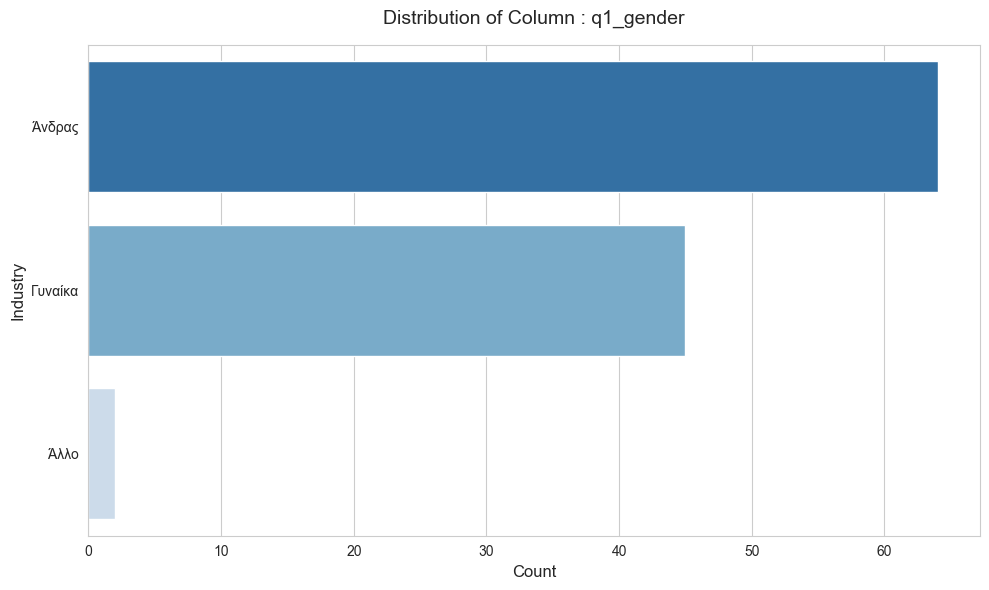

Normalized frequencies of column: q2_age_group
26-41    0.549550
42-57    0.261261
18-25    0.108108
58+      0.081081
Name: proportion, dtype: float64


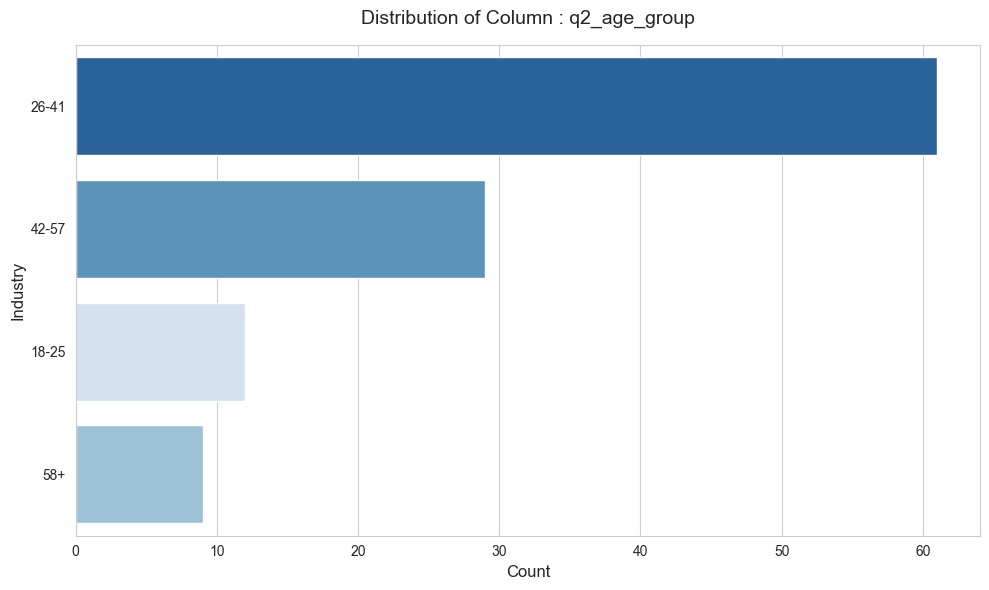

Normalized frequencies of column: q3_education_level
Μεταπτυχιακό Δίπλωμα        0.468468
Πτυχίο ΑΕΙ-ΤΕΙ              0.405405
Δευτεροβάθμια Εκπαίδευση    0.081081
Διδακτορικό Δίπλωμα         0.045045
Name: proportion, dtype: float64


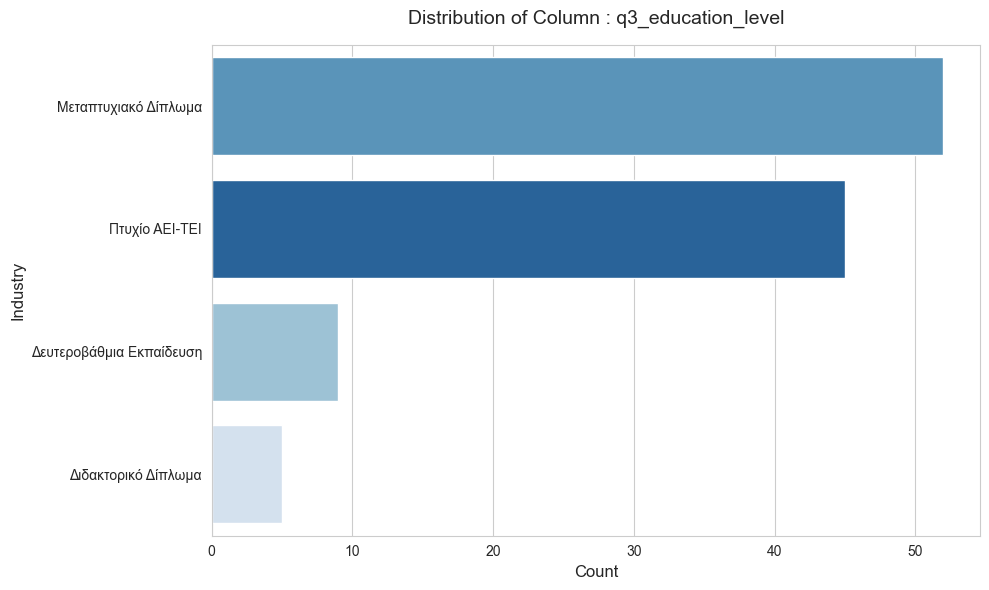

Normalized frequencies of column: q4_white_collar_status
Δουλεύω σε έναν εργοδότη                 0.927928
Δουλεύω σε παραπάνω από έναν εργοδότη    0.072072
Name: proportion, dtype: float64


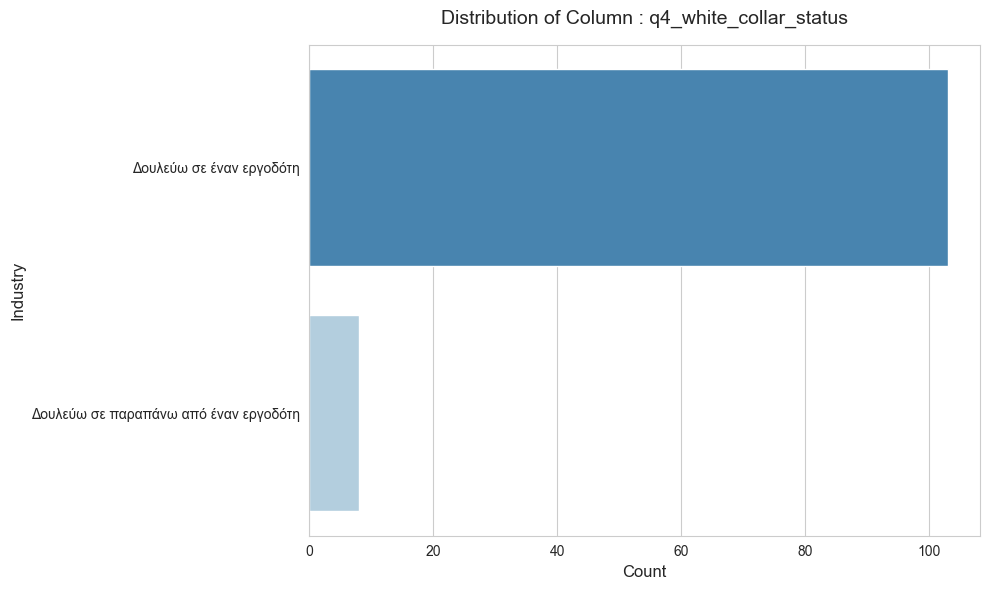

Normalized frequencies of column: q5_industry
Τεχνολογία & Πληροφορική            0.396396
Δημόσιος Τομέας                     0.135135
Άλλο                                0.117117
Διοικητική Υποστήριξη               0.117117
Οικονομικά, Τράπεζες & Ασφάλειες    0.108108
Πωλήσεις & Εξυπηρέτηση Πελατών      0.081081
Μάρκετινγκ & Επικοινωνία            0.027027
Ανθρώπινο Δυναμικό                  0.018018
Name: proportion, dtype: float64


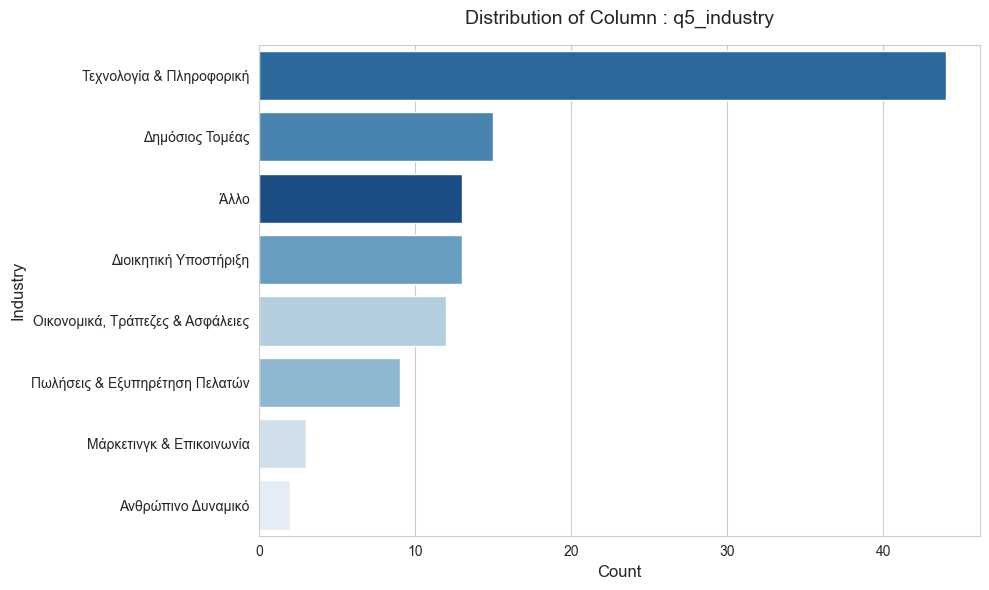

Normalized frequencies of column: q6_job_level
Mid-level      0.450450
Entry Level    0.225225
Senior         0.180180
Management     0.117117
Executive      0.027027
Name: proportion, dtype: float64


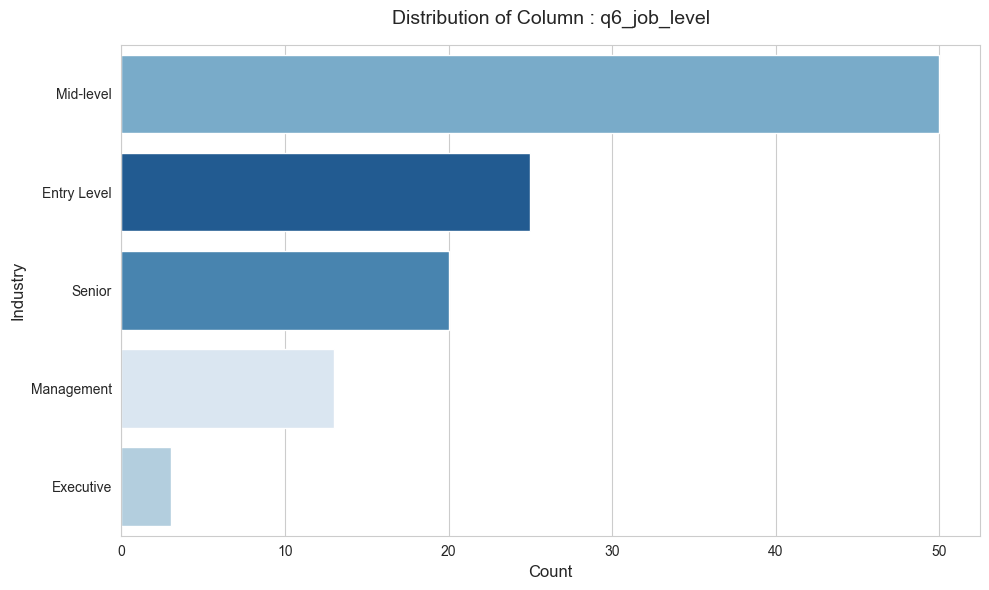

Normalized frequencies of column: q7_company_size
Μικρομεσαία (11-250 άτομα)          0.468468
Μεγάλη - Πολυεθνική (250+ άτομα)    0.441441
Πολύ μικρή (έως 10 άτομα)           0.090090
Name: proportion, dtype: float64


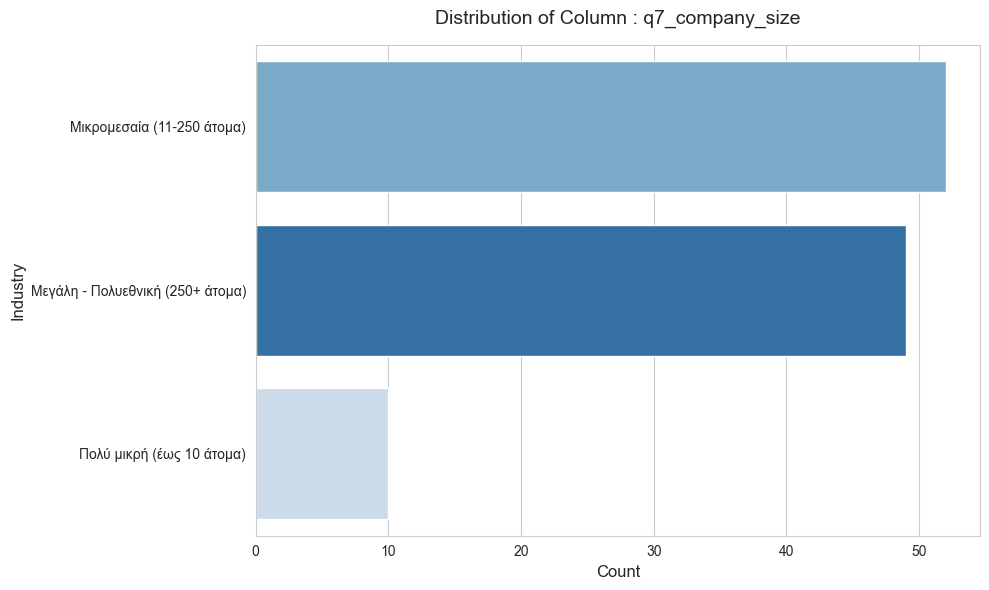

Normalized frequencies of column: q8_total_experience
20+      0.279279
6-10     0.234234
0-2      0.198198
3-5      0.171171
11-20    0.117117
Name: proportion, dtype: float64


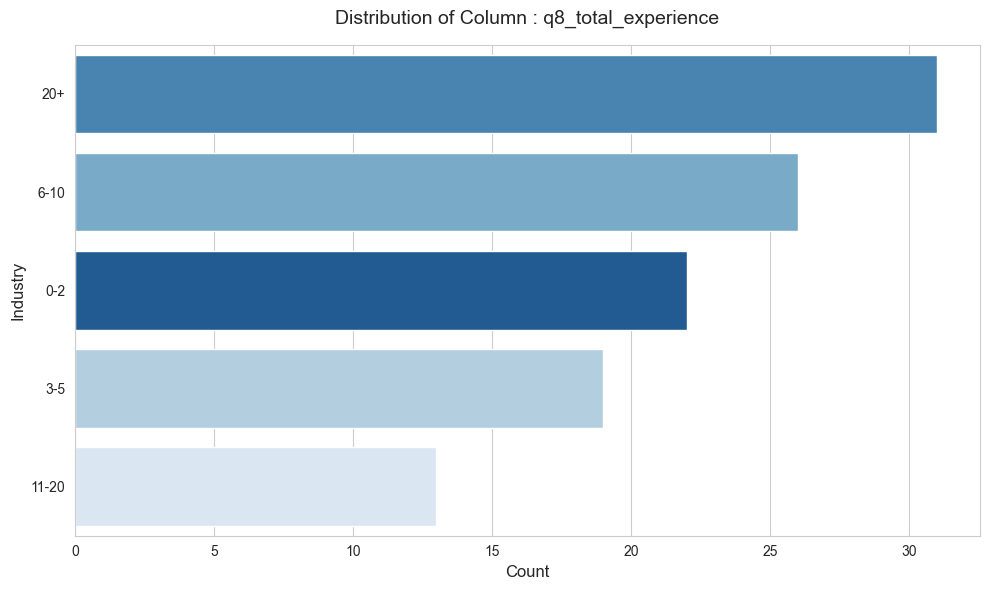

Normalized frequencies of column: q9_tenure_current_employer
Πάνω από 5 έτη         0.324324
3-5 έτη                0.243243
Λιγότερο από 1 έτος    0.243243
1-2 έτη                0.189189
Name: proportion, dtype: float64


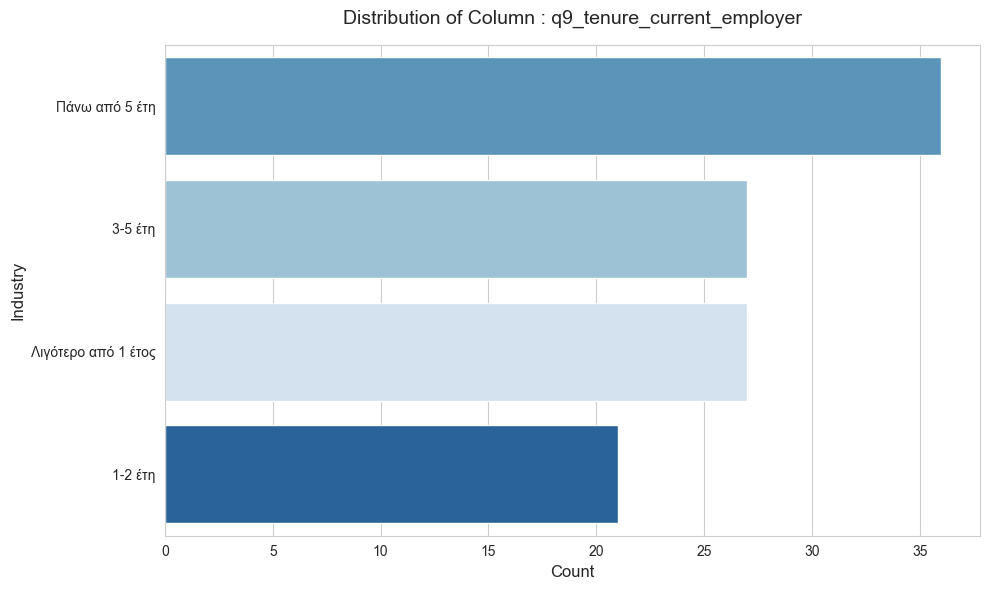

Normalized frequencies of column: q10_job_satisfaction
4.0    0.396396
3.0    0.306306
5.0    0.171171
2.0    0.108108
1.0    0.018018
Name: proportion, dtype: float64


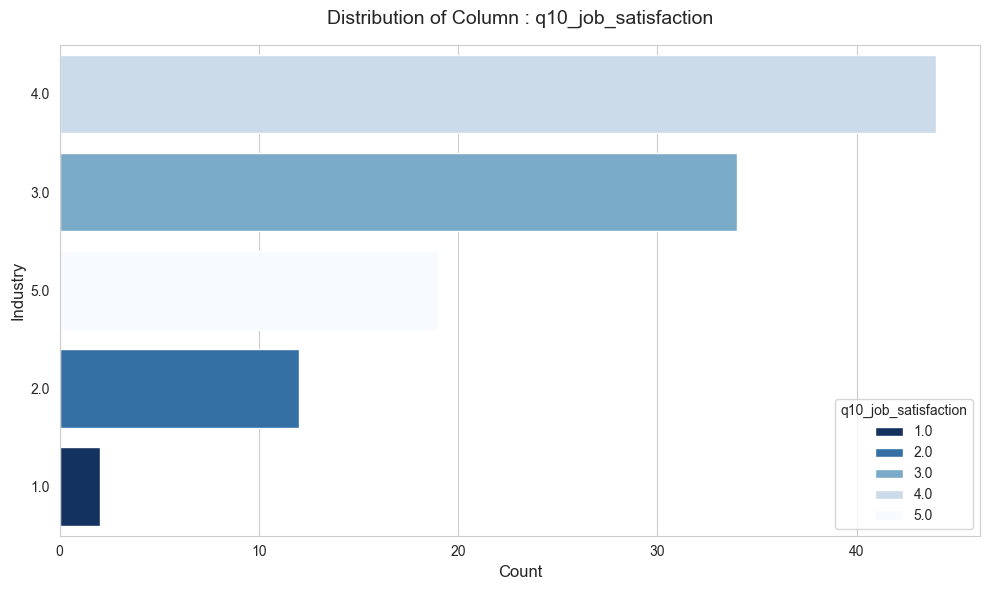

Normalized frequencies of column: q11_financial_satisfaction
4.0    0.351351
3.0    0.234234
2.0    0.162162
5.0    0.153153
1.0    0.099099
Name: proportion, dtype: float64


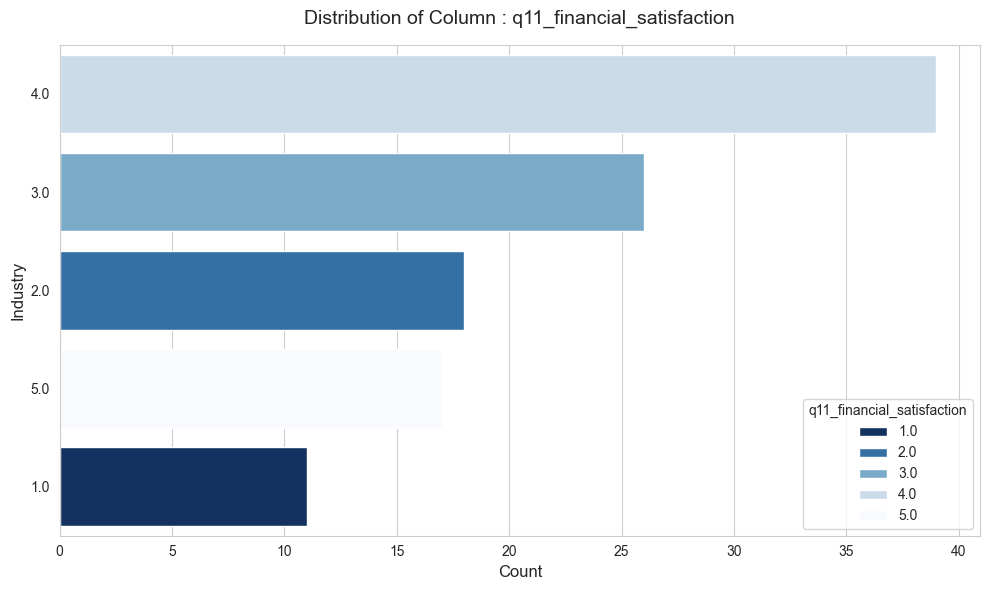

Normalized frequencies of column: q12_ideal_stay_duration
3-5 έτη           0.558559
Πάνω από 5 έτη    0.288288
1-2 έτη           0.153153
Name: proportion, dtype: float64


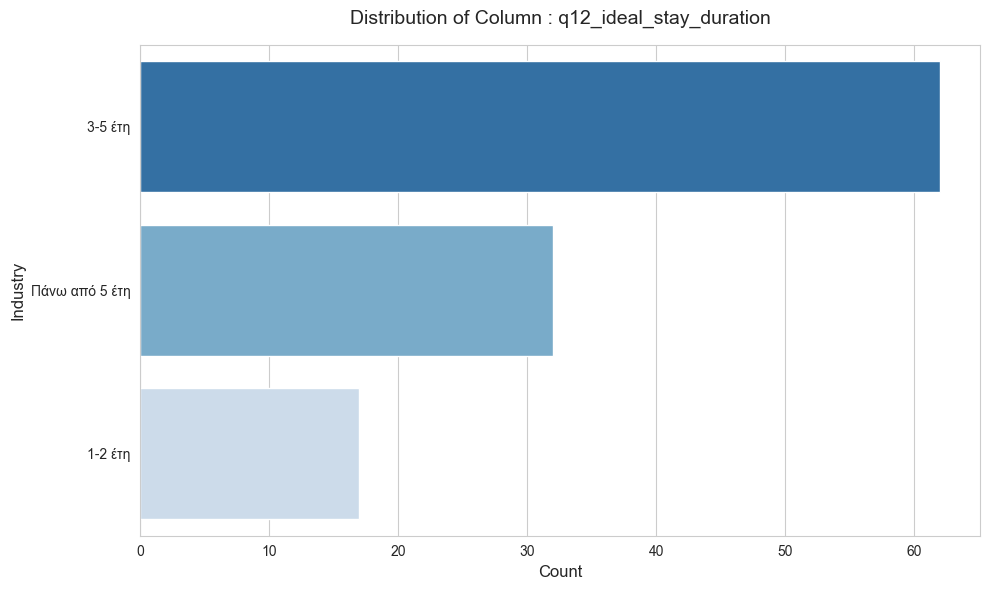

Normalized frequencies of column: q13_profile_update_frequency
Πολύ σπάνια                  0.432432
Κάθε χρόνο                   0.162162
Κάθε 6 μήνες                 0.162162
Κάθε 3 μήνες                 0.108108
Κάθε μήνα                    0.090090
Κάθε εβδομάδα ή πιο συχνά    0.045045
Name: proportion, dtype: float64


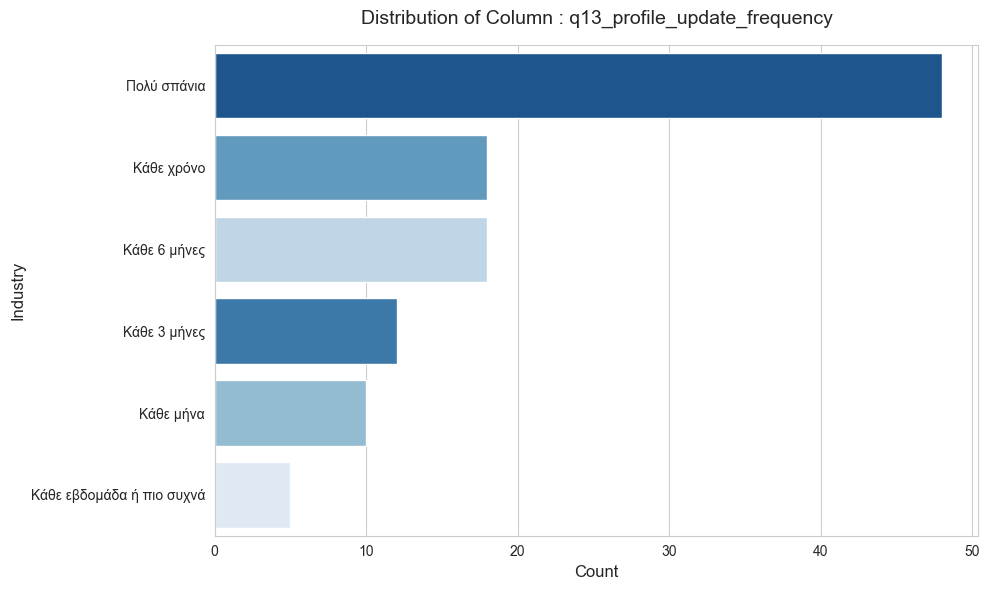

Normalized frequencies of column: q14_thought_change_frequency
Δεν το σκέφτομαι    0.387387
Κάθε χρόνο          0.207207
Κάθε μήνα           0.108108
Κάθε 3 μήνες        0.108108
Κάθε εβδομάδα       0.099099
Κάθε 6 μήνες        0.090090
Name: proportion, dtype: float64


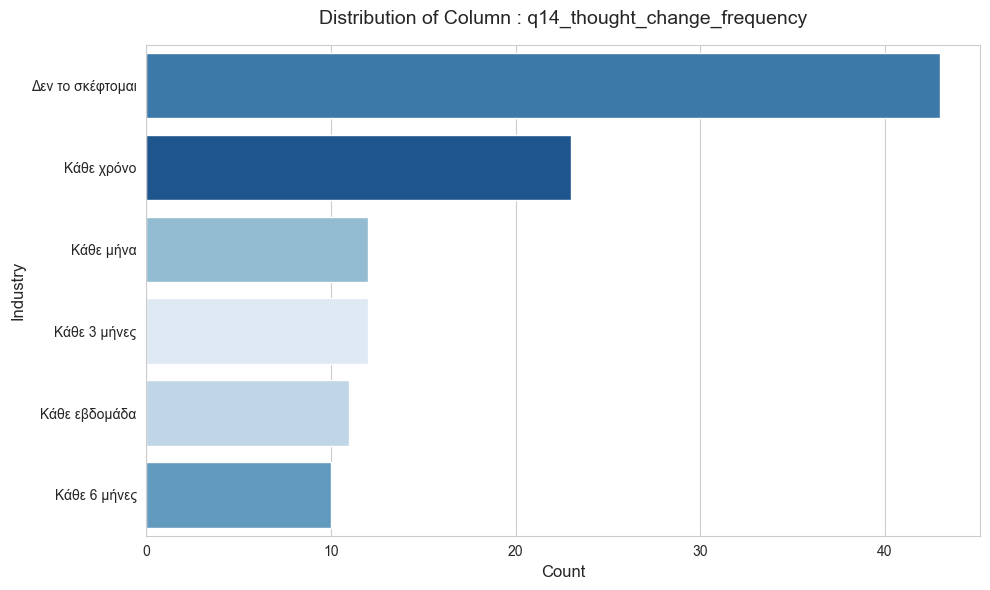

Normalized frequencies of column: q15_job_hopping_awareness
Ναι    0.738739
Όχι    0.261261
Name: proportion, dtype: float64


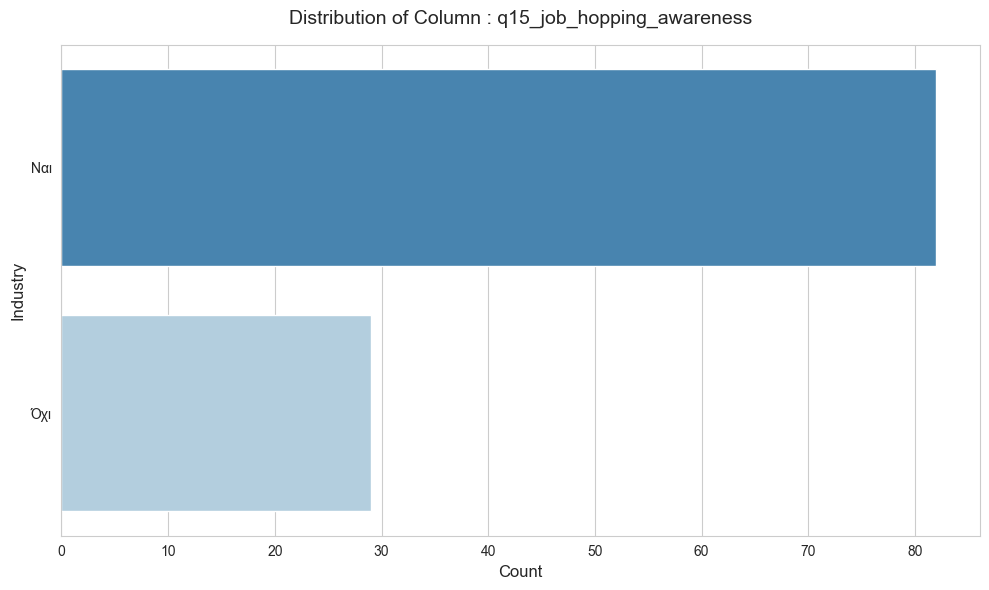

Normalized frequencies of column: q16_job_hopping_benefit
4.0    0.360360
3.0    0.351351
2.0    0.144144
5.0    0.126126
1.0    0.018018
Name: proportion, dtype: float64


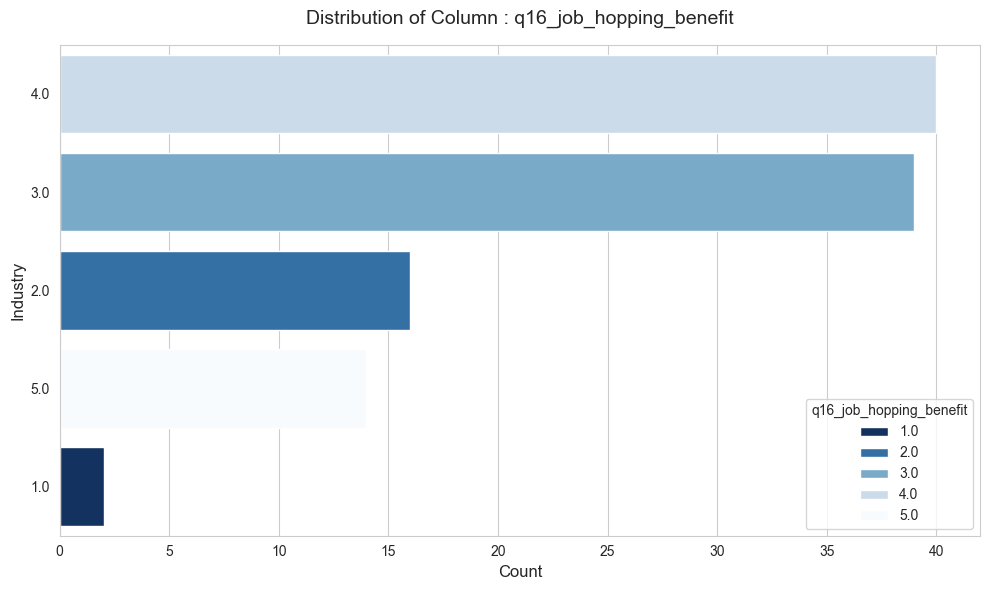

Normalized frequencies of column: q17_job_hopping_history
Όχι    0.738739
Ναι    0.261261
Name: proportion, dtype: float64


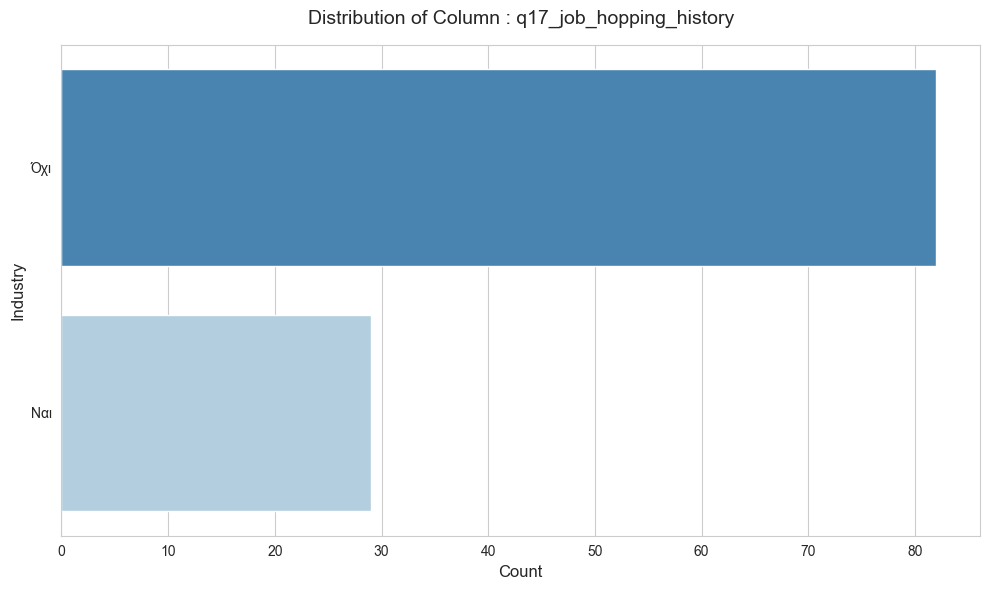

Normalized frequencies of column: q18_attrition_intent
Όχι    0.585586
Ναι    0.414414
Name: proportion, dtype: float64


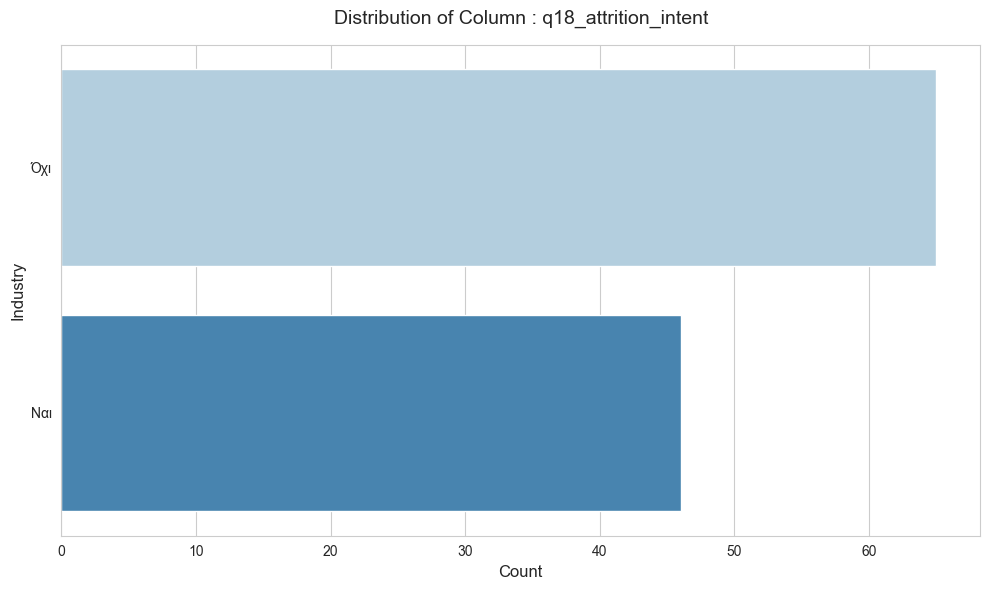

Normalized frequencies of column: q19_employers_changed_5years
0     0.450450
1     0.198198
2     0.189189
3+    0.162162
Name: proportion, dtype: float64


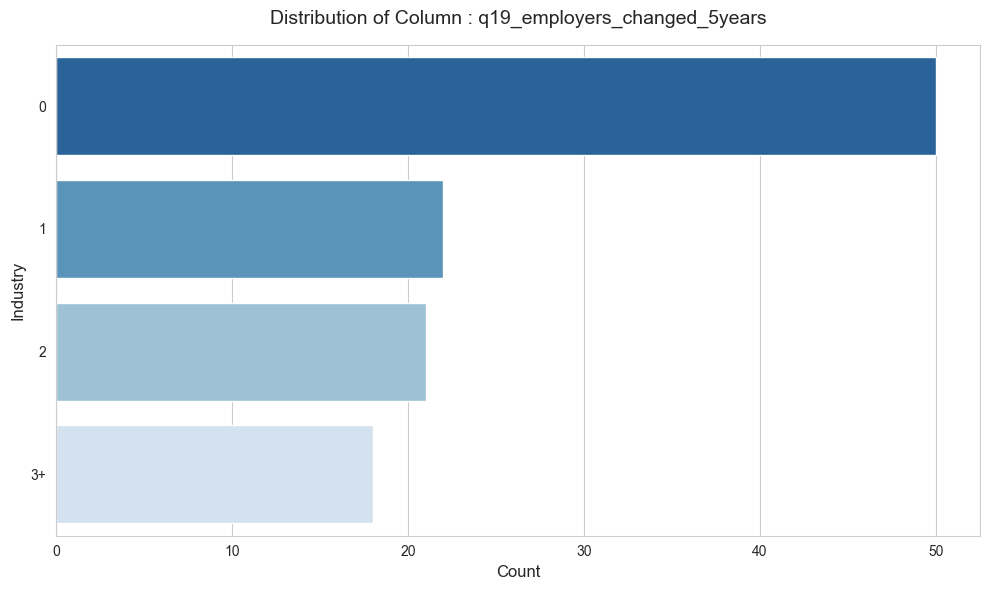

Normalized frequencies of column: q20_fair_reward_perception
Μέτρια       0.459459
Πολύ         0.252252
Λίγο         0.153153
Πάρα πολύ    0.072072
Καθόλου      0.063063
Name: proportion, dtype: float64


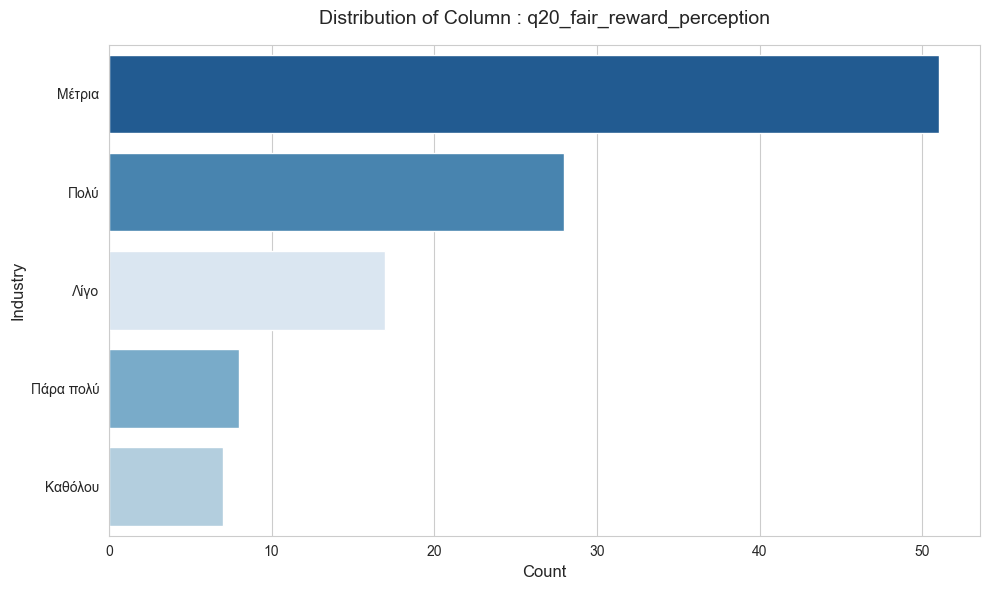

Normalized frequencies of column: q21_minimum_effort_frequency
Δεν το κάνω    0.279279
Μέτρια         0.189189
Συχνά          0.180180
Σπάνια         0.162162
Πολύ σπάνια    0.153153
Πολύ συχνά     0.036036
Name: proportion, dtype: float64


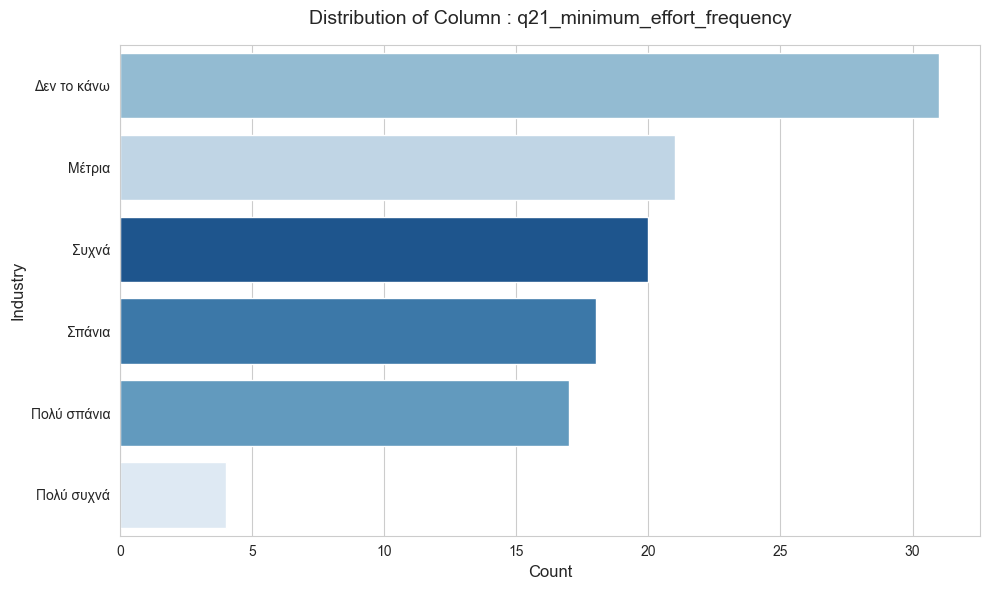

Normalized frequencies of column: q22_retention_due_to_costs
Ναι    0.540541
Όχι    0.459459
Name: proportion, dtype: float64


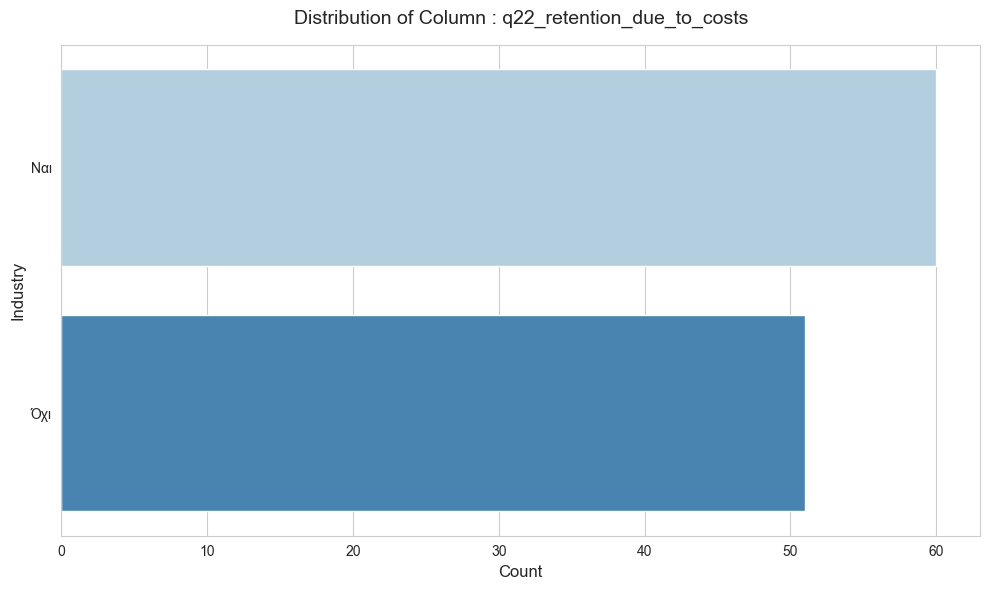

Normalized frequencies of column: q23_quiet_quitting_history
Όχι                      0.630631
Ναι                      0.297297
Δεν ξέρω - Δεν απαντώ    0.072072
Name: proportion, dtype: float64


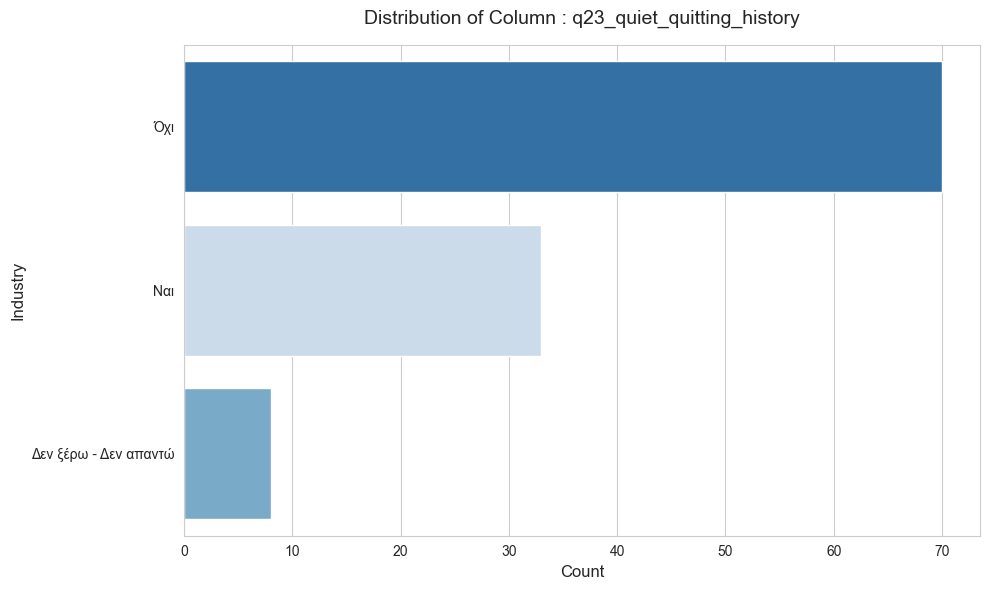

Normalized frequencies of column: q24_quiet_quitting_benefit
3.0    0.288288
4.0    0.252252
2.0    0.153153
5.0    0.153153
1.0    0.153153
Name: proportion, dtype: float64


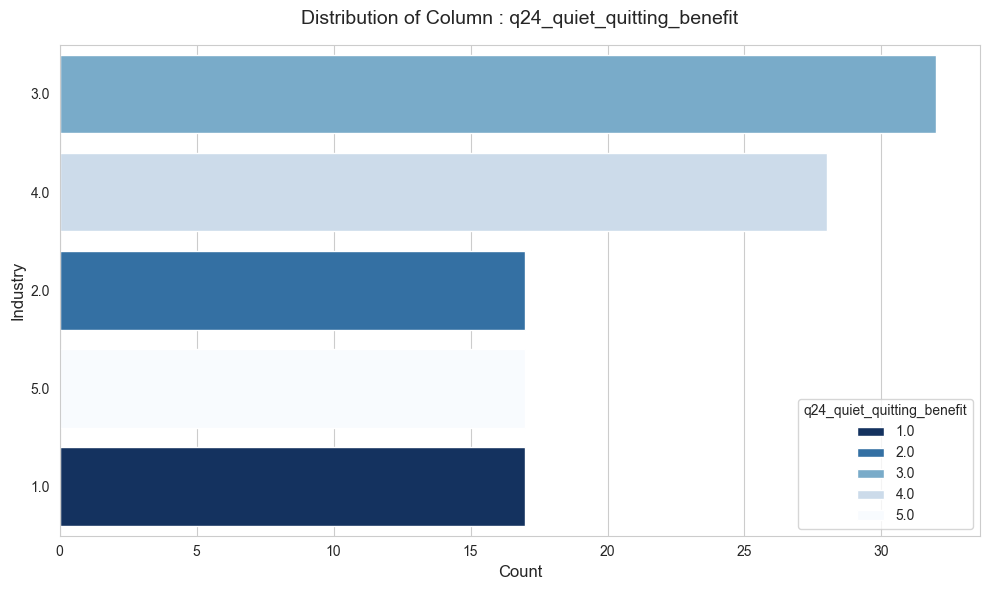

Normalized frequencies of column: q25_current_work_model
Δια ζώσης (On-Site)    0.585586
Υβριδικό (Hybrid)      0.279279
Τηλεργασία (Remote)    0.135135
Name: proportion, dtype: float64


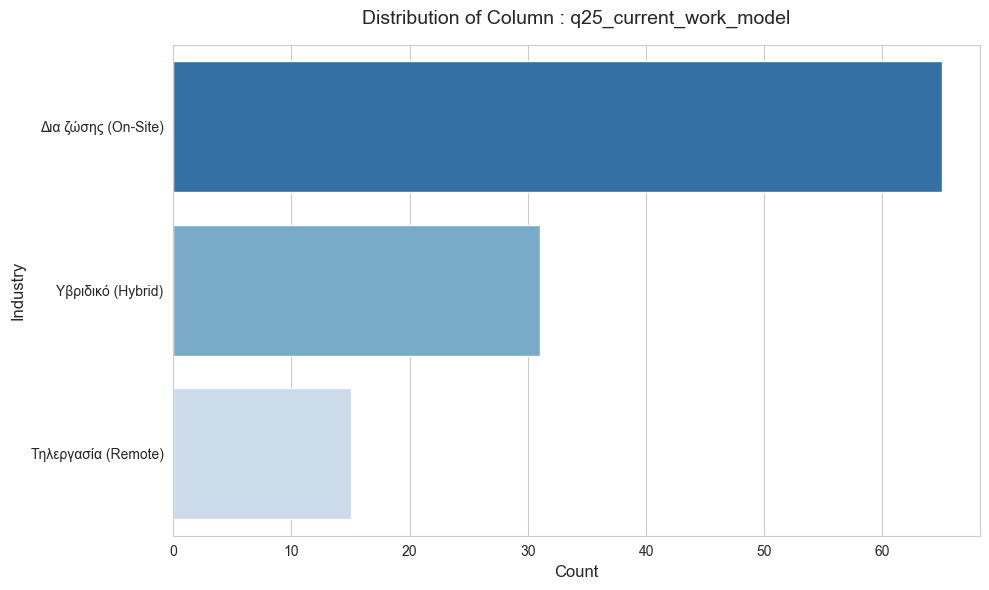

Normalized frequencies of column: q26_preferred_work_model
Υβριδικό (Hybrid)      0.594595
Τηλεργασία (Remote)    0.288288
Δια ζώσης (On-site)    0.117117
Name: proportion, dtype: float64


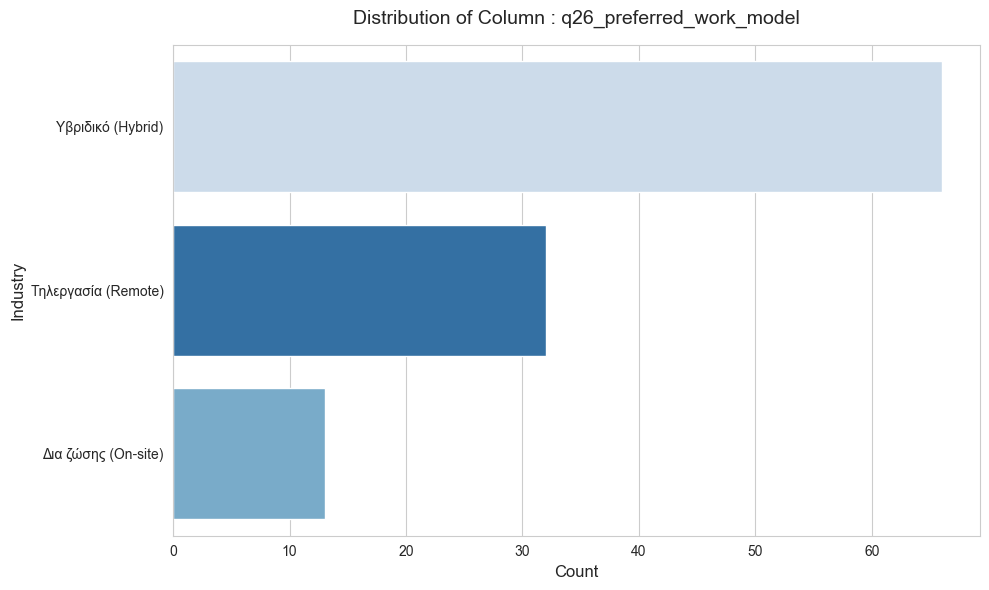

Normalized frequencies of column: q27_overtime_frequency
Πολύ λίγο (1-15 μέρες)    0.468468
Λίγο (16 - 30 μέρες)      0.216216
Μέτρια (31 - 60 μέρες)    0.144144
Πάρα πολύ (91+ μέρες)     0.108108
Πολύ (61 - 90 μέρες)      0.063063
Name: proportion, dtype: float64


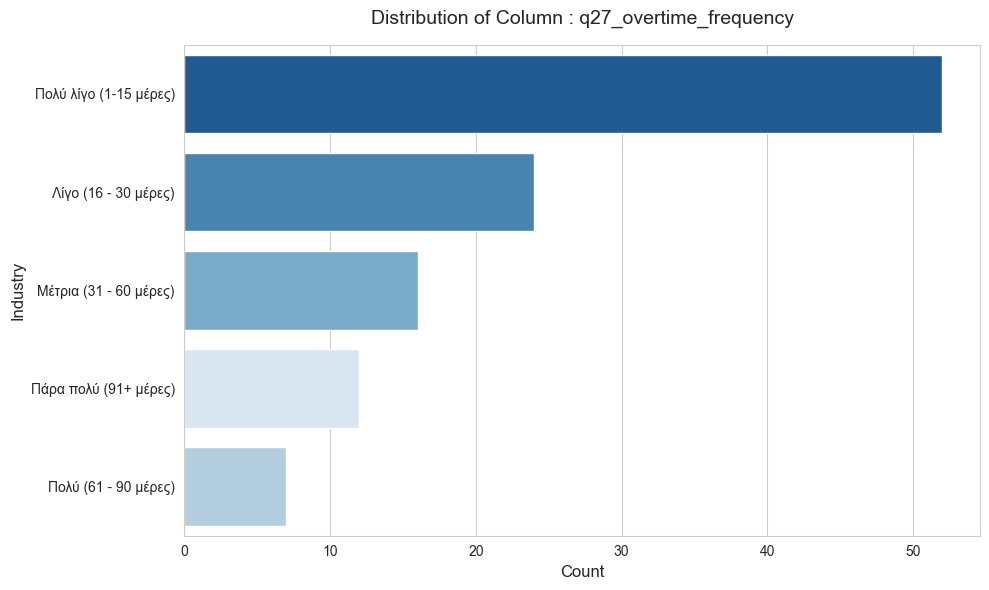

Normalized frequencies of column: q28_emotional_exhaustion_frequency
Μέτρια συχνότητα               0.351351
Πολλές φορές τον χρόνο         0.252252
Πάρα πολλές φορες τον χρόνο    0.180180
Λίγες φορές τον χρόνο          0.171171
Πολύ λίγες φορές τον χρόνο     0.045045
Name: proportion, dtype: float64


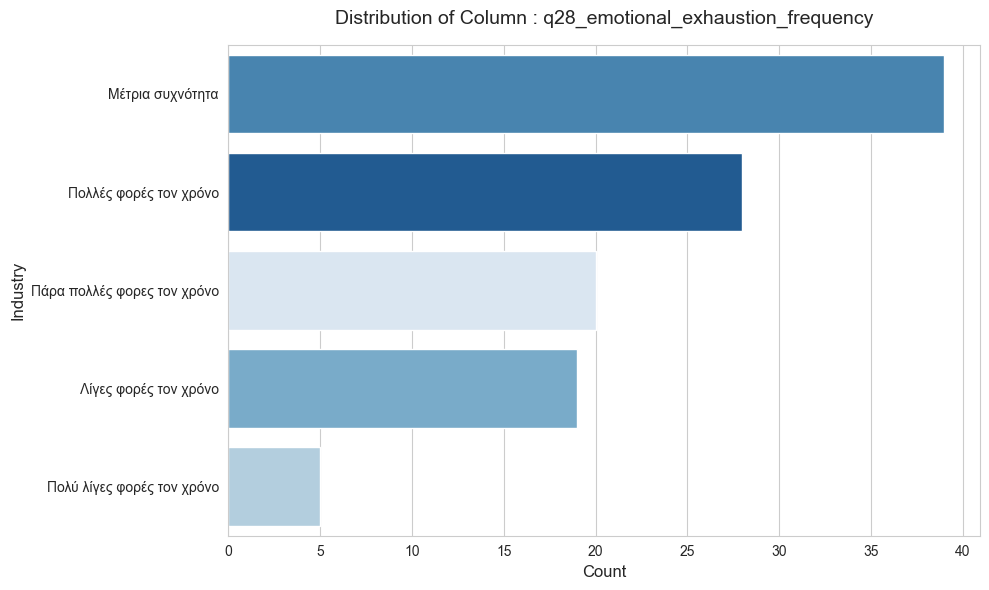

Normalized frequencies of column: q29_stress_level
Μέτρια έντονο       0.441441
Λίγο έντονο         0.216216
Πολύ έντονο         0.207207
Καθόλου έντονο      0.090090
Πάρα πολύ έντονο    0.045045
Name: proportion, dtype: float64


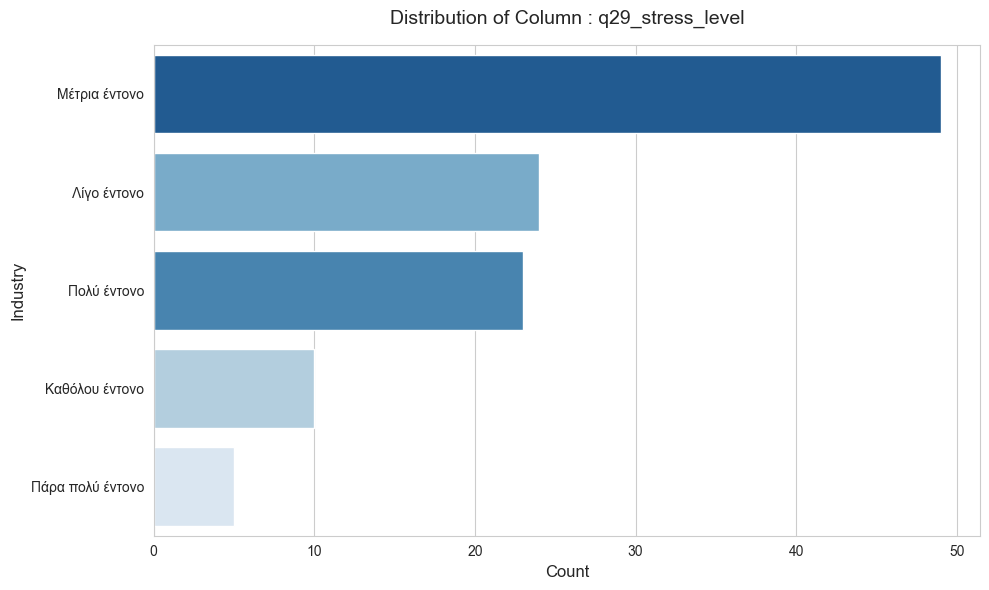

Normalized frequencies of column: q30_stress_work_model_connection
Μέτρια σύνδεση               0.324324
Άμεση σύνδεση                0.252252
Ελάχιστη σύνδεση             0.207207
Καμία σύνδεση μεταξύ τους    0.144144
Δέν ξέρω - Δεν απαντώ        0.072072
Name: proportion, dtype: float64


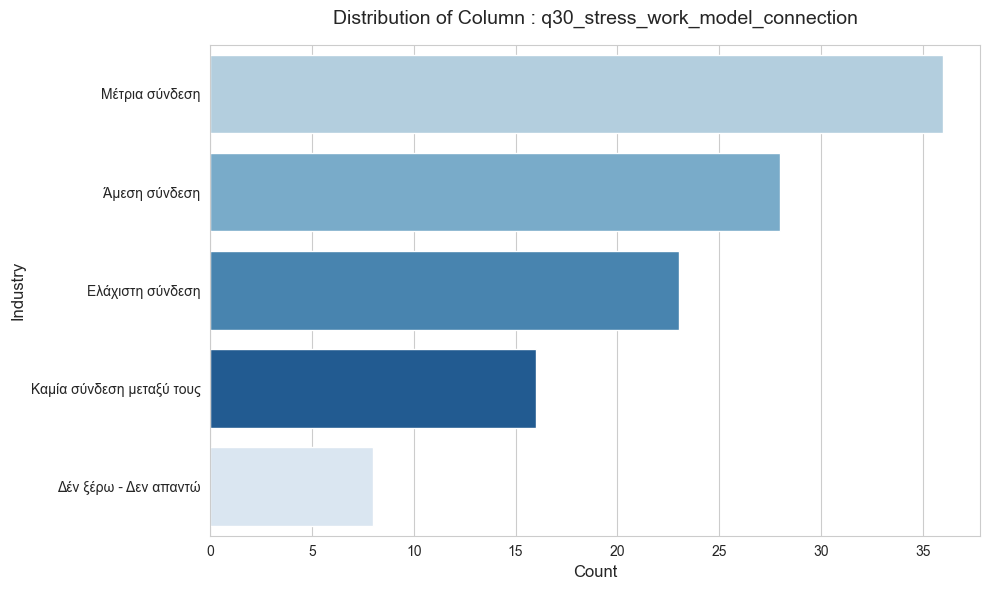

Normalized frequencies of column: q31_employer_wellbeing_interest
Λίγο ενδιαφέρον      0.297297
Μέτριο ενδιαφέρον    0.252252
Δεν ενδιαφέρεται     0.216216
Ενδιαφέρεται         0.135135
Δεν ξέρω             0.054054
Πολύ ενδιαφέρον      0.045045
Name: proportion, dtype: float64


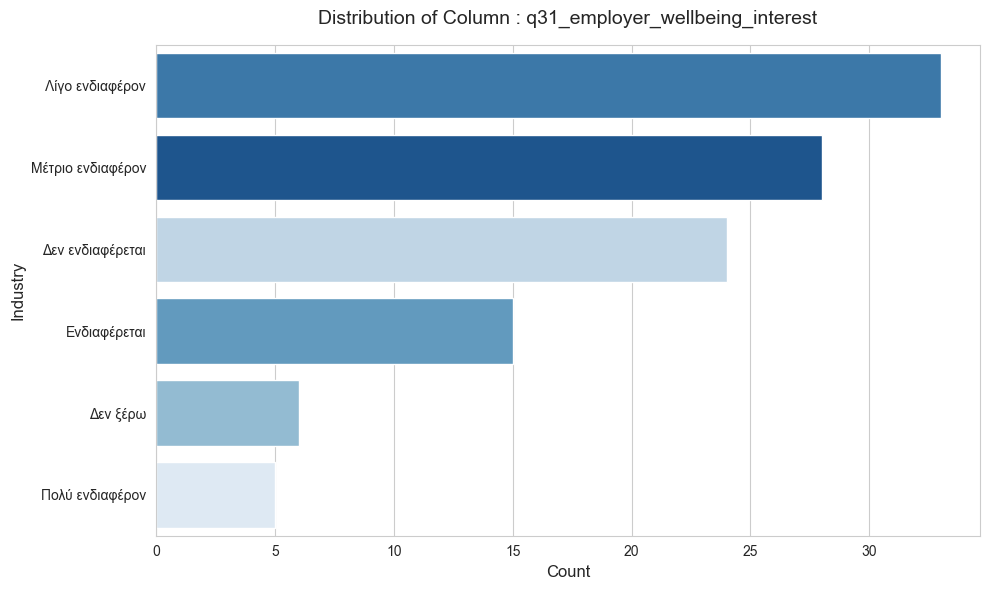

Normalized frequencies of column: q32_work_life_priority
3.0    0.378378
4.0    0.306306
2.0    0.180180
1.0    0.072072
5.0    0.063063
Name: proportion, dtype: float64


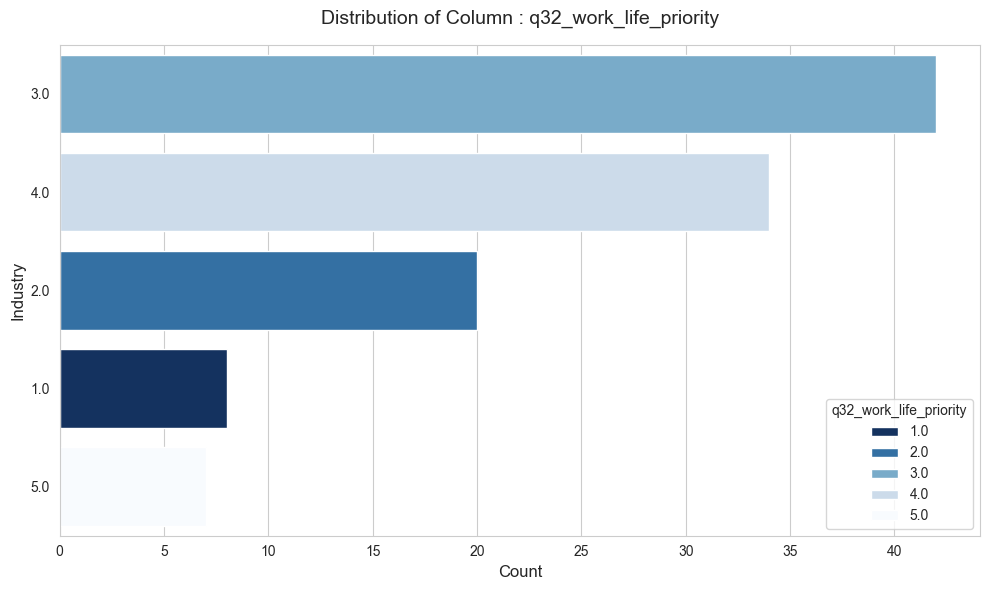

Normalized frequencies of column: q33_change_probability_12months
5.0    0.243243
1.0    0.234234
3.0    0.189189
4.0    0.171171
2.0    0.162162
Name: proportion, dtype: float64


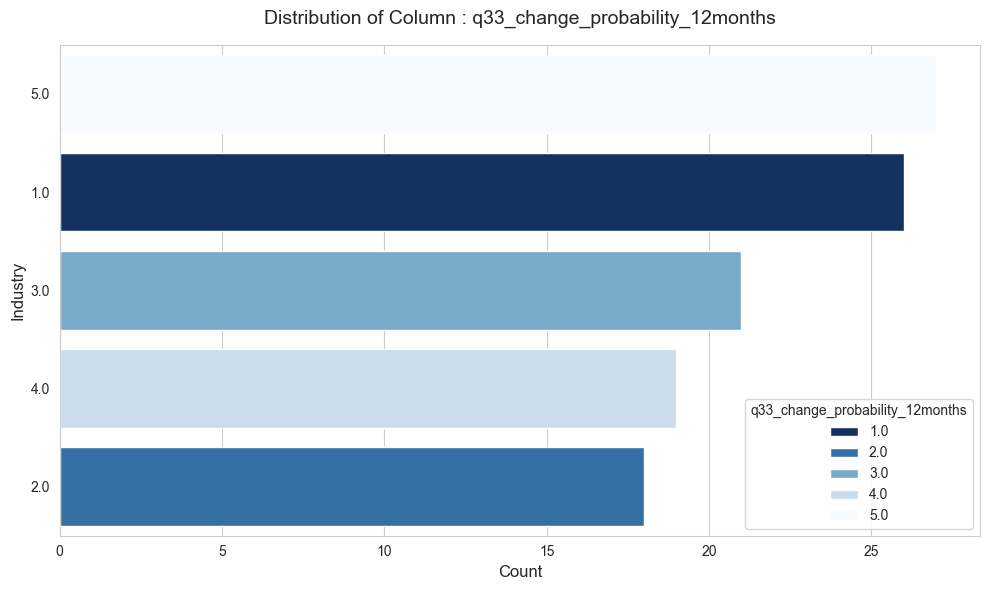

Normalized frequencies of column: enc_q28_emotional_exhaustion_frequency
3.0    0.351351
4.0    0.252252
5.0    0.180180
2.0    0.171171
1.0    0.045045
Name: proportion, dtype: float64


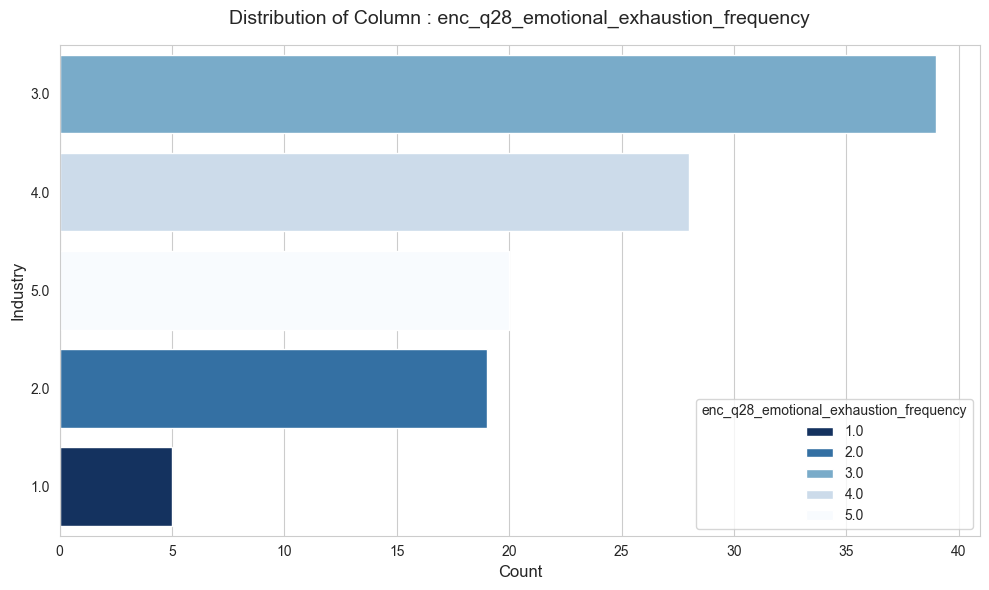

Normalized frequencies of column: enc_q29_stress_level
3.0    0.441441
2.0    0.216216
4.0    0.207207
1.0    0.090090
5.0    0.045045
Name: proportion, dtype: float64


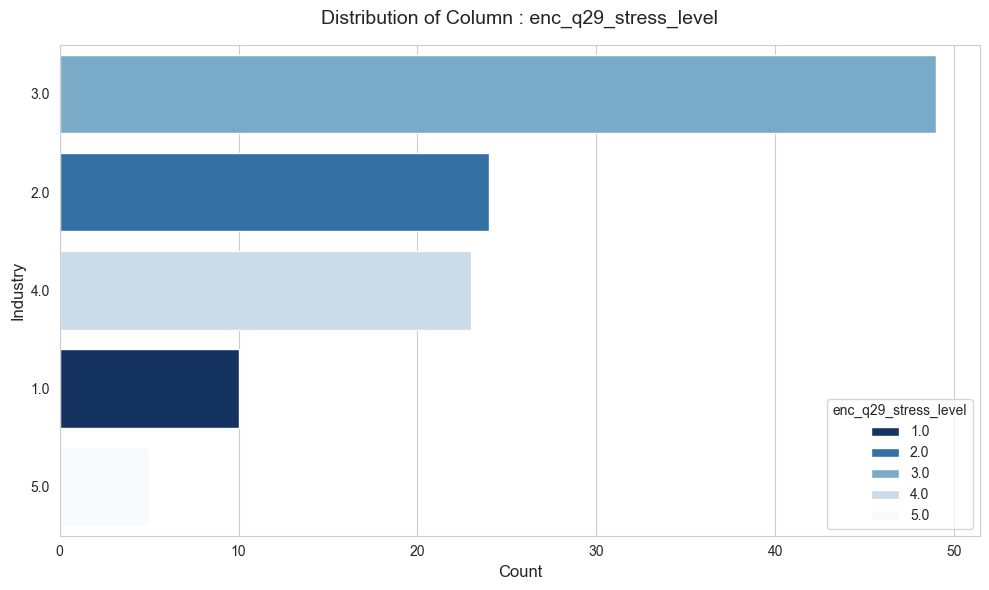

Normalized frequencies of column: q10_job_satisfaction_scaled
 0.425514    0.396396
-0.624087    0.306306
 1.475115    0.171171
-1.673689    0.108108
-2.723290    0.018018
Name: proportion, dtype: float64


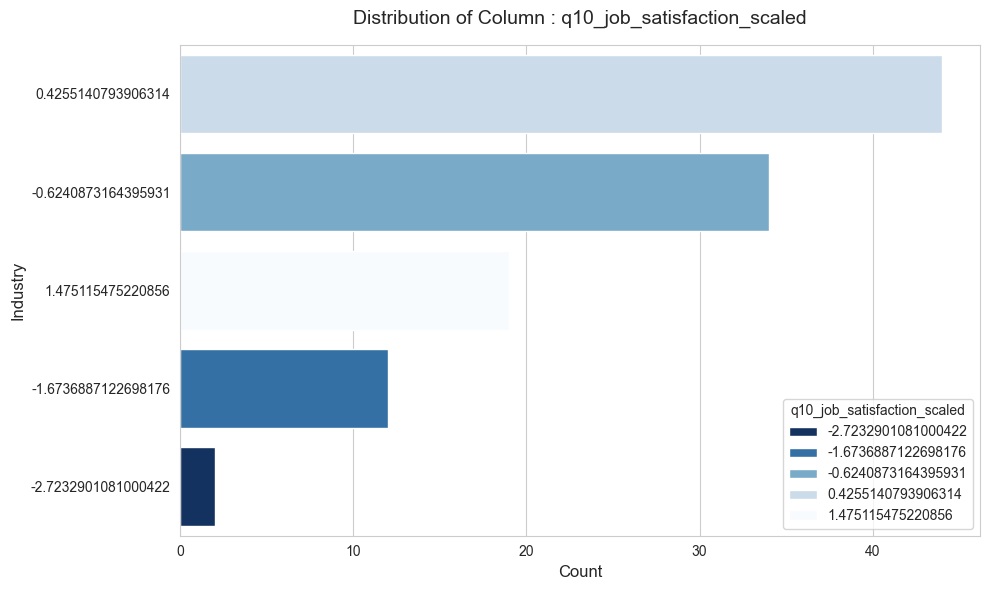

Normalized frequencies of column: q11_financial_satisfaction_scaled
 0.586781    0.351351
-0.248254    0.234234
-1.083289    0.162162
 1.421816    0.153153
-1.918324    0.099099
Name: proportion, dtype: float64


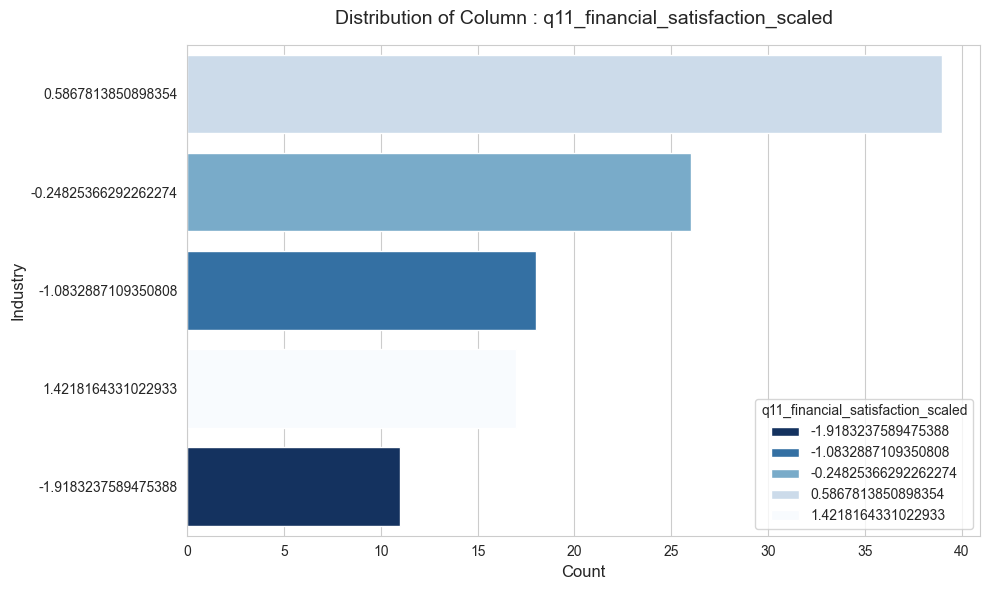

Normalized frequencies of column: q16_job_hopping_benefit_scaled
 0.600245    0.360360
-0.457330    0.351351
-1.514904    0.144144
 1.657820    0.126126
-2.572479    0.018018
Name: proportion, dtype: float64


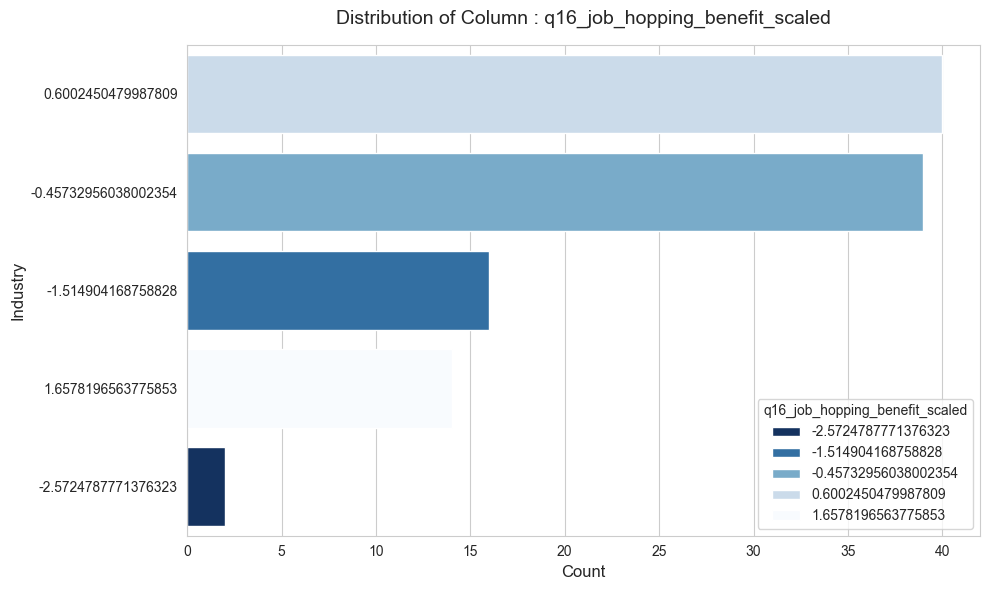

Normalized frequencies of column: q24_quiet_quitting_benefit_scaled
-0.077840    0.288288
 0.707638    0.252252
-0.863318    0.153153
 1.493116    0.153153
-1.648796    0.153153
Name: proportion, dtype: float64


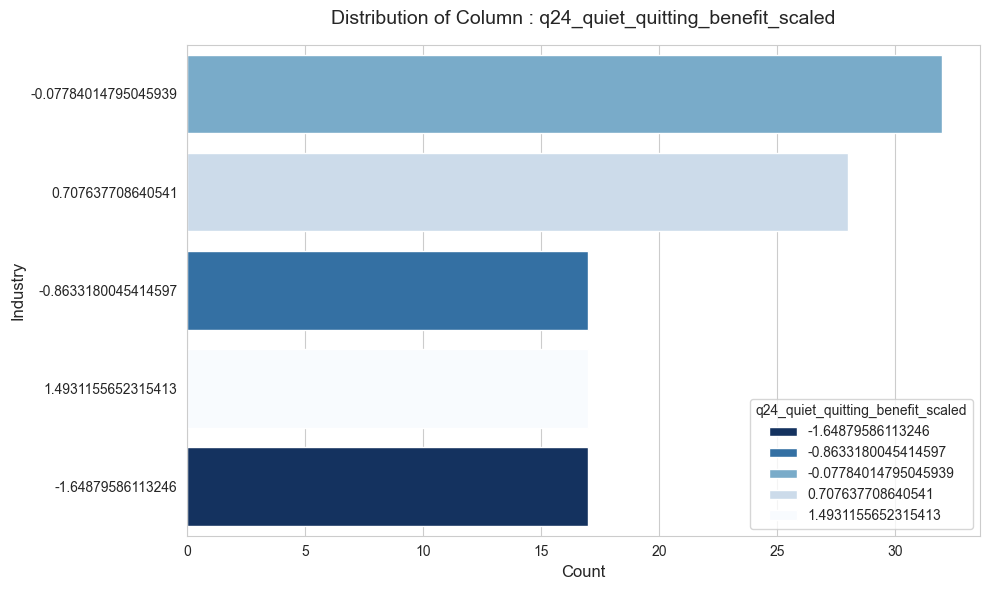

Normalized frequencies of column: enc_q28_emotional_exhaustion_frequency_scaled
-0.320621    0.351351
 0.591916    0.252252
 1.504454    0.180180
-1.233159    0.171171
-2.145697    0.045045
Name: proportion, dtype: float64


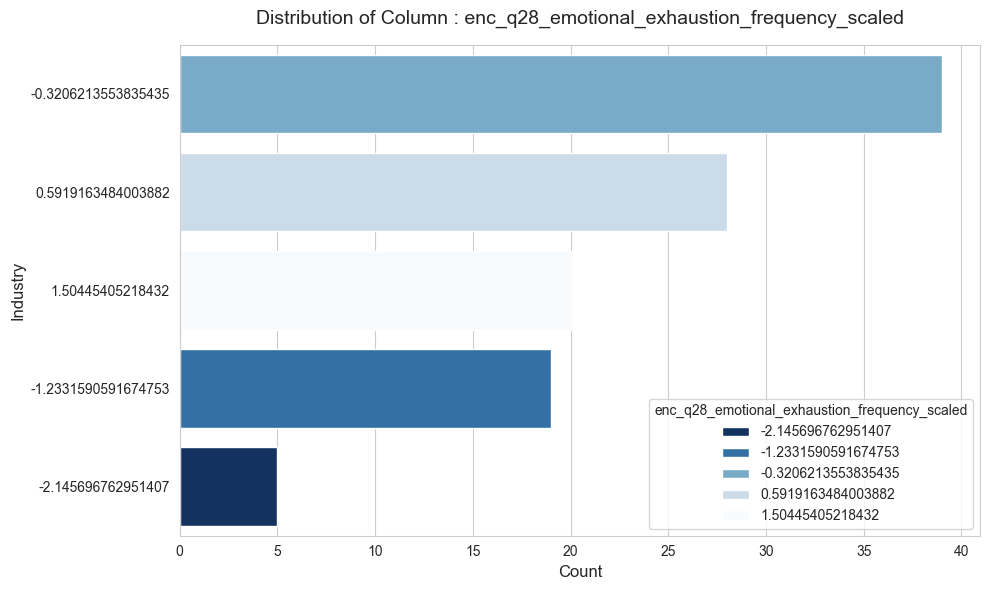

Normalized frequencies of column: enc_q29_stress_level_scaled
 0.101453    0.441441
-0.922296    0.216216
 1.125201    0.207207
-1.946044    0.090090
 2.148949    0.045045
Name: proportion, dtype: float64


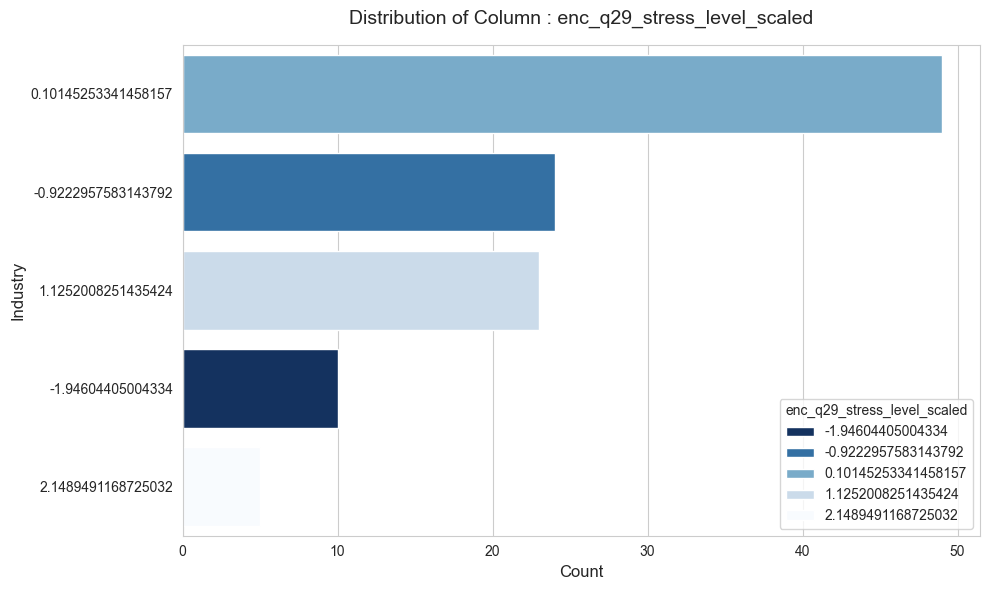

Normalized frequencies of column: q32_work_life_priority_scaled
-0.107288    0.378378
 0.885129    0.306306
-1.099706    0.180180
-2.092123    0.072072
 1.877546    0.063063
Name: proportion, dtype: float64


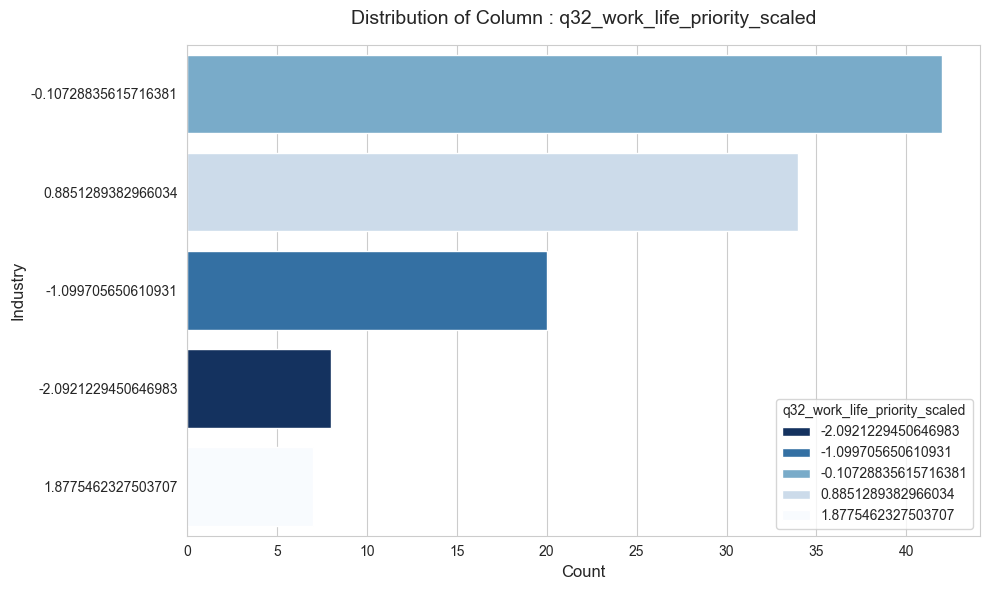

Normalized frequencies of column: q33_change_probability_12months_scaled
 1.317509    0.243243
-1.353605    0.234234
-0.018048    0.189189
 0.649731    0.171171
-0.685827    0.162162
Name: proportion, dtype: float64


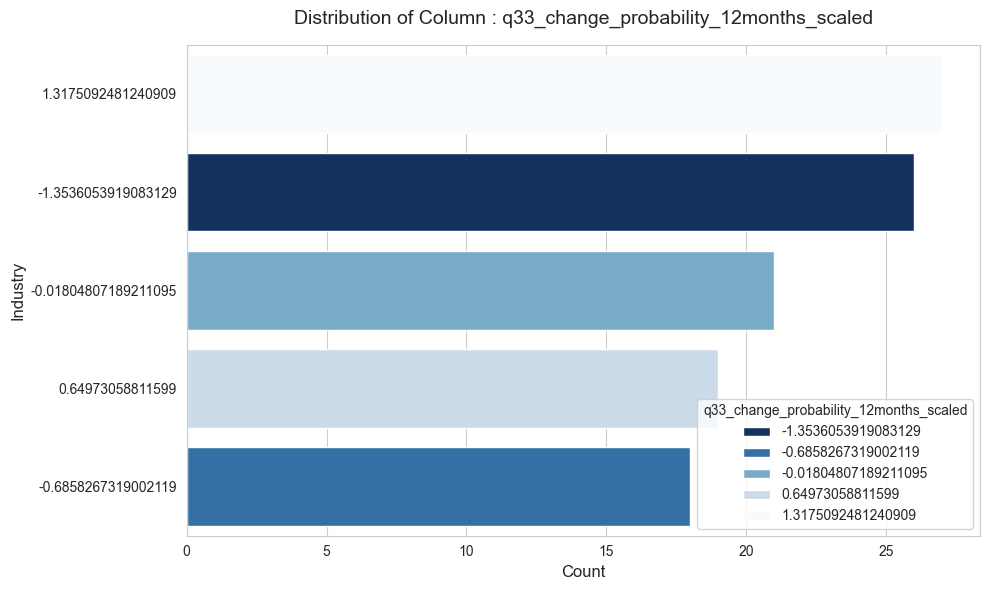

In [52]:
import matplotlib.pyplot as plt
import seaborn as sb

def column_distributions(dataset):
    ds_cols = dataset.columns
    for col in ds_cols:
        if col != 'Timestamp':
            plt.figure(figsize=(10, 6))

            # the below code will help ordering the plots
            row_order = dataset[col].value_counts().index
            #normalizing the data too to know the percentages each category occupies
            normalized_data = dataset[col].value_counts(normalize=True)
            print(f'Normalized frequencies of column:', normalized_data)
            # creating the plots horizontally
            sb.countplot(
                y=col,
                hue=dataset[col],
                data=dataset,
                order=row_order,
                palette='Blues_r'  # using Blues_r to have the most frequent categories with the deeper hue of blue
            )
            plt.title(f'Distribution of Column : {col}', fontsize=14, pad=15)
            plt.xlabel('Count', fontsize=12)
            plt.ylabel('Industry', fontsize=12)
            plt.tight_layout()
            plt.show()

column_distributions(dataset)

In [7]:
#lot's of industries were given since there was an option to include additional sectors
print(dataset['q5_industry'].unique())

#lot's of people from the public sector filled the questionnaire, so all these cases will be formed in one category using the below regular expression
public_sector_pattern = r'δημόσι|ΔΗΜΟΣΙ|ΕΣΠΑ|προγραμμάτων|ΠΡΟΓΡΑΜΜΑΤΩΝ|έργων|ΕΡΓΩΝ|δημοσι|υπουργ|E.E.|εκπαιδευτικός.*δημόσιο'

#healthcare and pharmaceuticals patterns
med_pattern = r'ΦΑΡΜΑΚΕΥΤΙΚΗ|Φαρμακευτικά'

#law patterns
lawyer_pattern = r'Δικηγόρος|Δικηγορικό'

#applying the above patterns
dataset.loc[dataset['q5_industry'].str.contains(public_sector_pattern, case = False, na=False), 'q5_industry'] = 'Δημόσιος Τομέας'

dataset.loc[dataset['q5_industry'].str.contains(lawyer_pattern, case=False, na=False), 'q5_industry'] = 'Δικηγορικές Υπηρεσίες'

dataset.loc[dataset['q5_industry'].str.contains(med_pattern, case=False, na=False), 'q5_industry'] = 'Υγεια/Φαρμακευτικά'

#cleaning some additional fields because of multiple choices on several cases, starting with management and going down from there
dataset.loc[dataset['q5_industry'].str.contains('Διοικητική Υποστήριξη', case=False, na=False), 'q5_industry'] = 'Διοικητική Υποστήριξη'

dataset.loc[dataset['q5_industry'].str.contains('Πωλήσεις & Εξυπηρέτηση Πελατών', case=False, na=False), 'q5_industry'] = 'Πωλήσεις & Εξυπηρέτηση Πελατών'

dataset.loc[dataset['q5_industry'].str.contains('Ανθρώπινο Δυναμικό', case=False, na=False), 'q5_industry'] = 'Ανθρώπινο Δυναμικό'

dataset.loc[dataset['q5_industry'].str.contains('Οικονομικά, Τράπεζες & Ασφάλειες', case=False, na=False), 'q5_industry'] = 'Οικονομικά, Τράπεζες & Ασφάλειες'

dataset.loc[dataset['q5_industry'].str.contains('Τεχνολογία & Πληροφορική', case=False, na=False), 'q5_industry'] = 'Τεχνολογία & Πληροφορική'


#viewing how many categories were left after merging
print('='*50)
print('Industry categories after collapsing')
print(dataset['q5_industry'].unique())

<StringArray>
[                                                                            'Άλλο',
                                                         'Τεχνολογία & Πληροφορική',
                             'ΕΙΔΙΚΗ ΥΠΗΡΕΣΙΑ ΔΙΑΧΕΙΡΙΣΗΣ ΜΕΤΑΦΟΡΕΣ ΕΣΠΑ 2021-2027',
                                                 'Οικονομικά, Τράπεζες & Ασφάλειες',
                                                            'Διοικητική Υποστήριξη',
                                                           'Οικονομικά, Περιβάλλον',
                          'Ανθρώπινο Δυναμικό (HR), Πωλήσεις & Εξυπηρέτηση Πελατών',
                                       'ΔΙΑΧΕΙΡΙΣΗ ΣΥΓΧΡΗΜΑΤΟΔΟΤΟΥΜΕΝΩΝ ΕΡΓΩΝ ΕΣΠΑ',
                                                              'Τεχνικός συντήρησης',
                                                   'Πωλήσεις & Εξυπηρέτηση Πελατών',
                                                    'Δημοσιογραφία / Ειδησεογραφία',
                'Ευρύτερος Δημόσιος Τομέας - Διαχεί

In [8]:
#checking frequency in order to collapse categories that appear in less than 2% of the dataset
frequency_per_industry = dataset['q5_industry'].value_counts(normalize=True)
print('Industries with frequency less than 2%.')

#these industries will be collapsed as suggested by Kuhn (2013)
for industry in frequency_per_industry.index:
    if frequency_per_industry[industry] < 0.02:
        print(f'Industry: {industry} with frequency: {frequency_per_industry[industry]}')
        dataset.loc[dataset['q5_industry'].str.contains(industry, case=False, na=False), 'q5_industry'] = 'Άλλο'

print('='*50)
print('Industry categories after collapsing:')
updated_frequency_per_industry = dataset['q5_industry'].value_counts(normalize=True)

print(updated_frequency_per_industry)

Industries with frequency less than 2%.
Industry: Δικηγορικές Υπηρεσίες with frequency: 0.016666666666666666
Industry: Υγεια/Φαρμακευτικά with frequency: 0.016666666666666666
Industry: Οικονομικά, Περιβάλλον with frequency: 0.008333333333333333
Industry: Τεχνικός συντήρησης with frequency: 0.008333333333333333
Industry: Κατασκευαστική Εταιρια with frequency: 0.008333333333333333
Industry: Βιομηχανική παραγωγή with frequency: 0.008333333333333333
Industry: Συμβουλευτική with frequency: 0.008333333333333333
Industry categories after collapsing:
q5_industry
Τεχνολογία & Πληροφορική            0.383333
Άλλο                                0.133333
Δημόσιος Τομέας                     0.133333
Διοικητική Υποστήριξη               0.116667
Οικονομικά, Τράπεζες & Ασφάλειες    0.108333
Πωλήσεις & Εξυπηρέτηση Πελατών      0.075000
Μάρκετινγκ & Επικοινωνία            0.025000
Ανθρώπινο Δυναμικό                  0.025000
Name: proportion, dtype: float64


Normalized frequencies of column: q1_gender
Άνδρας     0.576577
Γυναίκα    0.405405
Άλλο       0.018018
Name: proportion, dtype: float64


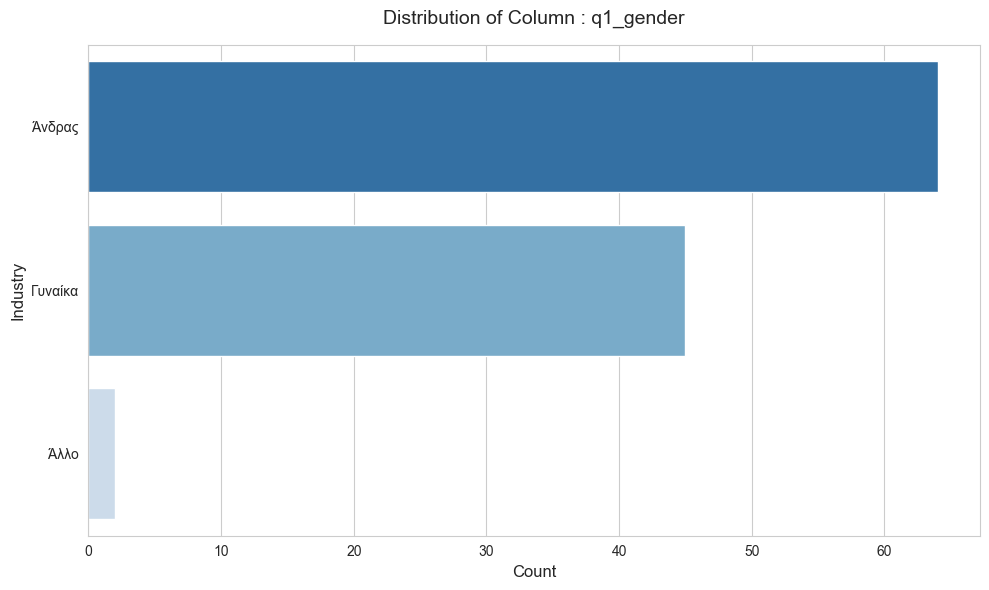

Normalized frequencies of column: q2_age_group
26-41    0.549550
42-57    0.261261
18-25    0.108108
58+      0.081081
Name: proportion, dtype: float64


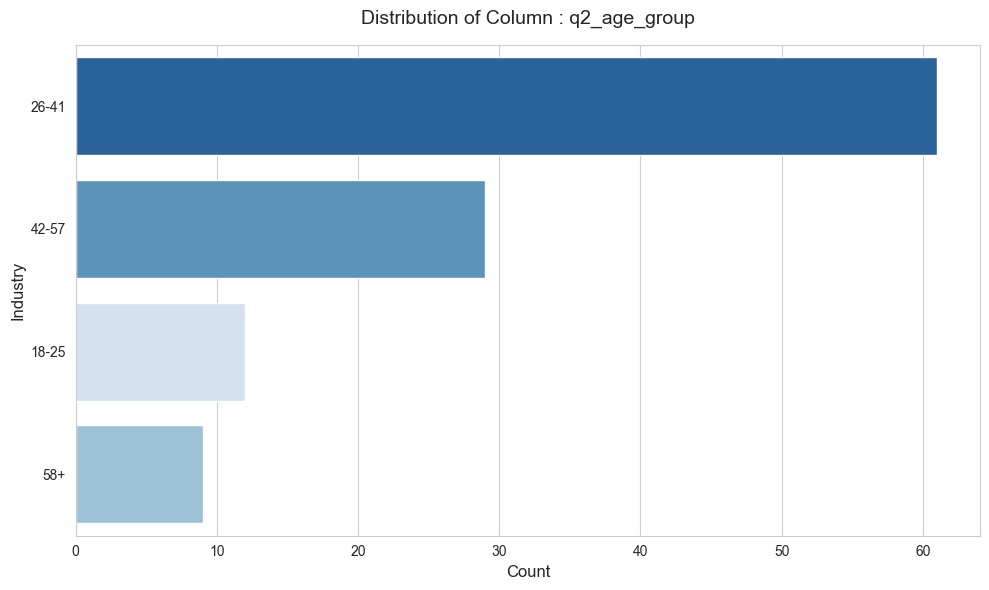

Normalized frequencies of column: q3_education_level
Μεταπτυχιακό Δίπλωμα        0.468468
Πτυχίο ΑΕΙ-ΤΕΙ              0.405405
Δευτεροβάθμια Εκπαίδευση    0.081081
Διδακτορικό Δίπλωμα         0.045045
Name: proportion, dtype: float64


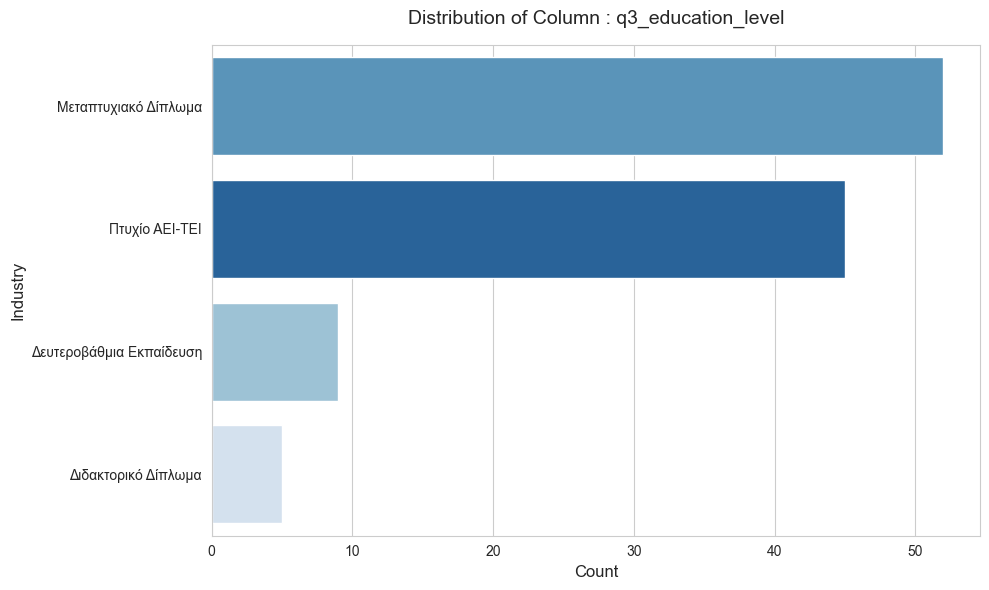

Normalized frequencies of column: q4_white_collar_status
Δουλεύω σε έναν εργοδότη                 0.927928
Δουλεύω σε παραπάνω από έναν εργοδότη    0.072072
Name: proportion, dtype: float64


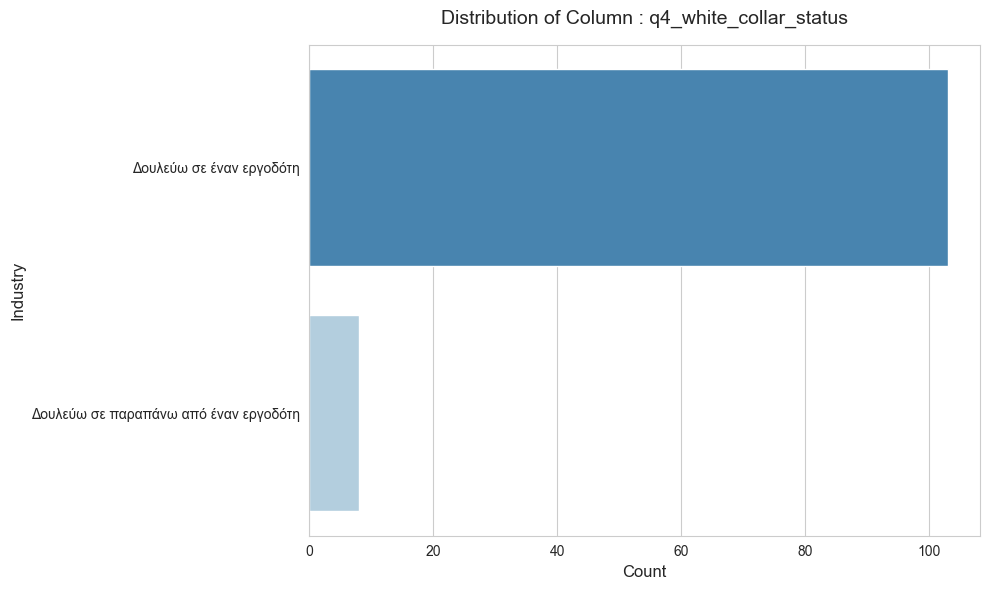

Normalized frequencies of column: q5_industry
Τεχνολογία & Πληροφορική            0.396396
Δημόσιος Τομέας                     0.135135
Άλλο                                0.117117
Διοικητική Υποστήριξη               0.117117
Οικονομικά, Τράπεζες & Ασφάλειες    0.108108
Πωλήσεις & Εξυπηρέτηση Πελατών      0.081081
Μάρκετινγκ & Επικοινωνία            0.027027
Ανθρώπινο Δυναμικό                  0.018018
Name: proportion, dtype: float64


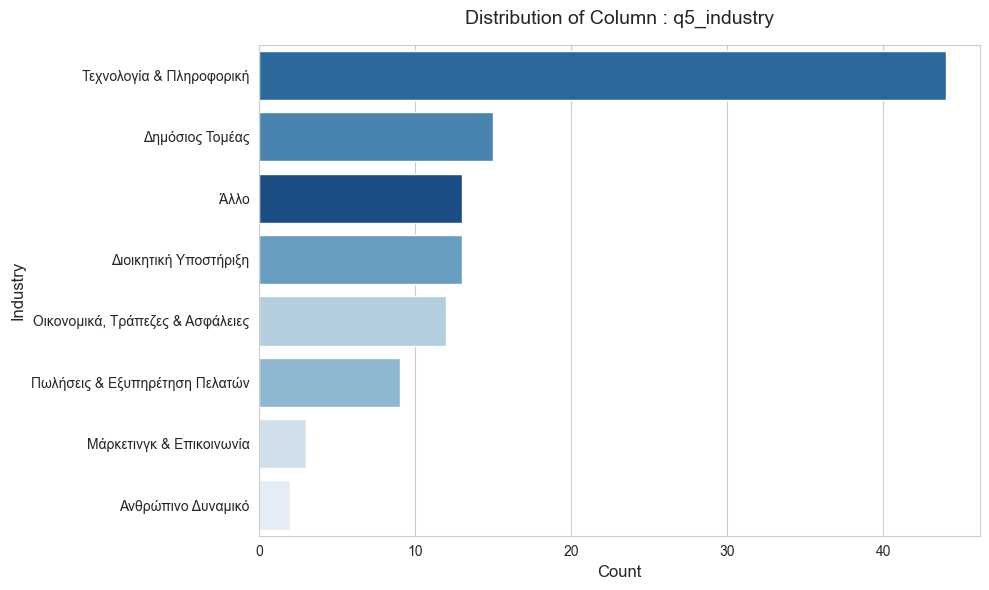

Normalized frequencies of column: q6_job_level
Mid-level      0.450450
Entry Level    0.225225
Senior         0.180180
Management     0.117117
Executive      0.027027
Name: proportion, dtype: float64


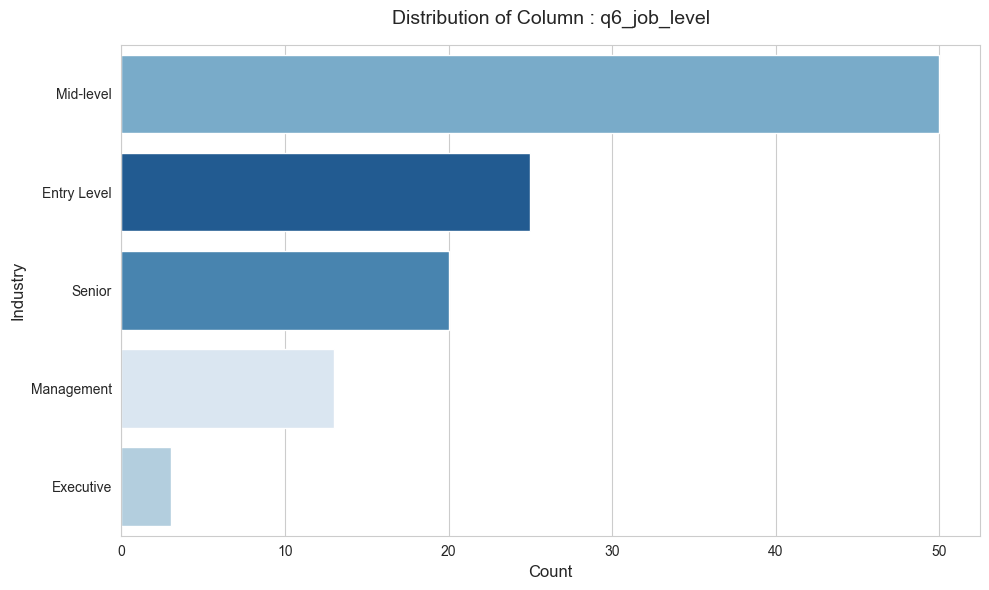

Normalized frequencies of column: q7_company_size
Μικρομεσαία (11-250 άτομα)          0.468468
Μεγάλη - Πολυεθνική (250+ άτομα)    0.441441
Πολύ μικρή (έως 10 άτομα)           0.090090
Name: proportion, dtype: float64


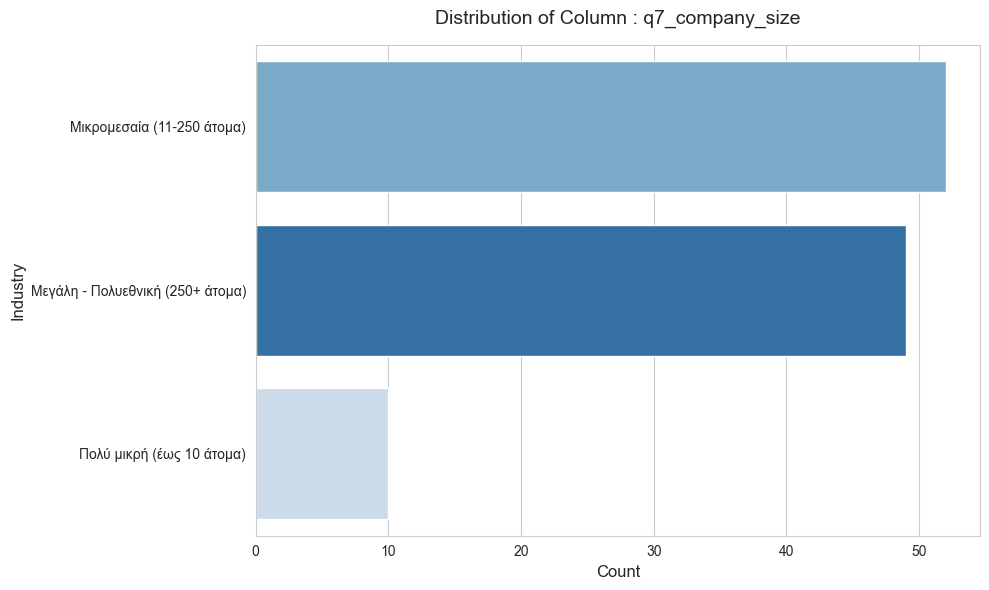

Normalized frequencies of column: q8_total_experience
20+      0.279279
6-10     0.234234
0-2      0.198198
3-5      0.171171
11-20    0.117117
Name: proportion, dtype: float64


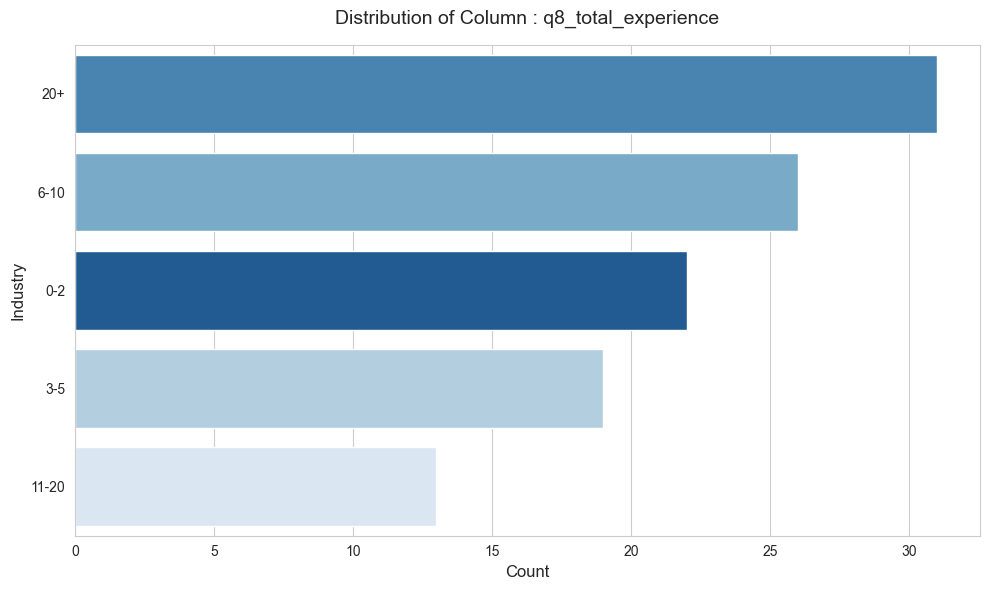

Normalized frequencies of column: q9_tenure_current_employer
Πάνω από 5 έτη         0.324324
3-5 έτη                0.243243
Λιγότερο από 1 έτος    0.243243
1-2 έτη                0.189189
Name: proportion, dtype: float64


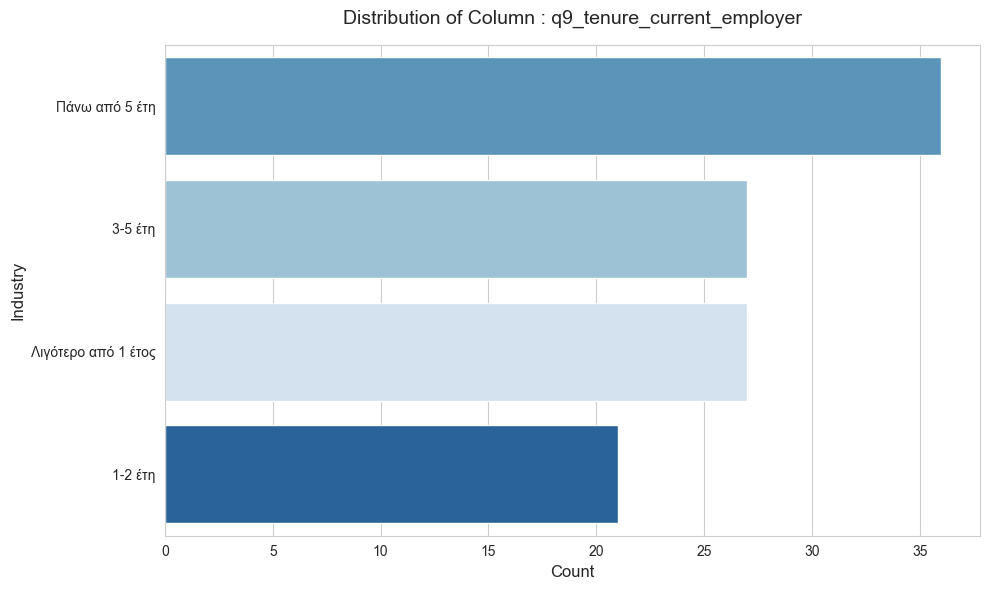

Normalized frequencies of column: q10_job_satisfaction
4    0.396396
3    0.306306
5    0.171171
2    0.108108
1    0.018018
Name: proportion, dtype: float64


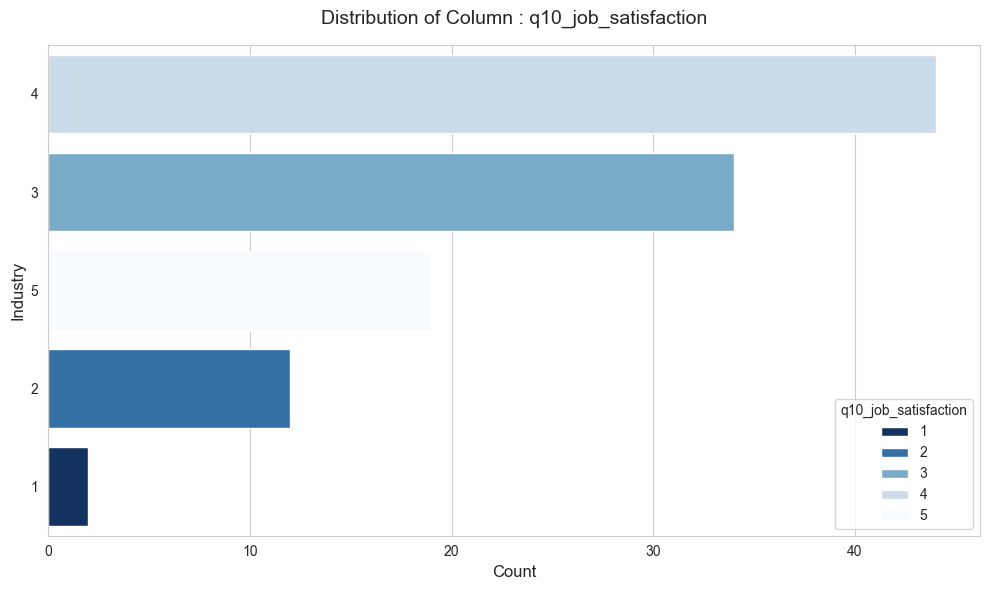

Normalized frequencies of column: q11_financial_satisfaction
4    0.351351
3    0.234234
2    0.162162
5    0.153153
1    0.099099
Name: proportion, dtype: float64


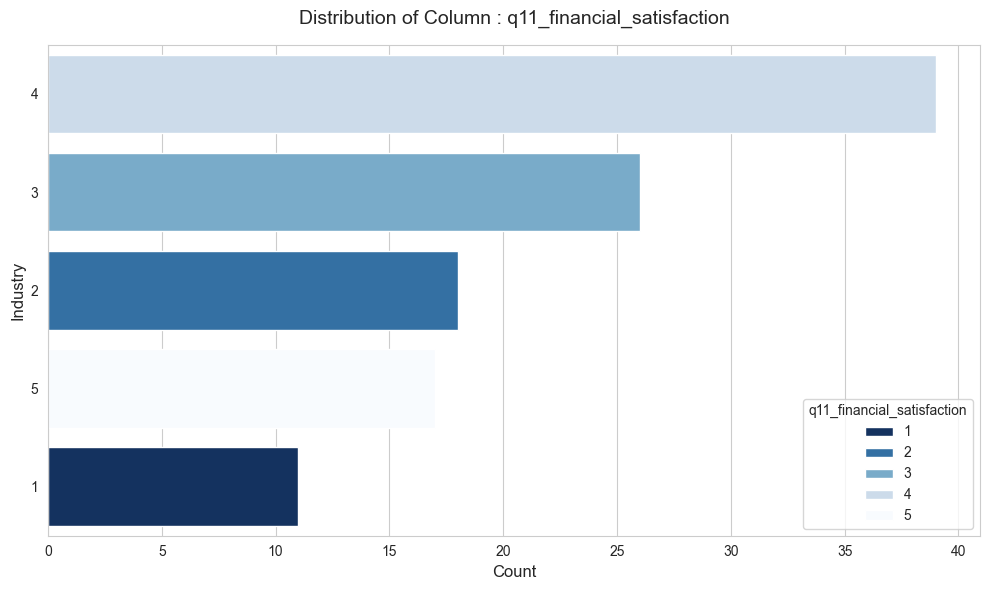

Normalized frequencies of column: q12_ideal_stay_duration
3-5 έτη           0.558559
Πάνω από 5 έτη    0.288288
1-2 έτη           0.153153
Name: proportion, dtype: float64


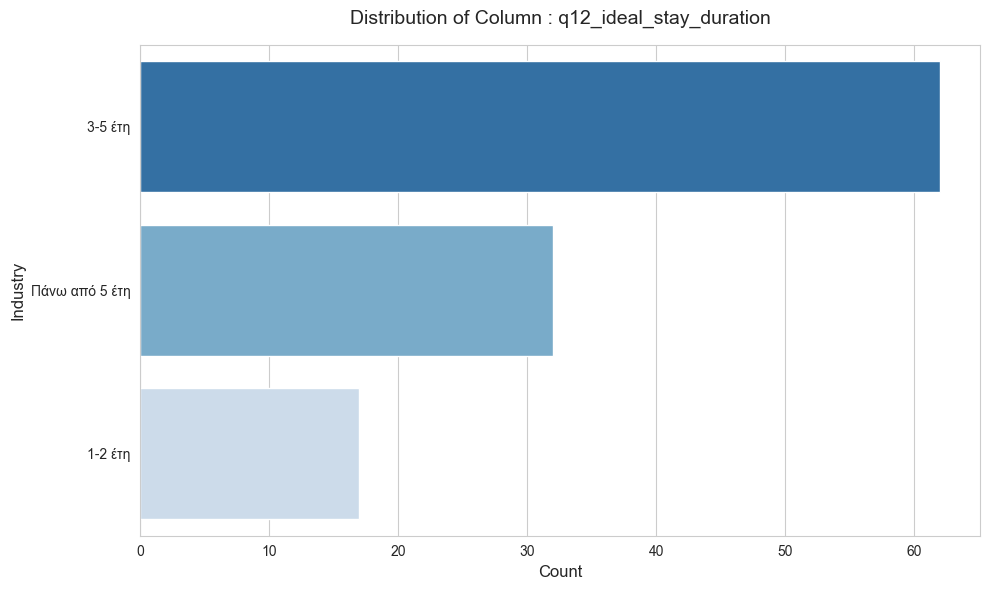

Normalized frequencies of column: q13_profile_update_frequency
Πολύ σπάνια                  0.432432
Κάθε χρόνο                   0.162162
Κάθε 6 μήνες                 0.162162
Κάθε 3 μήνες                 0.108108
Κάθε μήνα                    0.090090
Κάθε εβδομάδα ή πιο συχνά    0.045045
Name: proportion, dtype: float64


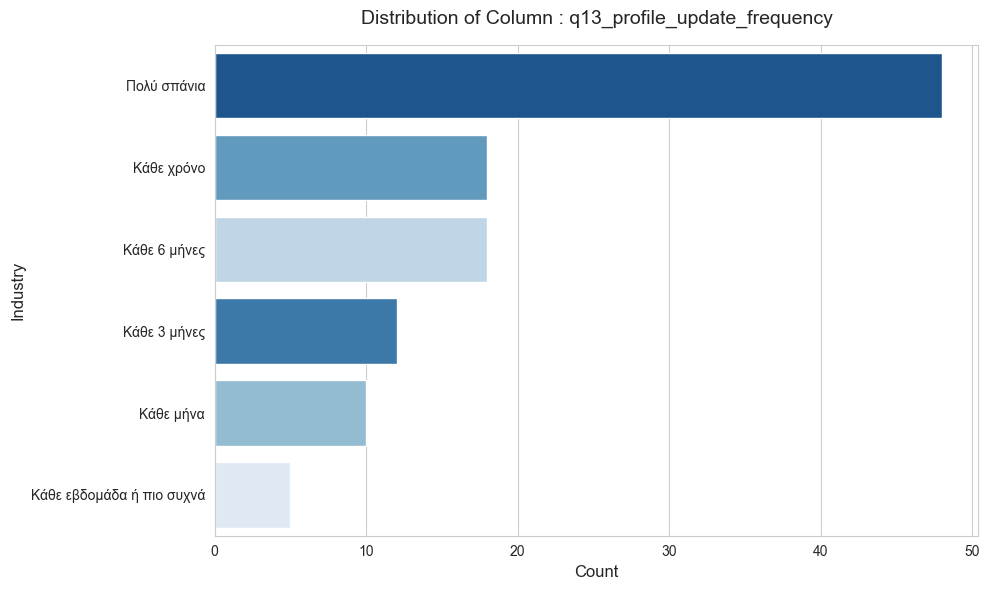

Normalized frequencies of column: q14_thought_change_frequency
Δεν το σκέφτομαι    0.387387
Κάθε χρόνο          0.207207
Κάθε μήνα           0.108108
Κάθε 3 μήνες        0.108108
Κάθε εβδομάδα       0.099099
Κάθε 6 μήνες        0.090090
Name: proportion, dtype: float64


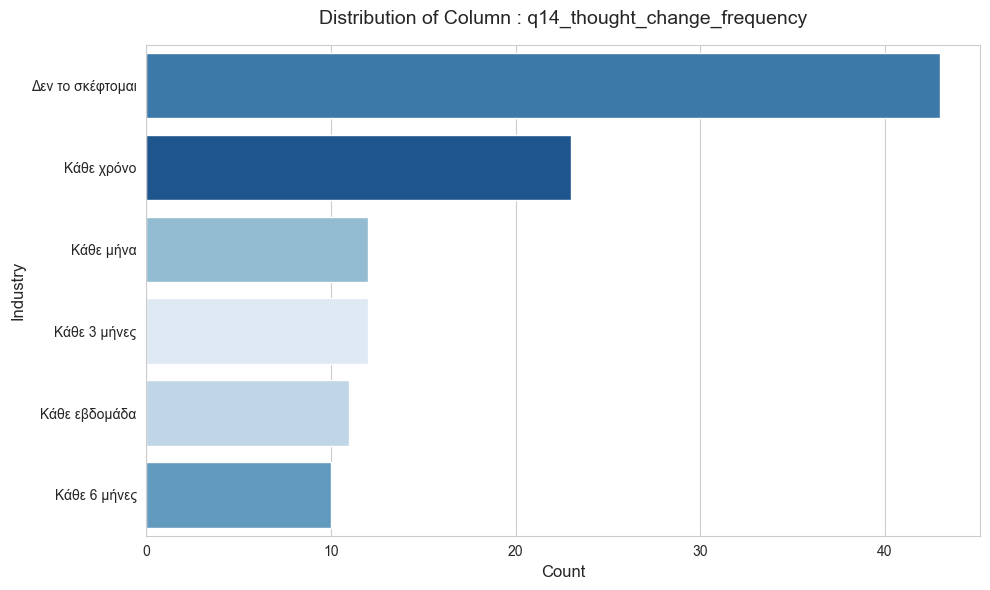

Normalized frequencies of column: q15_job_hopping_awareness
Ναι    0.738739
Όχι    0.261261
Name: proportion, dtype: float64


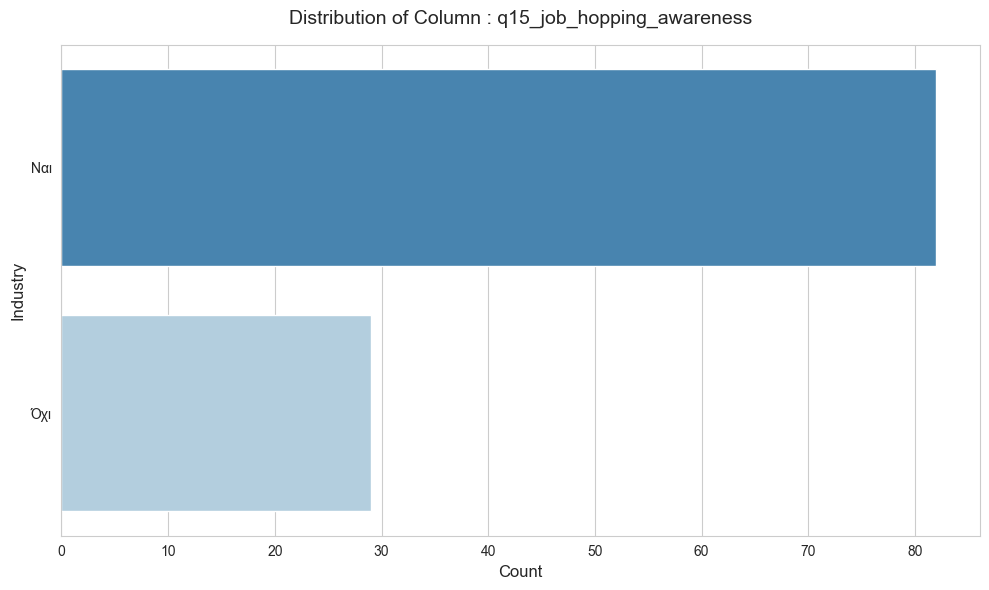

Normalized frequencies of column: q16_job_hopping_benefit
4    0.360360
3    0.351351
2    0.144144
5    0.126126
1    0.018018
Name: proportion, dtype: float64


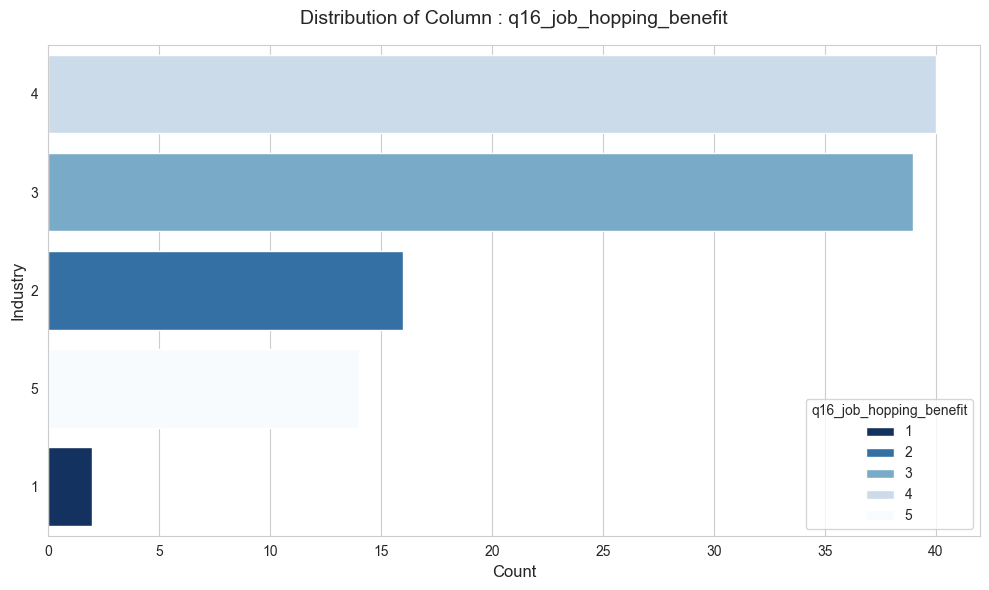

Normalized frequencies of column: q17_job_hopping_history
Όχι    0.738739
Ναι    0.261261
Name: proportion, dtype: float64


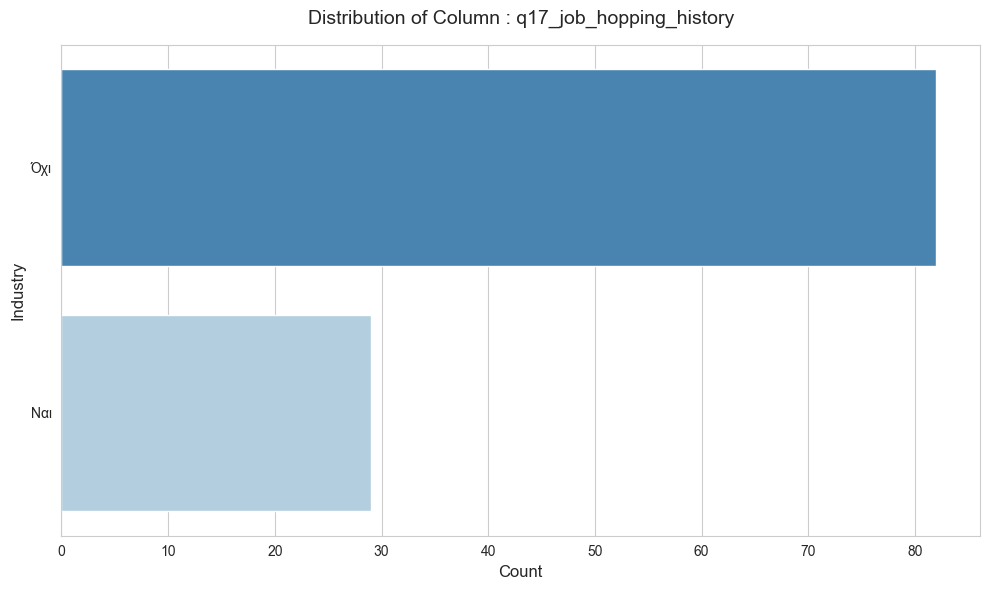

Normalized frequencies of column: q18_attrition_intent
Όχι    0.585586
Ναι    0.414414
Name: proportion, dtype: float64


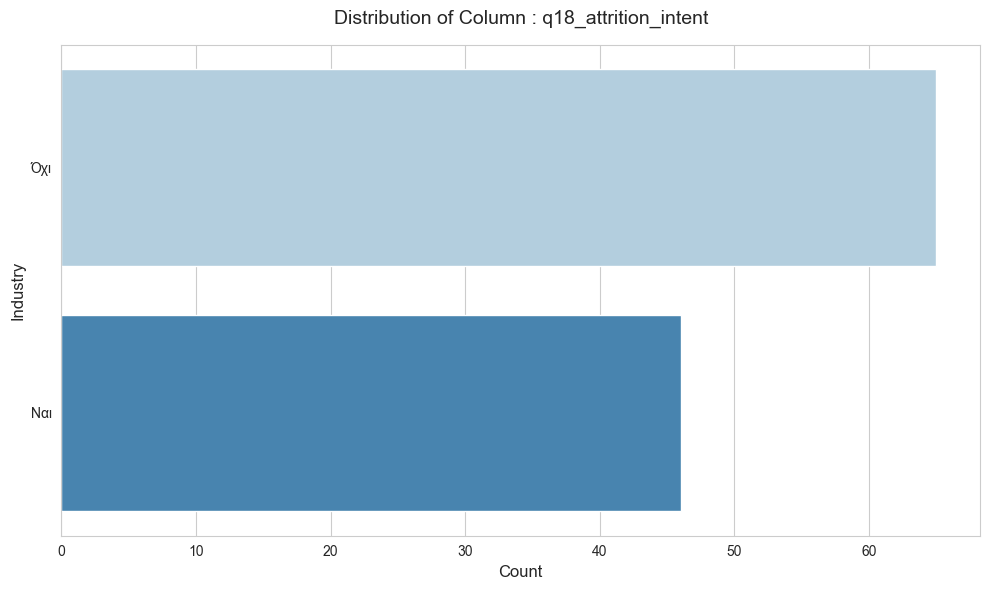

Normalized frequencies of column: q19_employers_changed_5years
0     0.450450
1     0.198198
2     0.189189
3+    0.162162
Name: proportion, dtype: float64


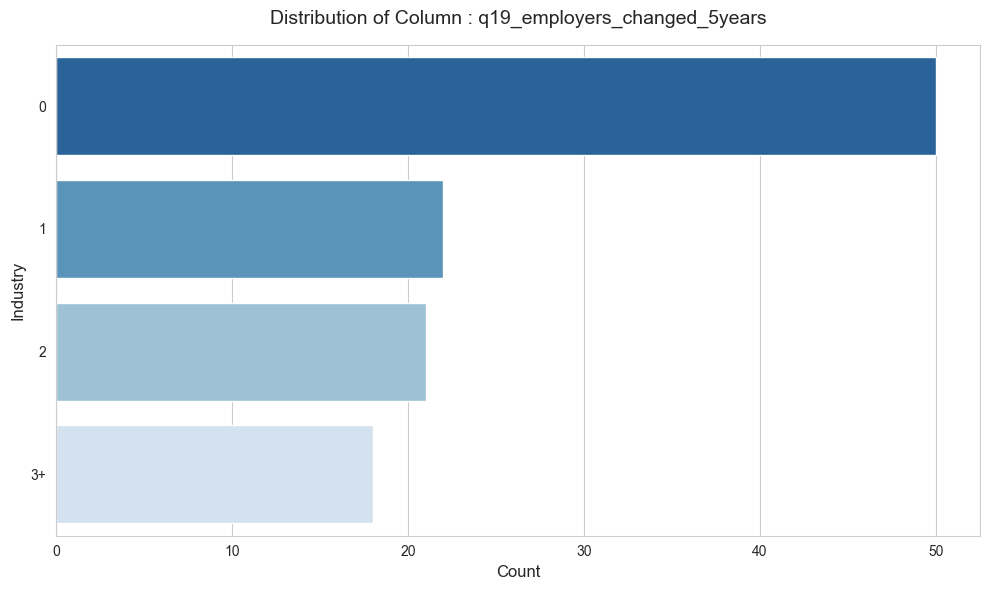

Normalized frequencies of column: q20_fair_reward_perception
Μέτρια       0.459459
Πολύ         0.252252
Λίγο         0.153153
Πάρα πολύ    0.072072
Καθόλου      0.063063
Name: proportion, dtype: float64


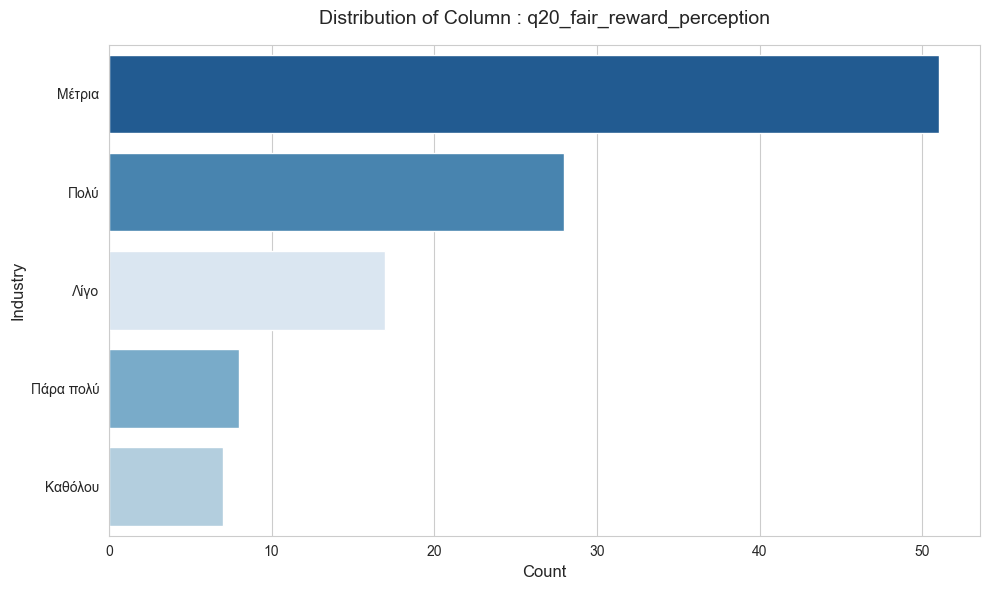

Normalized frequencies of column: q21_minimum_effort_frequency
Δεν το κάνω    0.279279
Μέτρια         0.189189
Συχνά          0.180180
Σπάνια         0.162162
Πολύ σπάνια    0.153153
Πολύ συχνά     0.036036
Name: proportion, dtype: float64


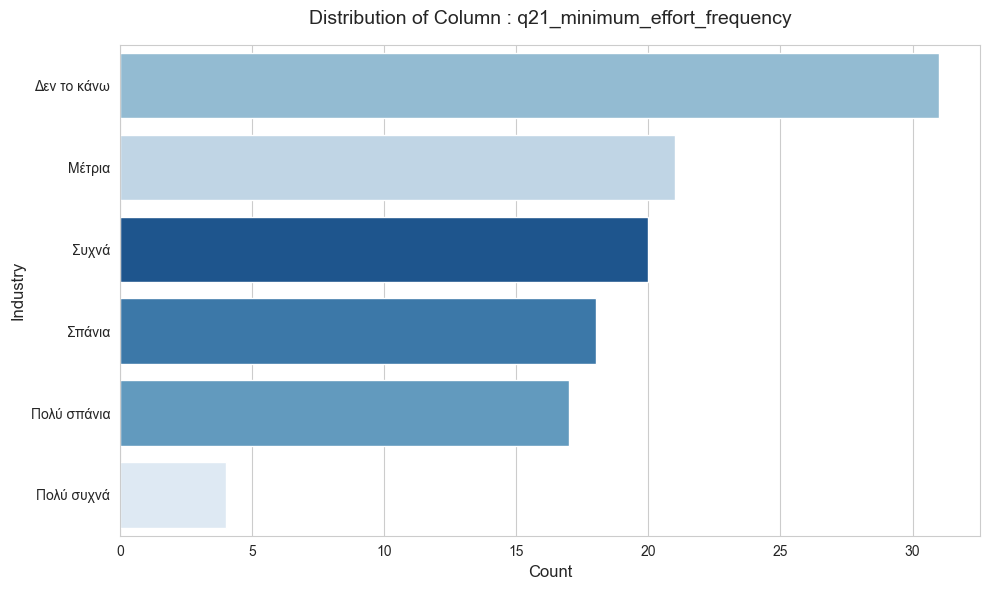

Normalized frequencies of column: q22_retention_due_to_costs
Ναι    0.540541
Όχι    0.459459
Name: proportion, dtype: float64


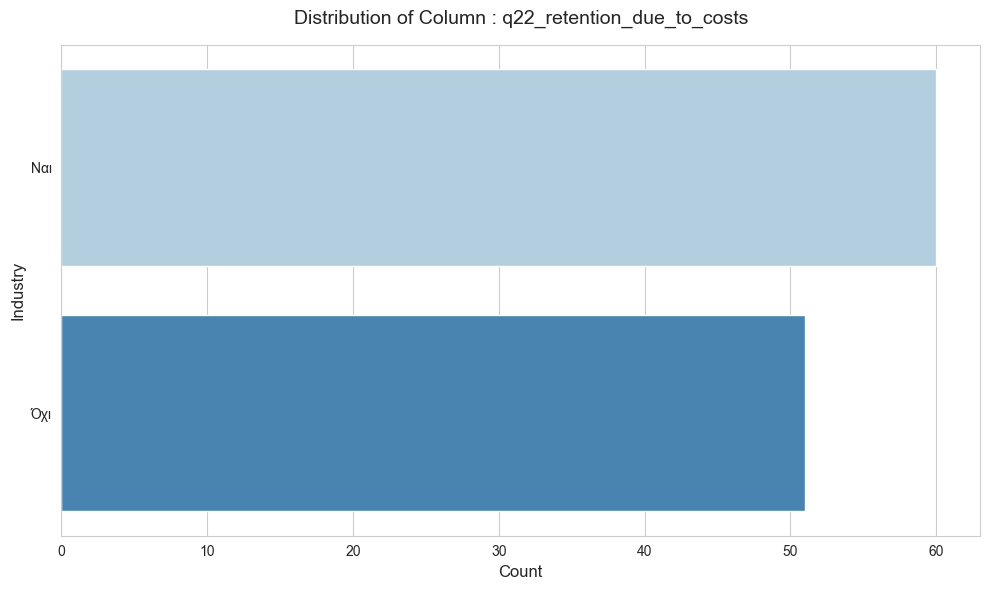

Normalized frequencies of column: q23_quiet_quitting_history
Όχι                      0.630631
Ναι                      0.297297
Δεν ξέρω - Δεν απαντώ    0.072072
Name: proportion, dtype: float64


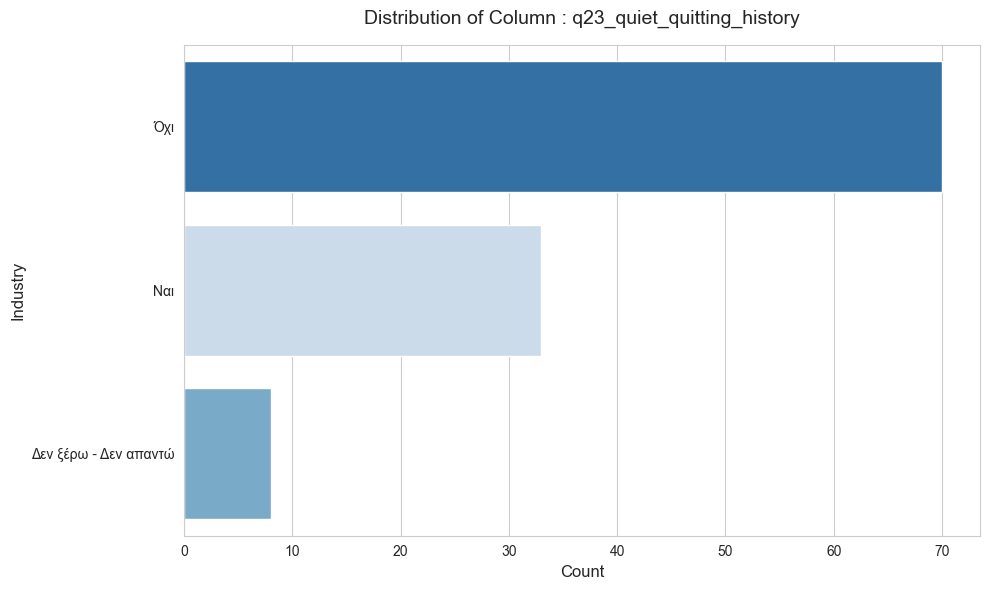

Normalized frequencies of column: q24_quiet_quitting_benefit
3    0.288288
4    0.252252
2    0.153153
5    0.153153
1    0.153153
Name: proportion, dtype: float64


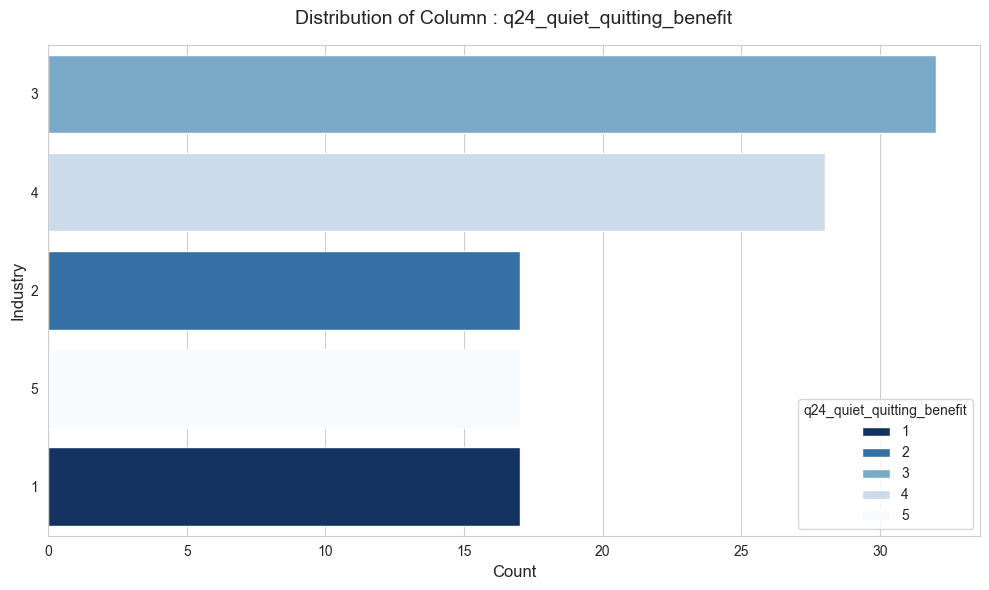

Normalized frequencies of column: q25_current_work_model
Δια ζώσης (On-Site)    0.585586
Υβριδικό (Hybrid)      0.279279
Τηλεργασία (Remote)    0.135135
Name: proportion, dtype: float64


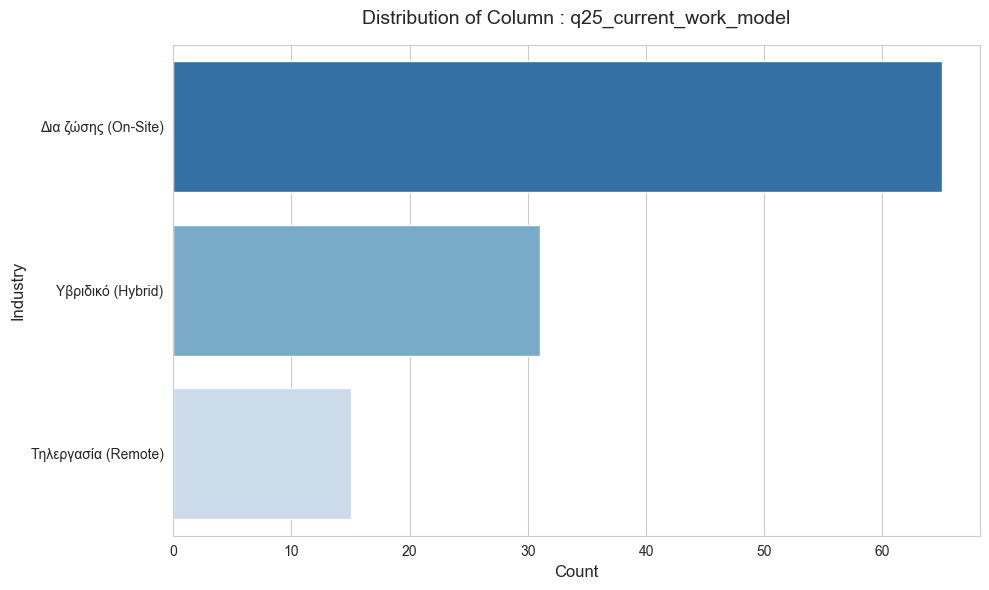

Normalized frequencies of column: q26_preferred_work_model
Υβριδικό (Hybrid)      0.594595
Τηλεργασία (Remote)    0.288288
Δια ζώσης (On-site)    0.117117
Name: proportion, dtype: float64


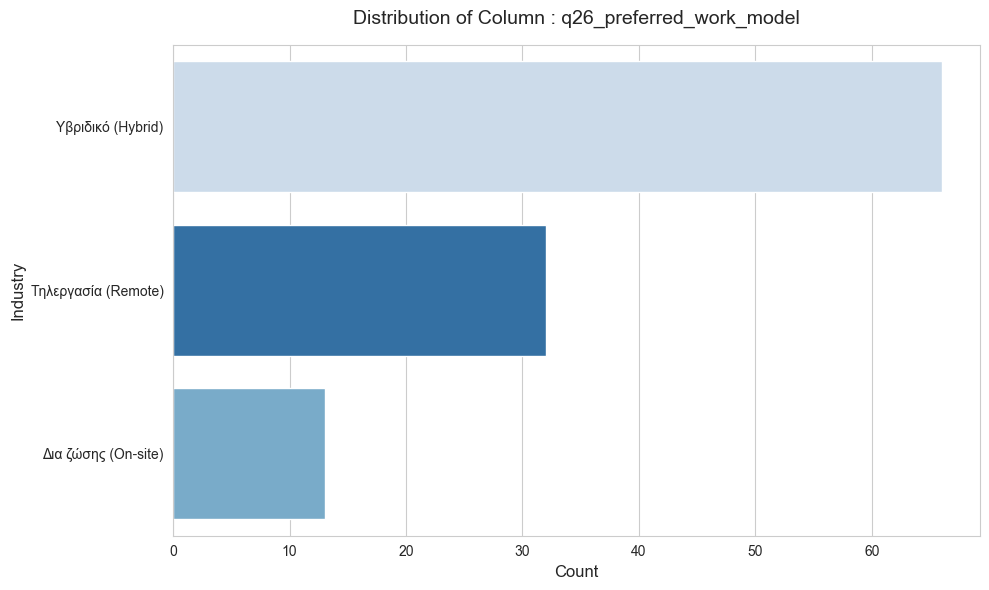

Normalized frequencies of column: q27_overtime_frequency
Πολύ λίγο (1-15 μέρες)    0.468468
Λίγο (16 - 30 μέρες)      0.216216
Μέτρια (31 - 60 μέρες)    0.144144
Πάρα πολύ (91+ μέρες)     0.108108
Πολύ (61 - 90 μέρες)      0.063063
Name: proportion, dtype: float64


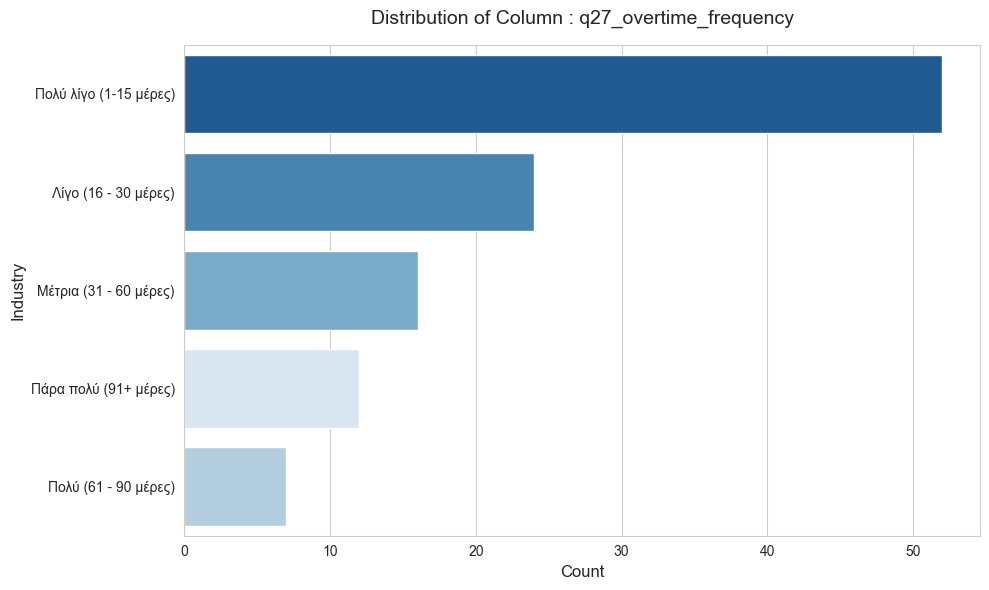

Normalized frequencies of column: q28_emotional_exhaustion_frequency
Μέτρια συχνότητα               0.351351
Πολλές φορές τον χρόνο         0.252252
Πάρα πολλές φορες τον χρόνο    0.180180
Λίγες φορές τον χρόνο          0.171171
Πολύ λίγες φορές τον χρόνο     0.045045
Name: proportion, dtype: float64


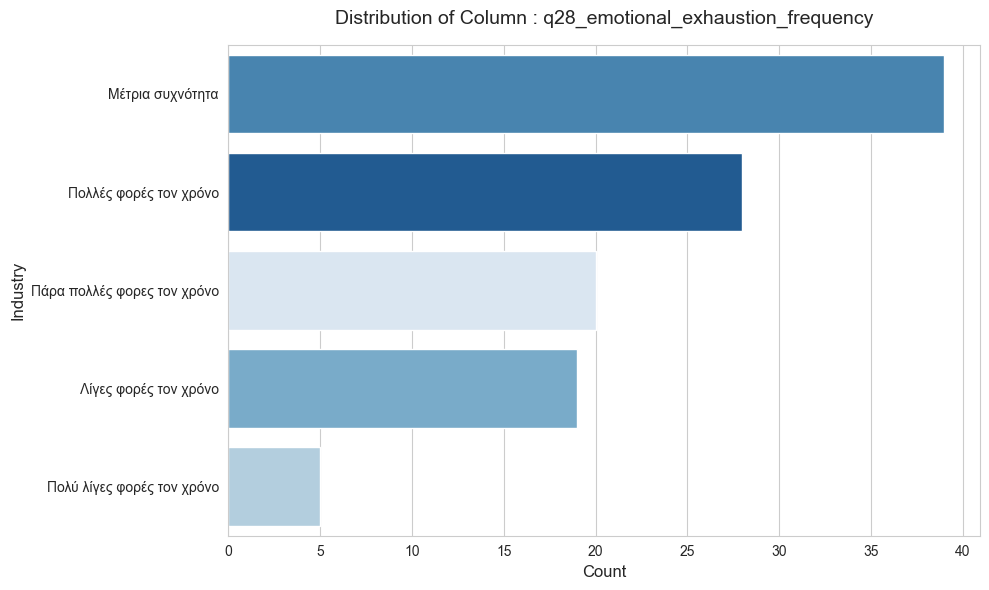

Normalized frequencies of column: q29_stress_level
Μέτρια έντονο       0.441441
Λίγο έντονο         0.216216
Πολύ έντονο         0.207207
Καθόλου έντονο      0.090090
Πάρα πολύ έντονο    0.045045
Name: proportion, dtype: float64


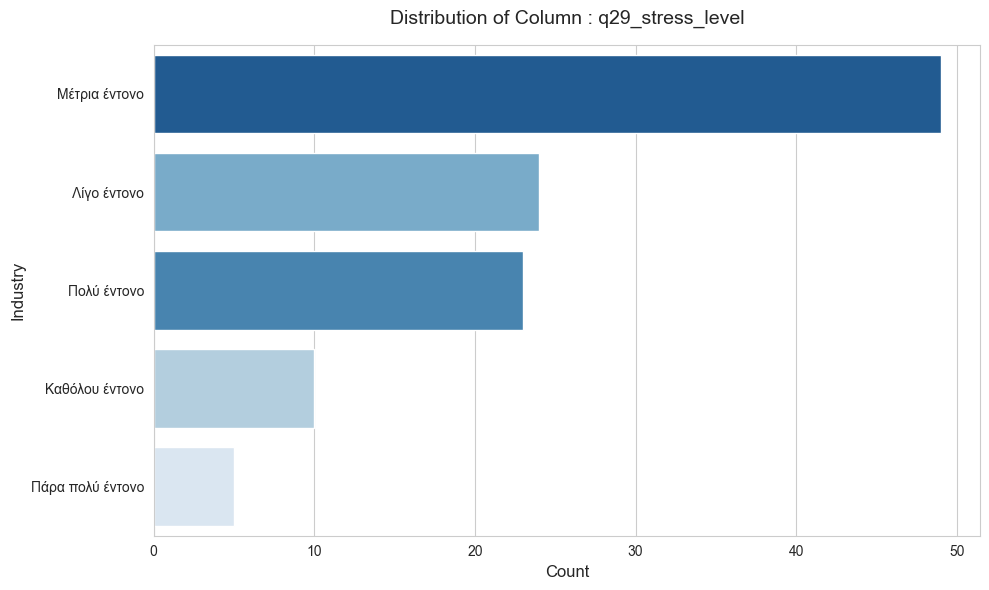

Normalized frequencies of column: q30_stress_work_model_connection
Μέτρια σύνδεση               0.324324
Άμεση σύνδεση                0.252252
Ελάχιστη σύνδεση             0.207207
Καμία σύνδεση μεταξύ τους    0.144144
Δέν ξέρω - Δεν απαντώ        0.072072
Name: proportion, dtype: float64


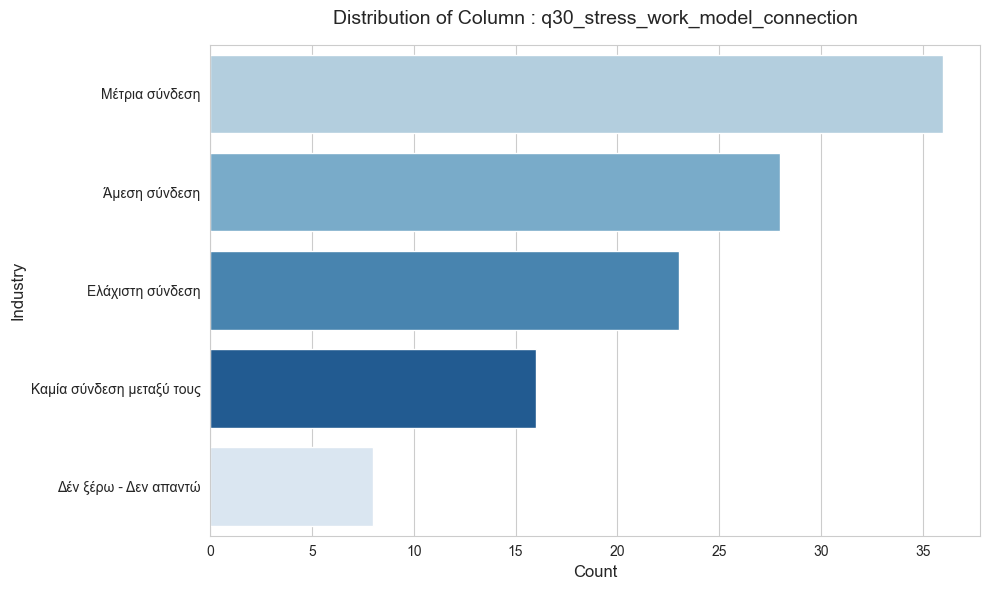

Normalized frequencies of column: q31_employer_wellbeing_interest
Λίγο ενδιαφέρον      0.297297
Μέτριο ενδιαφέρον    0.252252
Δεν ενδιαφέρεται     0.216216
Ενδιαφέρεται         0.135135
Δεν ξέρω             0.054054
Πολύ ενδιαφέρον      0.045045
Name: proportion, dtype: float64


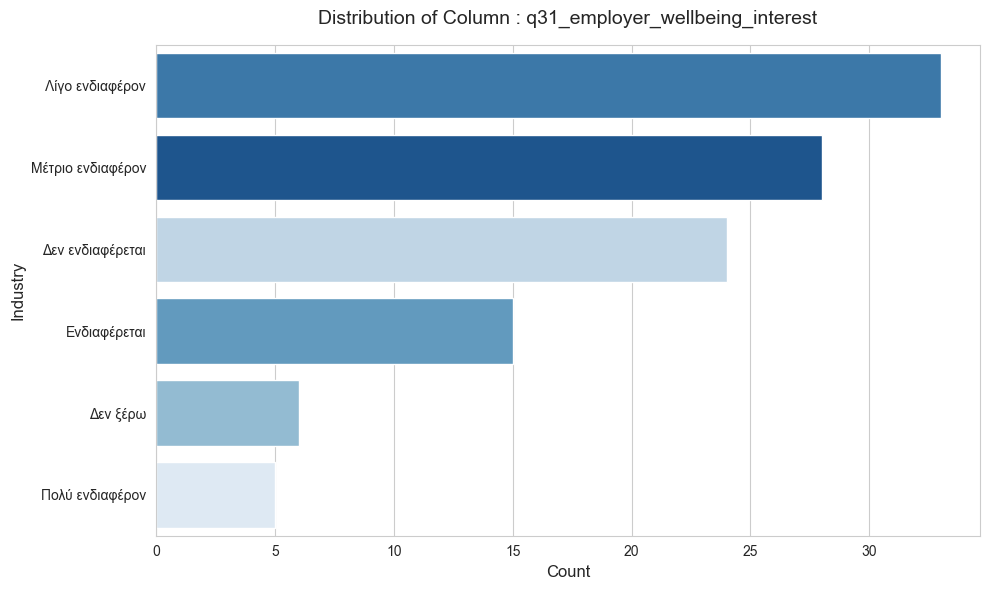

Normalized frequencies of column: q32_work_life_priority
3    0.378378
4    0.306306
2    0.180180
1    0.072072
5    0.063063
Name: proportion, dtype: float64


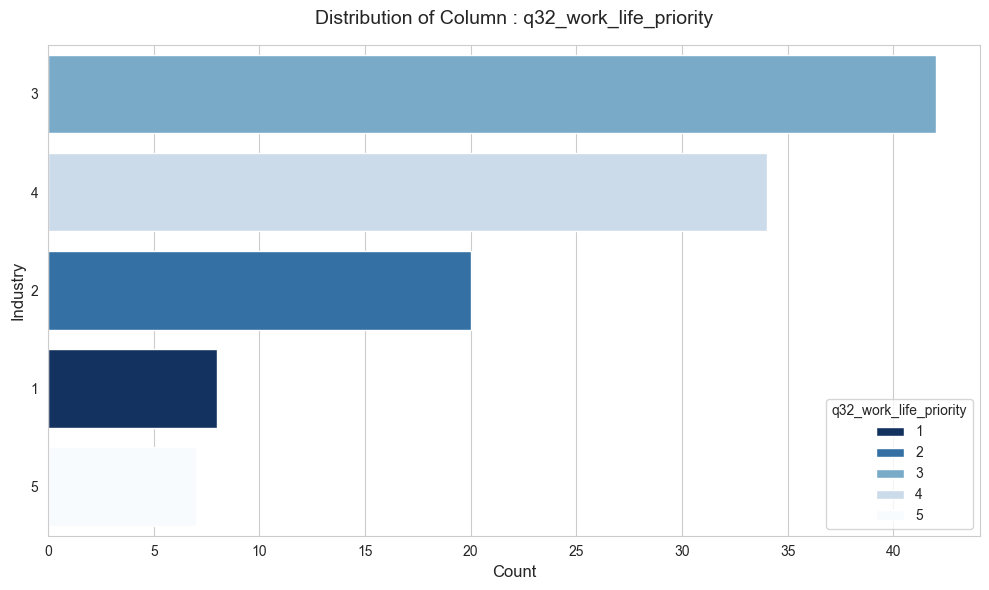

Normalized frequencies of column: q33_change_probability_12months
5    0.243243
1    0.234234
3    0.189189
4    0.171171
2    0.162162
Name: proportion, dtype: float64


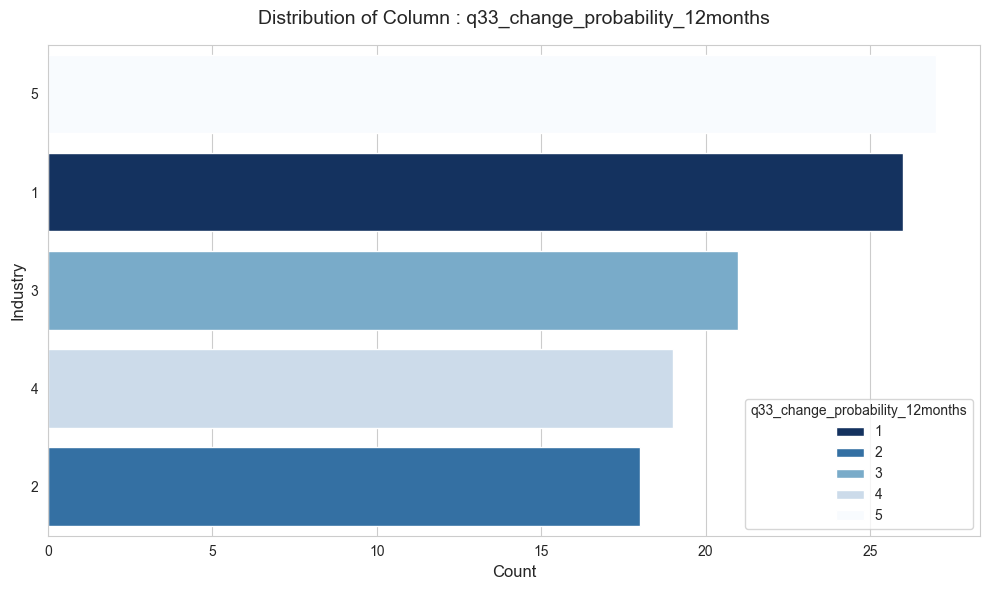

In [9]:
#the analysis is interesetd only in white collar workers, thus the non-white collar workers that filled the questionnaire will be removed
dataset = dataset[dataset['q4_white_collar_status']!='Δεν ειμαι White-Collar Worker']

#new distributions:
column_distributions(dataset)

In [10]:
#q28 and q29 are questions on likert scale (1-5) that need ordinal encoding for further analysis

#usied originally the OrdinalEncoder object from scikit-learn but decided to do it manually to ensure the correct order
# from sklearn.preprocessing import OrdinalEncoder

q28_mapping = {
'Πολύ λίγες φορές τον χρόνο':1,
'Λίγες φορές τον χρόνο':2,
'Μέτρια συχνότητα':3,
'Πολλές φορές τον χρόνο':4,
'Πάρα πολλές φορες τον χρόνο':5
}

q29_mapping = {
'Καθόλου έντονο':1,
'Λίγο έντονο':2,
'Μέτρια έντονο':3,
'Πολύ έντονο':4,
'Πάρα πολύ έντονο':5
}
# using .map() to perform what would otherwise have been done with two lists and two for-loops
dataset['enc_q28_emotional_exhaustion_frequency'] = dataset['q28_emotional_exhaustion_frequency'].map(q28_mapping)
dataset['enc_q29_stress_level'] = dataset['q29_stress_level'].map(q29_mapping)

                                        q10_job_satisfaction  \
q10_job_satisfaction                                1.000000   
q11_financial_satisfaction                          0.559260   
q16_job_hopping_benefit                            -0.196295   
q24_quiet_quitting_benefit                         -0.253216   
enc_q28_emotional_exhaustion_frequency             -0.366872   
enc_q29_stress_level                               -0.147635   
q32_work_life_priority                              0.282296   
q33_change_probability_12months                    -0.467210   

                                        q11_financial_satisfaction  \
q10_job_satisfaction                                      0.559260   
q11_financial_satisfaction                                1.000000   
q16_job_hopping_benefit                                  -0.181914   
q24_quiet_quitting_benefit                               -0.204564   
enc_q28_emotional_exhaustion_frequency                   -0.262117   
enc

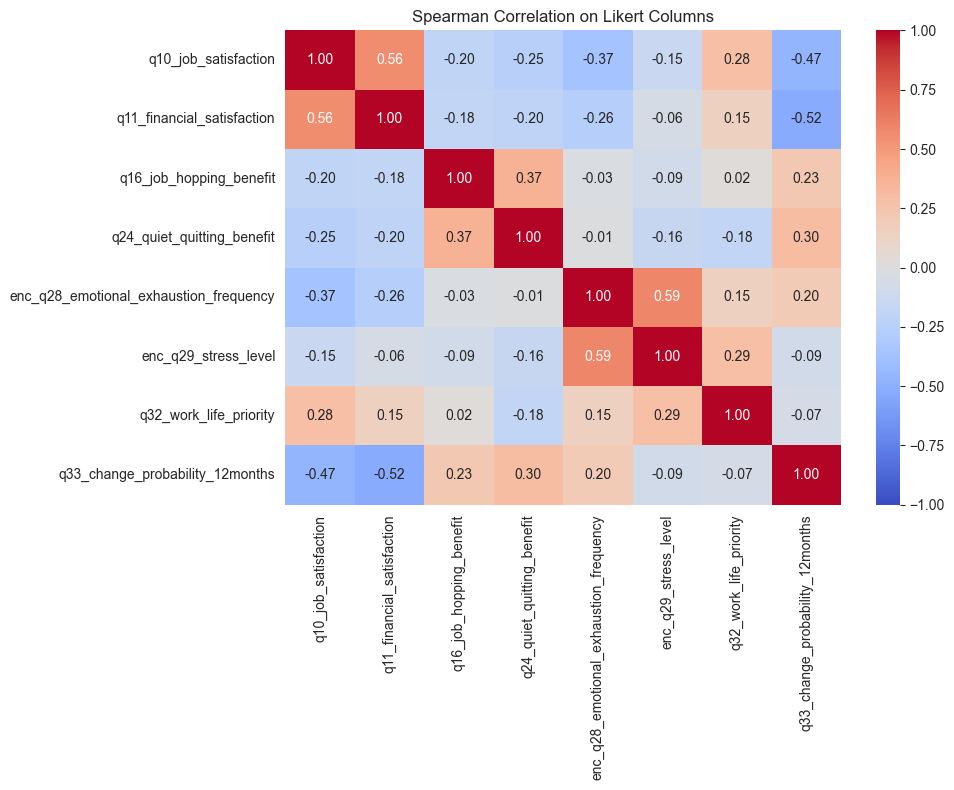

In [11]:
# listing all the likert collumns
likert_cols = ['q10_job_satisfaction', 'q11_financial_satisfaction',
               'q16_job_hopping_benefit', 'q24_quiet_quitting_benefit','enc_q28_emotional_exhaustion_frequency','enc_q29_stress_level',
               'q32_work_life_priority', 'q33_change_probability_12months']

dataset[likert_cols] = dataset[likert_cols].astype('float64')

#correlations based on Spearman for Likert columns
spearman_corr = dataset[likert_cols].corr(method='spearman')
print(spearman_corr)
plt.figure(figsize=(10,8))
sb.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin = -1, vmax = 1)
plt.title('Spearman Correlation on Likert Columns')
plt.tight_layout()
plt.show()

In [12]:
import numpy as np
from scipy.stats import chi2_contingency
#getting all the categorical columns
categorical_columns = []
#inserting each relevant column in the list
for column in dataset.columns:
    if column not in likert_cols+['q19_employers_changed_5years','Timestamp']:
        categorical_columns.append(column)


def cramers_v(x, y):
    # creating contingency table
    confusion_matrix = pd.crosstab(x, y)

    # X^2 calculation
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    # returning Cramer's V
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))


In [13]:
# creating a dataframe to store Cramer's V combinations and score
categorical_combinations_cramer_v = pd.DataFrame(columns = ['column1','column2','cramer_v'])

for column1 in categorical_columns:
    for column2 in categorical_columns:
        # the condition column1>column2 will be used to avoid having two column combinations that are the same for column1 and column2.
        # this will avoid having rows like the following example:
        # [[column1, column2, cramer_v],
        # [q18_attrition_intent, q14_thought_change_frequency, 0.5]
        # [q14_thought_change_frequency, q18_attrition_intent, 0.5]]
        if column1 > column2:
            result = cramers_v(dataset[column1], dataset[column2])
            categorical_combinations_cramer_v.loc[len(categorical_combinations_cramer_v.index)] = [column1, column2, result]

# sorting by descending order
categorical_combinations_cramer_v = categorical_combinations_cramer_v.sort_values(by=['cramer_v'], ascending=False)

# creating a list with the columns with Cramer's V score above 0.3
top_cramer_combinations = categorical_combinations_cramer_v[categorical_combinations_cramer_v['cramer_v'] >= 0.3]
#displaying the top cramer combinations found previously in a table format
display(top_cramer_combinations)

,column1,column2,cramer_v
188,q18_attrition_intent,q14_thought_change_frequency,0.599750
128,q8_total_experience,q2_age_group,0.564588
209,q22_retention_due_to_costs,q14_thought_change_frequency,0.563458
212,q22_retention_due_to_costs,q18_attrition_intent,0.530948
137,q8_total_experience,q15_job_hopping_awareness,0.478827
158,q9_tenure_current_employer,q8_total_experience,0.467156
10,q2_age_group,q15_job_hopping_awareness,0.447322
197,q20_fair_reward_perception,q18_attrition_intent,0.425661
68,q5_industry,q15_job_hopping_awareness,0.415967
186,q18_attrition_intent,q12_ideal_stay_duration,0.411321


In [14]:
# further bivarate analysis based on research questions, through grouped bar charts
# the below function will be used to visualize the frequency per categorical value, per likert target value
def grouped_bar_chart_creation(dataset, categorical_index, likert_target):
    ds_frequency_table = pd.crosstab(
        index=dataset[categorical_index],
        columns=dataset[likert_target]
    )
    #normalizing the rows
    ds_frequency_table = ds_frequency_table.div(ds_frequency_table.sum(axis=1), axis=0)
    ds_frequency_table.plot(
        kind='barh',
        stacked=True,
        figsize=(10,8),
        edgecolor='black',
    )

    #naming title and labels
    plt.title(f'Distribution of {likert_target} by {categorical_index}', fontsize=12, pad=15)
    plt.xlabel('Proportion (%)', fontsize=10)
    plt.ylabel(categorical_index, fontsize=10)

    #moving the likert target groups outside the main plot
    plt.legend(title=likert_target, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

    ds_frequency_table_with_totals = pd.crosstab(
        index=dataset[categorical_index],
        columns=dataset[likert_target],
        margins=True,
        margins_name='Total Counts'
    )
    print(ds_frequency_table_with_totals)
    print('\n')

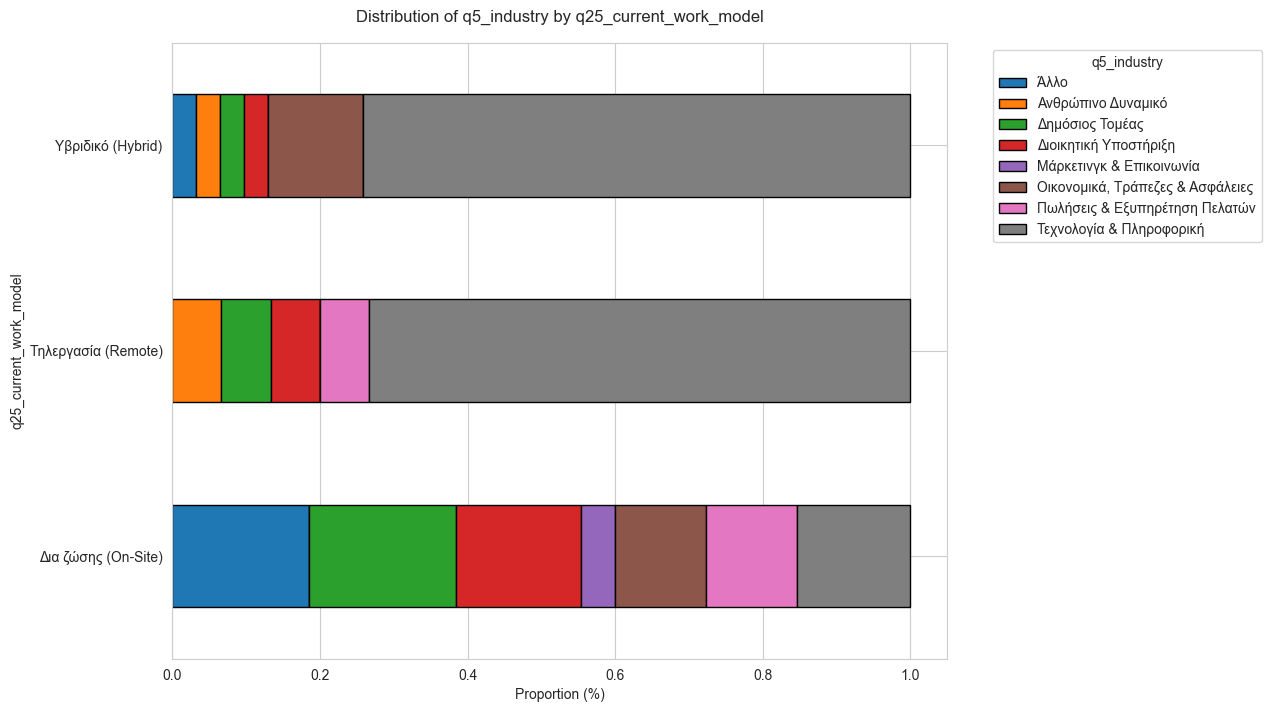

q5_industry             Άλλο  Ανθρώπινο Δυναμικό  Δημόσιος Τομέας  \
q25_current_work_model                                              
Δια ζώσης (On-Site)       12                   0               13   
Τηλεργασία (Remote)        0                   1                1   
Υβριδικό (Hybrid)          1                   1                1   
Total Counts              13                   2               15   

q5_industry             Διοικητική Υποστήριξη  Μάρκετινγκ & Επικοινωνία  \
q25_current_work_model                                                    
Δια ζώσης (On-Site)                        11                         3   
Τηλεργασία (Remote)                         1                         0   
Υβριδικό (Hybrid)                           1                         0   
Total Counts                               13                         3   

q5_industry             Οικονομικά, Τράπεζες & Ασφάλειες  \
q25_current_work_model                                     
Δια ζώσης (On-

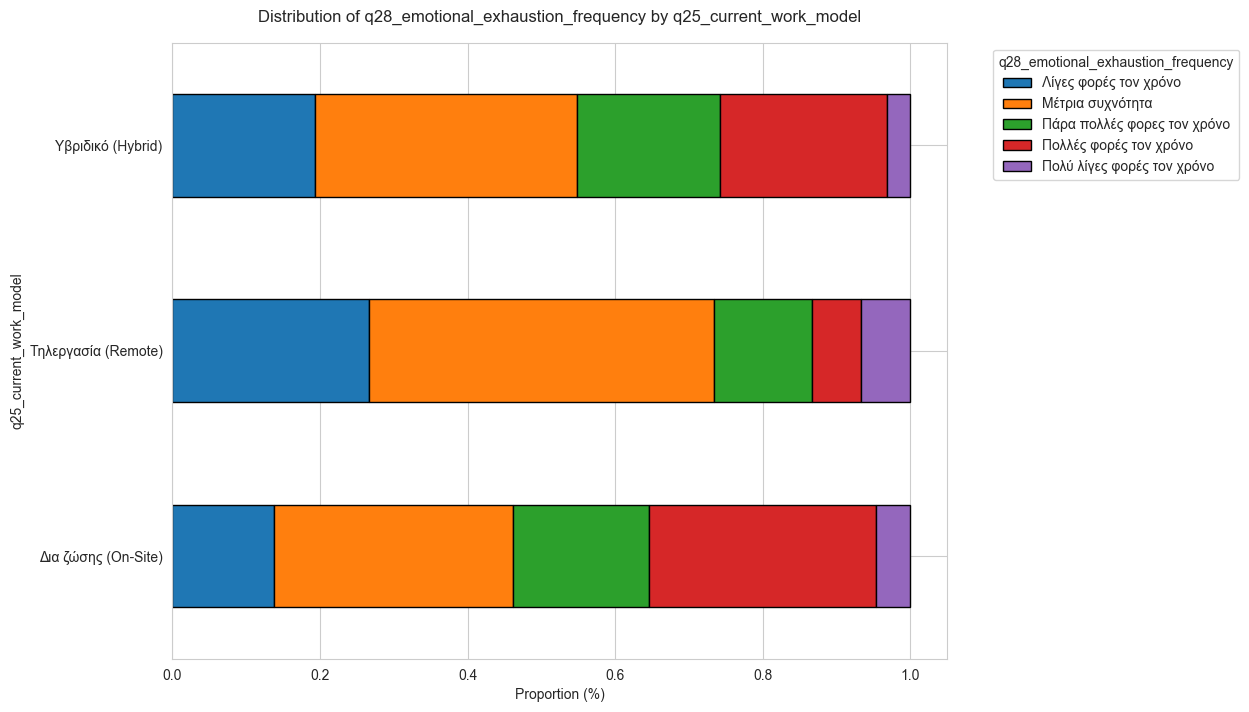

q28_emotional_exhaustion_frequency  Λίγες φορές τον χρόνο  Μέτρια συχνότητα  \
q25_current_work_model                                                        
Δια ζώσης (On-Site)                                     9                21   
Τηλεργασία (Remote)                                     4                 7   
Υβριδικό (Hybrid)                                       6                11   
Total Counts                                           19                39   

q28_emotional_exhaustion_frequency  Πάρα πολλές φορες τον χρόνο  \
q25_current_work_model                                            
Δια ζώσης (On-Site)                                          12   
Τηλεργασία (Remote)                                           2   
Υβριδικό (Hybrid)                                             6   
Total Counts                                                 20   

q28_emotional_exhaustion_frequency  Πολλές φορές τον χρόνο  \
q25_current_work_model                                      

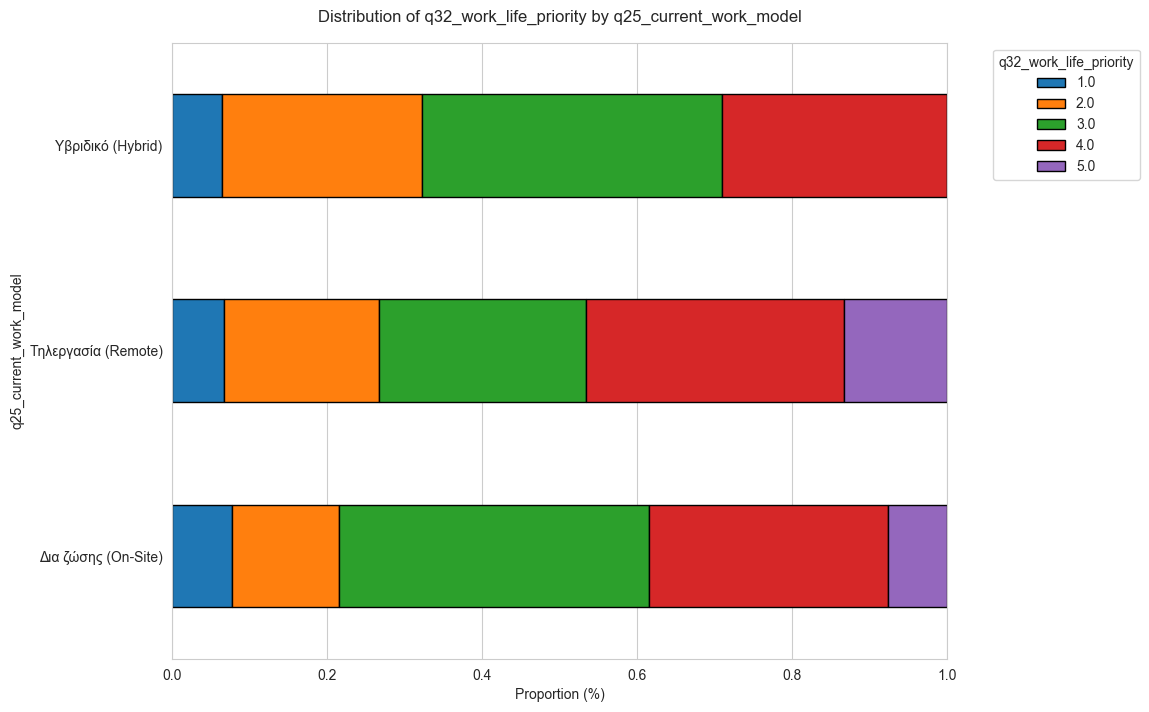

q32_work_life_priority  1.0  2.0  3.0  4.0  5.0  Total Counts
q25_current_work_model                                       
Δια ζώσης (On-Site)       5    9   26   20    5            65
Τηλεργασία (Remote)       1    3    4    5    2            15
Υβριδικό (Hybrid)         2    8   12    9    0            31
Total Counts              8   20   42   34    7           111




In [15]:
#q1 wellness-orientation profile in this dataset:
grouped_bar_chart_creation(dataset,'q25_current_work_model','q5_industry')
grouped_bar_chart_creation(dataset,'q25_current_work_model','q28_emotional_exhaustion_frequency')
grouped_bar_chart_creation(dataset,'q25_current_work_model','q32_work_life_priority')

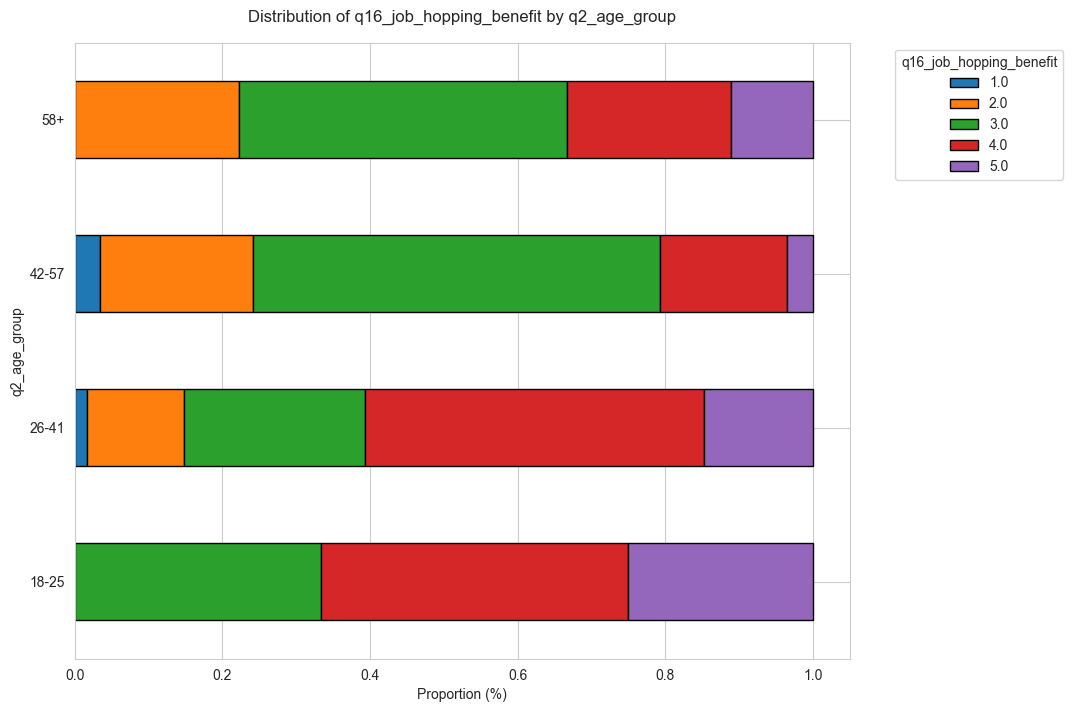

q16_job_hopping_benefit  1.0  2.0  3.0  4.0  5.0  Total Counts
q2_age_group                                                  
18-25                      0    0    4    5    3            12
26-41                      1    8   15   28    9            61
42-57                      1    6   16    5    1            29
58+                        0    2    4    2    1             9
Total Counts               2   16   39   40   14           111




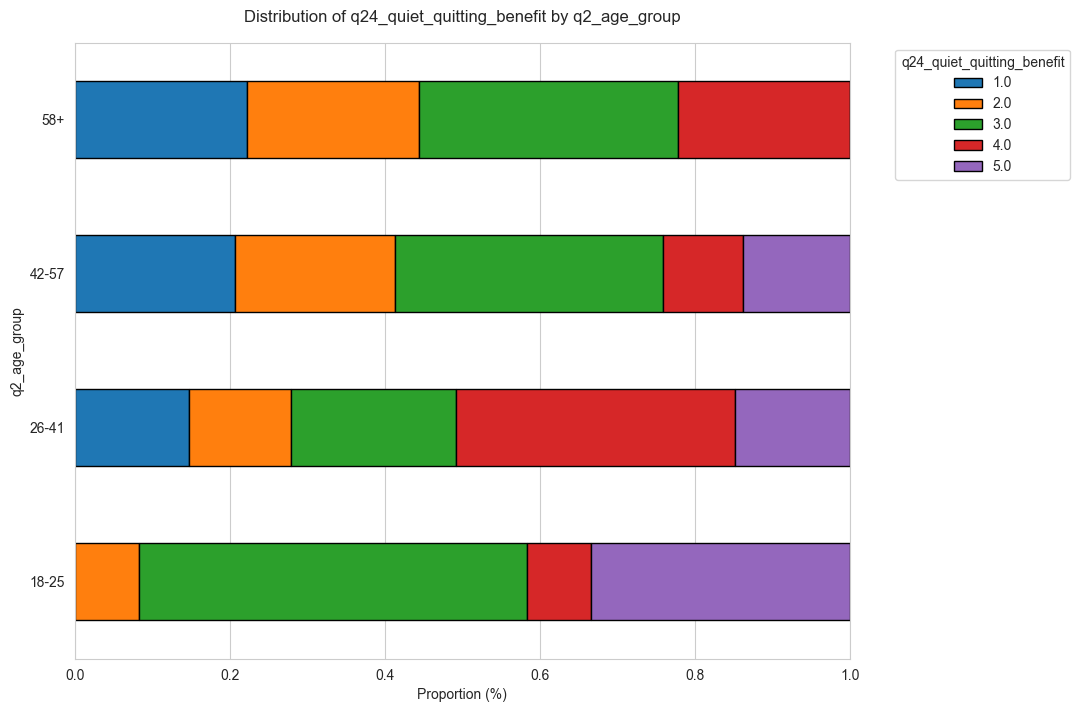

q24_quiet_quitting_benefit  1.0  2.0  3.0  4.0  5.0  Total Counts
q2_age_group                                                     
18-25                         0    1    6    1    4            12
26-41                         9    8   13   22    9            61
42-57                         6    6   10    3    4            29
58+                           2    2    3    2    0             9
Total Counts                 17   17   32   28   17           111




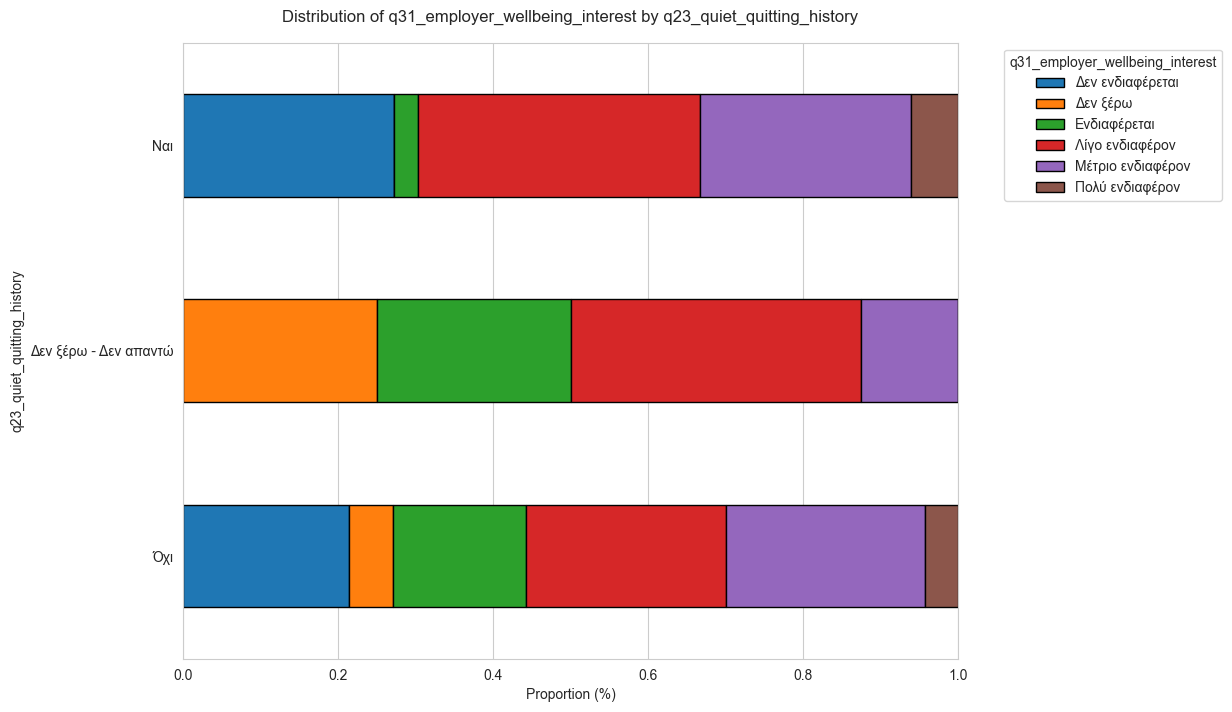

q31_employer_wellbeing_interest  Δεν ενδιαφέρεται  Δεν ξέρω  Ενδιαφέρεται  \
q23_quiet_quitting_history                                                  
Όχι                                            15         4            12   
Δεν ξέρω - Δεν απαντώ                           0         2             2   
Ναι                                             9         0             1   
Total Counts                                   24         6            15   

q31_employer_wellbeing_interest  Λίγο ενδιαφέρον  Μέτριο ενδιαφέρον  \
q23_quiet_quitting_history                                            
Όχι                                           18                 18   
Δεν ξέρω - Δεν απαντώ                          3                  1   
Ναι                                           12                  9   
Total Counts                                  33                 28   

q31_employer_wellbeing_interest  Πολύ ενδιαφέρον  Total Counts  
q23_quiet_quitting_history                   

In [16]:
#q2, quiet quitter and job hopper profile in this dataset:
grouped_bar_chart_creation(dataset, 'q2_age_group','q16_job_hopping_benefit')
grouped_bar_chart_creation(dataset, 'q2_age_group','q24_quiet_quitting_benefit')
grouped_bar_chart_creation(dataset,'q23_quiet_quitting_history','q31_employer_wellbeing_interest')

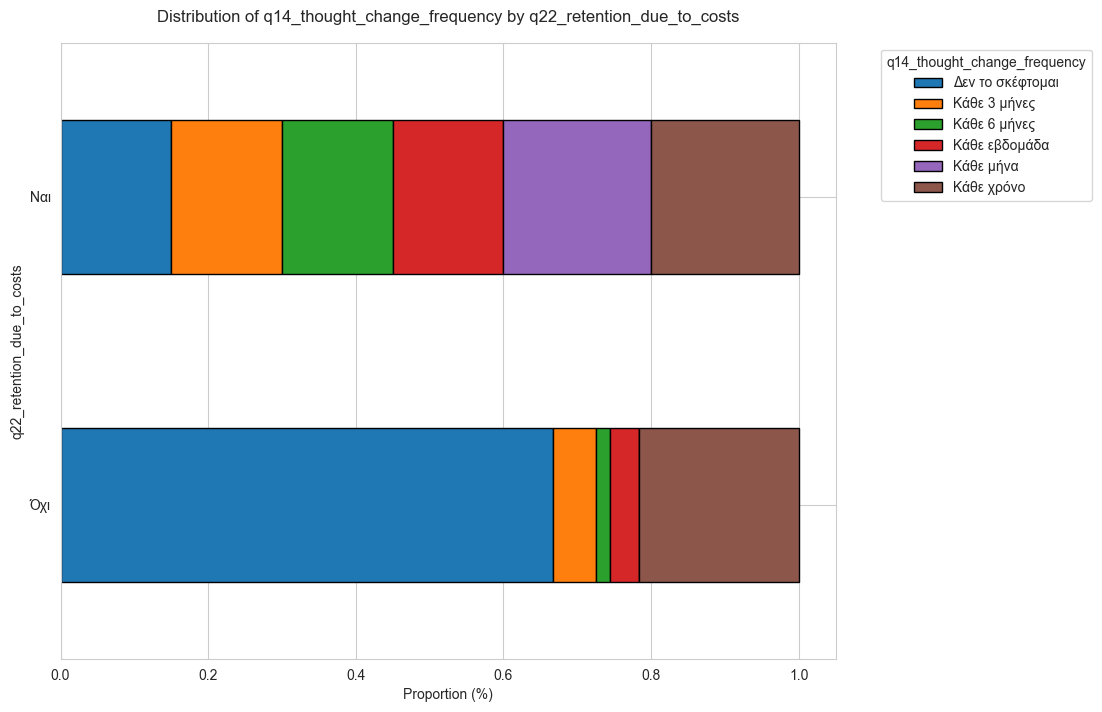

q14_thought_change_frequency  Δεν το σκέφτομαι  Κάθε 3 μήνες  Κάθε 6 μήνες  \
q22_retention_due_to_costs                                                   
Όχι                                         34             3             1   
Ναι                                          9             9             9   
Total Counts                                43            12            10   

q14_thought_change_frequency  Κάθε εβδομάδα  Κάθε μήνα  Κάθε χρόνο  \
q22_retention_due_to_costs                                           
Όχι                                       2          0          11   
Ναι                                       9         12          12   
Total Counts                             11         12          23   

q14_thought_change_frequency  Total Counts  
q22_retention_due_to_costs                  
Όχι                                     51  
Ναι                                     60  
Total Counts                           111  




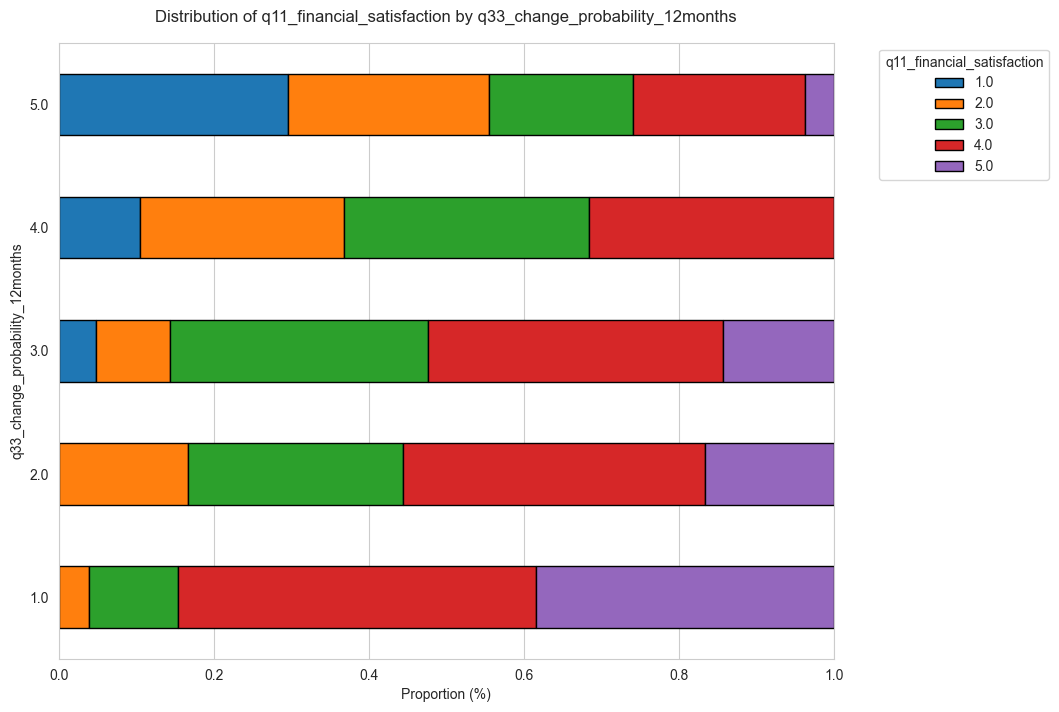

q11_financial_satisfaction       1.0  2.0  3.0  4.0  5.0  Total Counts
q33_change_probability_12months                                       
1.0                                0    1    3   12   10            26
2.0                                0    3    5    7    3            18
3.0                                1    2    7    8    3            21
4.0                                2    5    6    6    0            19
5.0                                8    7    5    6    1            27
Total Counts                      11   18   26   39   17           111




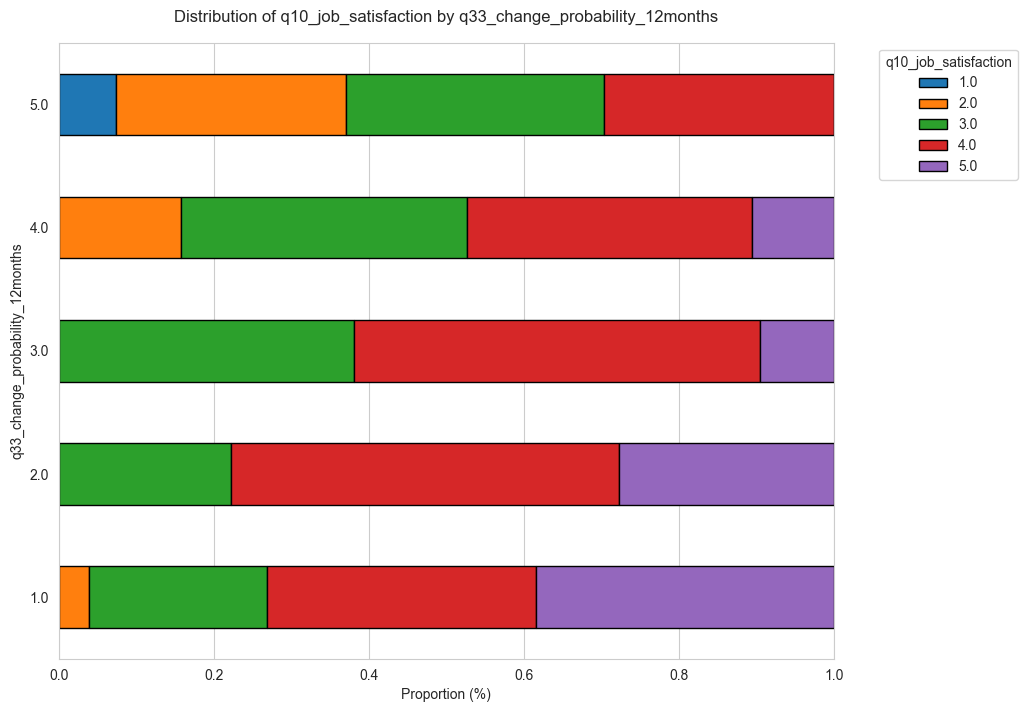

q10_job_satisfaction             1.0  2.0  3.0  4.0  5.0  Total Counts
q33_change_probability_12months                                       
1.0                                0    1    6    9   10            26
2.0                                0    0    4    9    5            18
3.0                                0    0    8   11    2            21
4.0                                0    3    7    7    2            19
5.0                                2    8    9    8    0            27
Total Counts                       2   12   34   44   19           111




In [17]:
#q3 links to retention due to costand thought change frequency, financial satisfaction and job satisfaction
grouped_bar_chart_creation(dataset,'q22_retention_due_to_costs','q14_thought_change_frequency')
grouped_bar_chart_creation(dataset, 'q33_change_probability_12months','q11_financial_satisfaction')
grouped_bar_chart_creation(dataset, 'q33_change_probability_12months','q10_job_satisfaction')
# grouped_bar_chart_creation(dataset,'q18_attrition_intent','q10_job_satisfaction')

In [19]:
from sklearn.preprocessing import StandardScaler

#initializing a standard scaler object to scale the Likert columns
scaler = StandardScaler()
scaled_likerts = scaler.fit_transform(dataset[likert_cols])
scaled_likert_column_names = []

j=0
for l_col in likert_cols:
    #creating a new name for the scaled column
    updated_likert_col_name=f'{l_col}_scaled'
    scaled_likert_column_names.append(updated_likert_col_name)
    #inserting the new column in order
    dataset[updated_likert_col_name] = scaled_likerts[:,j]
    j=j+1

#creating new dataframe containing the updated Likert columns
scaled_ds = dataset.drop(columns=likert_cols)

In [25]:
# preparation for K-Prototypes, using elbow-method
from kmodes.kprototypes import KPrototypes

#dropping some irrelevant fields from the final dataset version before K-Prototypes
final_ds = dataset.drop(columns=['Timestamp','q28_emotional_exhaustion_frequency', 'q29_stress_level'])

# K-Prototypes requires the categorical column indices, which they'll be found with the below loop (as well as the categorical column names)
categorical_column_indices = []
cat_col_names = []
position=0
for column in final_ds.columns:
    if column not in likert_cols:
        categorical_column_indices.append(position)
        cat_col_names.append(column)
    position=position+1

def elbow_method(data, c_col_indices):
    inertia = []
    K_range = range(1, 11)  # test k from 1 to 11

    for k in K_range:
        kprototypes = KPrototypes(n_clusters=k, init='Huang', random_state=42, n_init=10)
        kprototypes.fit(data.values, categorical=c_col_indices)
        inertia.append(kprototypes.cost_)
    #showing all the results
    plt.figure(figsize=(8, 5))
    plt.plot(K_range, inertia, marker='o')
    plt.title("Elbow Method for Optimal K")
    plt.xlabel("Number of clusters (K)")
    plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
    plt.grid(True)
    plt.show()

In [50]:
#calculating silhouette score
from sklearn.metrics import silhouette_score
import gower

def sil_score(dataset,cat_col_names, cat_col_indices):
    values = dataset.values

    #gower distance matrix calculation
    gower_matrix = gower.gower_matrix(dataset, cat_features=[col in cat_col_names for col in dataset.columns])

    K_range = range(2,11) # just like with elbow method, testing k from 1 to 11
    silhouettes = []

    for k in K_range:
        kproto = KPrototypes(n_clusters=k, init='Huang', verbose=0, random_state=42)
        cluster_labels = kproto.fit_predict(values, categorical=cat_col_indices)

        score = silhouette_score(gower_matrix, cluster_labels, metric='precomputed')
        silhouettes.append(score)
        # print(self) # debugging
        # print(f"For K = {k}, Silhouette Score = {score:.4f}") # debugging

    plt.figure(figsize=(8, 5)) #showing all the results
    plt.plot(K_range, silhouettes, marker='o', color='purple', linestyle='--')
    plt.xlabel('Clusters (K)')
    plt.ylabel('Silhouette Score (Gower)')
    plt.title(' Silhouette score for K-Prototypes')
    plt.grid(True)
    plt.show()

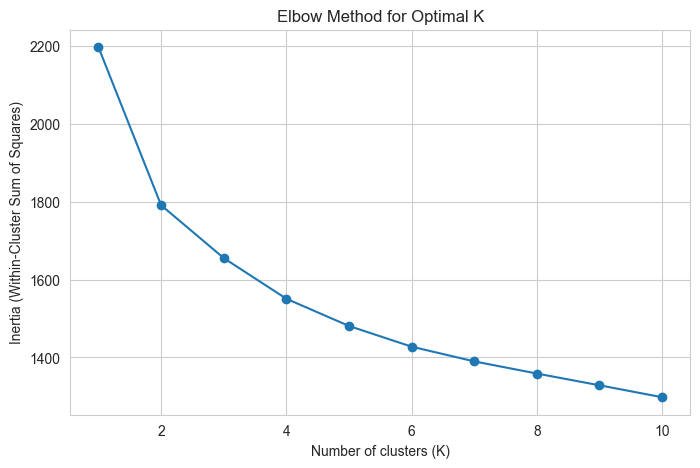

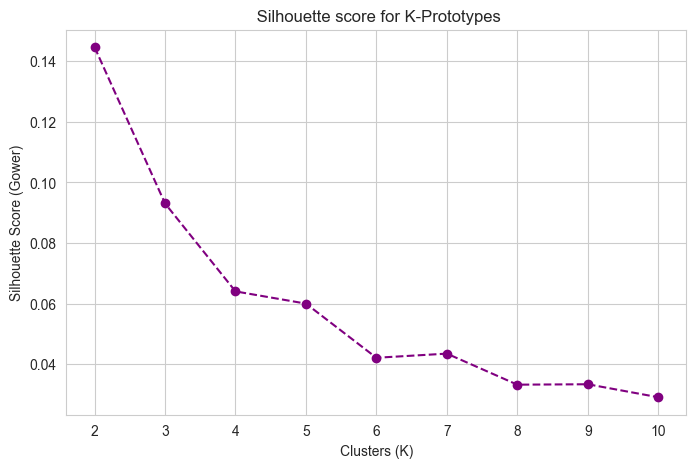

In [51]:
elbow_method(final_ds, categorical_column_indices)
sil_score(final_ds,cat_col_names, categorical_column_indices)

In [47]:
#final K-Prototypes test, with 5 clusters based on prior Elbow Method results

kproto = KPrototypes(n_clusters = 2, init='Huang', random_state=42, n_init=10)
cluster_labels = kproto.fit_predict(final_ds.values, categorical=categorical_column_indices)

# creating new column containing the two newly discovered Clusters
final_ds['cluster_labels'] = cluster_labels
final_ds['cluster_labels'] = final_ds['cluster_labels']+1

In [49]:
#emptying the categorical_columns list to have the recent changes
categorical_columns = []
for col in final_ds.columns:
    if col not in scaled_likert_column_names:
        categorical_columns.append(col)

#using mode as a metric (the most frequent value)
for i in range(2):
    #skipping i = 0, since clusters are 1-5
    print('\n'+'='*50)
    print(f"Most frequent characteristics for Cluster {i+1}")
    print('='*50,'\n')
    for cat_col in categorical_columns:
        mode_val = final_ds[final_ds['cluster_labels'] == i+1][cat_col].mode()[0]
        print(f"{cat_col}: {mode_val}")


Most frequent characteristics for Cluster 1

q1_gender: Άνδρας
q2_age_group: 26-41
q3_education_level: Πτυχίο ΑΕΙ-ΤΕΙ
q4_white_collar_status: Δουλεύω σε έναν εργοδότη
q5_industry: Τεχνολογία & Πληροφορική
q6_job_level: Mid-level
q7_company_size: Μικρομεσαία (11-250 άτομα)
q8_total_experience: 6-10
q9_tenure_current_employer: 3-5 έτη
q10_job_satisfaction: 3.0
q11_financial_satisfaction: 2.0
q12_ideal_stay_duration: 3-5 έτη
q13_profile_update_frequency: Κάθε 6 μήνες
q14_thought_change_frequency: Κάθε μήνα
q15_job_hopping_awareness: Ναι
q16_job_hopping_benefit: 4.0
q17_job_hopping_history: Όχι
q18_attrition_intent: Ναι
q19_employers_changed_5years: 0
q20_fair_reward_perception: Μέτρια
q21_minimum_effort_frequency: Συχνά
q22_retention_due_to_costs: Ναι
q23_quiet_quitting_history: Όχι
q24_quiet_quitting_benefit: 4.0
q25_current_work_model: Δια ζώσης (On-Site)
q26_preferred_work_model: Υβριδικό (Hybrid)
q27_overtime_frequency: Πολύ λίγο (1-15 μέρες)
q30_stress_work_model_connection: Μέτρια 